# BMDS2003 DATA SCIENCE — GROUP ASSIGNMENT
## Malaysia Housing Median Price Estimator

---
# PART 1 — DATA UNDERSTANDING
## 1.1 Imports, reproducibility and data loading


### Load the raw dataset



In [1]:
from pathlib import Path
import shutil

RAW_FILENAME = "malaysia_house_price_data_2025.csv"
raw_path = Path(RAW_FILENAME)
uploaded_name = RAW_FILENAME

if raw_path.exists():
    print(f"Using local file: {raw_path}")
else:
    try:
        from google.colab import files as colab_files
        uploaded = colab_files.upload()
        uploaded_name = next(iter(uploaded))
        if uploaded_name != RAW_FILENAME:
            shutil.copy2(uploaded_name, raw_path)
        print(f"Uploaded file: {uploaded_name}")
    except ImportError as exc:
        raise FileNotFoundError(
            f"Place {RAW_FILENAME!r} beside the notebook before running it."
        ) from exc


Saving malaysia_house_price_data_2025.csv to malaysia_house_price_data_2025.csv
Uploaded file: malaysia_house_price_data_2025.csv


In [2]:
from __future__ import annotations

import os
import re
import json
import time
import math
import glob
import shutil
import zipfile
import warnings
import unicodedata
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

RANDOM_STATE = 42
N_JOBS = 2
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 120,
    "figure.max_open_warning": 0,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
})

FIGURES_DIR = Path("figures")
MODELS_DIR = Path("models")
ASSETS_DIR = Path("assets")
STREAMLIT_DIR = Path(".streamlit")
for folder in [FIGURES_DIR, MODELS_DIR, ASSETS_DIR, STREAMLIT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

for old_figure in FIGURES_DIR.glob("fig*.png"):
    old_figure.unlink()
Path("area_ablation_results.csv").unlink(missing_ok=True)

def save_fig(filename: str) -> None:
    plt.savefig(FIGURES_DIR / filename, bbox_inches="tight", facecolor="white")

RAW_FILENAME = "malaysia_house_price_data_2025.csv"
raw_path = Path(RAW_FILENAME)

if uploaded_name != RAW_FILENAME:
    shutil.copy2(uploaded_name, raw_path)

raw = pd.read_csv(raw_path)
print(f"Loaded {RAW_FILENAME}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head(10))


Loaded malaysia_house_price_data_2025.csv: 2,000 rows x 8 columns


,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,363
5,TAMAN IMPIAN EMAS,Tebrau,Johor,Freehold,"Terrace House, Semi D",738000.0,328.0,349
6,TAMAN KOTA MASAI,Pasir Gudang,Johor,Freehold,Terrace House,345000.0,323.0,319
7,TAMAN LAGENDA TELUK INTAN,Teluk Intan,Perak,Leasehold,"Terrace House, Cluster House",236594.0,126.0,309
8,BANDAR SCIENTEX JASIN,Jasin,Melaka,Freehold,Terrace House,180000.0,188.0,301
9,BANDAR BUKIT RAJA,Kapar,Selangor,Freehold,Terrace House,793888.0,496.0,292


## 1.2 Dataset structure and data dictionary

**Dataset source:** Malaysian residential property transaction data provided for
the BMDS2003 assignment (`malaysia_house_price_data_2025.csv`).

**Dataset period:** 2025

**Dataset type:** Cross-sectional Malaysian housing market data

**Original size:** 2,000 records × 8 variables

**Target variable:** `Median_Price`

In [3]:
descriptions = {
    "Township": "Township or housing-project name; excluded because it is nearly identifier-like",
    "Area": "Locality/sub-district; cleaned and used through a state-qualified Area_Key",
    "State": "Malaysian state or federal territory",
    "Tenure": "Land tenure",
    "Type": "Property-type label; may contain several types",
    "Median_Price": "Median transaction price in RM (TARGET)",
    "Median_PSF": "Median price per square foot in RM",
    "Transactions": "Recorded transaction count",
}

data_dictionary = pd.DataFrame({
    "Column": raw.columns,
    "Data type": [str(raw[c].dtype) for c in raw.columns],
    "Unique values": [raw[c].nunique(dropna=False) for c in raw.columns],
    "Example": [str(raw[c].dropna().iloc[0]) if raw[c].notna().any() else "—" for c in raw.columns],
    "Role": ["Target" if c == "Median_Price" else
             "Excluded identifier-like" if c == "Township" else "Candidate input" for c in raw.columns],
    "Description": [descriptions[c] for c in raw.columns],
})
display(data_dictionary)

print("Categorical unique counts:")
for col in ["Township", "Area", "State", "Tenure", "Type"]:
    print(f"  {col:10s}: {raw[col].nunique(dropna=False):,}")

,Column,Data type,Unique values,Example,Role,Description
0,Township,object,1946,SCIENTEX SUNGAI DUA,Excluded identifier-like,Township or housing-project name; excluded bec...
1,Area,object,303,Tasek Gelugor,Candidate input,Locality/sub-district; cleaned and used throug...
2,State,object,16,Penang,Candidate input,Malaysian state or federal territory
3,Tenure,object,4,Freehold,Candidate input,Land tenure
4,Type,object,46,Terrace House,Candidate input,Property-type label; may contain several types
5,Median_Price,float64,831,331800.0,Target,Median transaction price in RM (TARGET)
6,Median_PSF,float64,584,304.0,Candidate input,Median price per square foot in RM
7,Transactions,int64,142,593,Candidate input,Recorded transaction count


Categorical unique counts:
  Township  : 1,946
  Area      : 303
  State     : 16
  Tenure    : 4
  Type      : 46


## 1.3 Complete missing-value check

The check treats nulls, blank strings and common placeholders as missing.

In [4]:
PLACEHOLDERS = {"", "N/A", "NA", "NULL", "NONE", "NAN", "-"}

def extended_missing_mask(series: pd.Series) -> pd.Series:
    mask = series.isna()
    if not pd.api.types.is_numeric_dtype(series):
        normalised = series.astype("string").str.strip().str.upper()
        mask = mask | normalised.isin(PLACEHOLDERS)
    return mask

missing_summary = pd.DataFrame({
    "Column": raw.columns,
    "Missing count": [int(extended_missing_mask(raw[c]).sum()) for c in raw.columns],
    "Missing percentage": [extended_missing_mask(raw[c]).mean() * 100 for c in raw.columns],
    "Data type": [str(raw[c].dtype) for c in raw.columns],
})
missing_summary["Treatment decision"] = np.where(
    missing_summary["Missing count"].eq(0),
    "No treatment required",
    "Handle in cleaning/pipeline; never impute the target"
)
display(missing_summary.round({"Missing percentage": 2}))

if missing_summary["Missing count"].sum() == 0:
    print("No missing or placeholder values were found. No missing-value treatment was required.")

,Column,Missing count,Missing percentage,Data type,Treatment decision
0,Township,0,0.0,object,No treatment required
1,Area,0,0.0,object,No treatment required
2,State,0,0.0,object,No treatment required
3,Tenure,0,0.0,object,No treatment required
4,Type,0,0.0,object,No treatment required
5,Median_Price,0,0.0,float64,No treatment required
6,Median_PSF,0,0.0,float64,No treatment required
7,Transactions,0,0.0,int64,No treatment required


No missing or placeholder values were found. No missing-value treatment was required.


In [5]:
print("Table 1 - Missing-value summary")
if missing_summary["Missing count"].sum() == 0:
    print("No missing or placeholder values were found across any column.")
    print("No missing-value treatment was required.")
else:
    affected = missing_summary[missing_summary["Missing count"] > 0]
    print(f"{len(affected)} column(s) contain missing or placeholder values - see the table above.")

Table 1 - Missing-value summary
No missing or placeholder values were found across any column.
No missing-value treatment was required.


## 1.4 Duplicate-record check


In [6]:
BUSINESS_KEY = ["Township", "Area", "State", "Tenure", "Type"]
exact_duplicate_count = int(raw.duplicated().sum())
business_duplicate_mask = raw.duplicated(BUSINESS_KEY, keep=False)
business_duplicate_rows = int(business_duplicate_mask.sum())
business_duplicate_groups = int(raw.groupby(BUSINESS_KEY, dropna=False).size().gt(1).sum())

duplicate_summary = pd.DataFrame({
    "Check": ["Exact duplicate rows", "Rows in repeated business keys", "Repeated business-key groups"],
    "Count": [exact_duplicate_count, business_duplicate_rows, business_duplicate_groups],
    "Decision": [
        "Remove only if count > 0",
        "Review before removal; repeated Areas alone are valid",
        "Review before removal",
    ],
})
display(duplicate_summary)

if business_duplicate_rows:
    display(raw.loc[business_duplicate_mask].sort_values(BUSINESS_KEY).head(20))
else:
    print("No genuine duplicate records were found. No records were removed.")

,Check,Count,Decision
0,Exact duplicate rows,0,Remove only if count > 0
1,Rows in repeated business keys,0,Review before removal; repeated Areas alone ar...
2,Repeated business-key groups,0,Review before removal


No genuine duplicate records were found. No records were removed.


In [7]:
print("Table 2 - Duplicate-record assessment")
if duplicate_summary["Count"].sum() == 0:
    print("No genuine duplicate records were found.")
    print("No observations were removed.")
else:
    flagged = duplicate_summary[duplicate_summary["Count"] > 0]
    print(f"{len(flagged)} check(s) flagged duplicate-like records - see the table above.")
print("Repeated Area values are NOT duplicates: several distinct townships legitimately share an Area.")

Table 2 - Duplicate-record assessment
No genuine duplicate records were found.
No observations were removed.
Repeated Area values are NOT duplicates: several distinct townships legitimately share an Area.


## 1.5 Data types, numerical validity and descriptive statistics

In [8]:
NUMERIC_RAW = ["Median_Price", "Median_PSF", "Transactions"]
validity_rows = []
for col in NUMERIC_RAW:
    numeric = pd.to_numeric(raw[col], errors="coerce")
    invalid_text = int(numeric.isna().sum() - raw[col].isna().sum())
    if col in ["Median_Price", "Median_PSF"]:
        invalid_domain = int((numeric <= 0).sum())
        rule = f"{col} > 0"
    else:
        invalid_domain = int((numeric < 0).sum())
        rule = "Transactions >= 0"
    validity_rows.append({
        "Column": col,
        "Stored dtype": str(raw[col].dtype),
        "Invalid text values": invalid_text,
        "Invalid domain values": invalid_domain,
        "Validity rule": rule,
    })
validity_summary = pd.DataFrame(validity_rows)
display(validity_summary)
display(raw[NUMERIC_RAW].describe().T.round(2))
print("Skewness:")
display(raw[NUMERIC_RAW].skew().rename("Skewness").to_frame().round(3))
print("Validity rules applied: Median_Price > 0, Median_PSF > 0, Transactions >= 0.")
print("A RM0 property price or RM0 price per square foot would not represent a\n"
      "meaningful housing transaction, so both must be strictly positive.")

,Column,Stored dtype,Invalid text values,Invalid domain values,Validity rule
0,Median_Price,float64,0,0,Median_Price > 0
1,Median_PSF,float64,0,0,Median_PSF > 0
2,Transactions,int64,0,0,Transactions >= 0


,count,mean,std,min,25%,50%,75%,max
Median_Price,2000.0,490685.41,468632.21,27049.0,269950.0,390000.0,573500.0,11420500.0
Median_PSF,2000.0,328.86,193.28,38.0,201.0,293.0,412.0,3017.0
Transactions,2000.0,28.09,37.70,10.0,12.0,16.0,28.0,593.0


Skewness:


,Skewness
Median_Price,8.826
Median_PSF,3.453
Transactions,6.553


Validity rules applied: Median_Price > 0, Median_PSF > 0, Transactions >= 0.
A RM0 property price or RM0 price per square foot would not represent a
meaningful housing transaction, so both must be strictly positive.


**Validity rules.** `Median_Price > 0`, `Median_PSF > 0` and `Transactions >= 0`.
A RM0 property price or a RM0 price per square foot would not represent a
meaningful housing transaction, so both price variables must be strictly
positive. A transaction count of zero is possible in principle, so only negative
counts are invalid.

**Interpreting the skewness values.** Positive skewness indicates that most
observations are concentrated at lower values while a smaller number of unusually
large observations create a long right tail. The high skewness of `Median_Price`,
`Median_PSF` and `Transactions` therefore motivates further investigation of
extreme values in the data-preparation stage.

## 1.6 Raw distributions and relationships

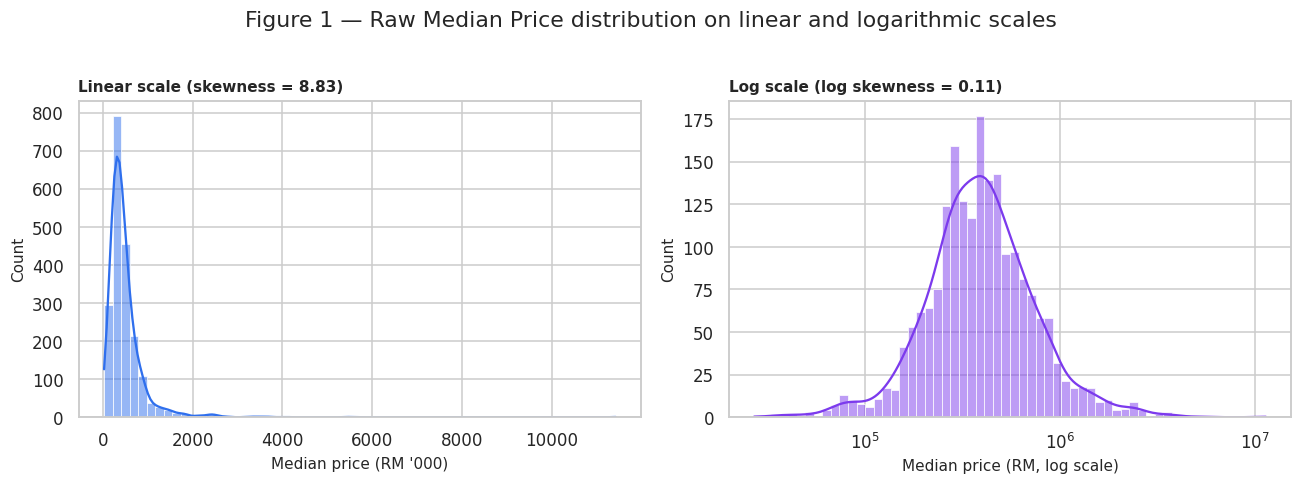

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
sns.histplot(raw["Median_Price"] / 1000, bins=60, kde=True, ax=axes[0], color="#2F6FED")
axes[0].set_title(f"Linear scale (skewness = {raw['Median_Price'].skew():.2f})", loc="left", fontsize=10)
axes[0].set_xlabel("Median price (RM '000)")
sns.histplot(raw["Median_Price"], bins=60, kde=True, ax=axes[1], color="#7C3AED", log_scale=True)
axes[1].set_title(f"Log scale (log skewness = {np.log(raw['Median_Price']).skew():.2f})", loc="left", fontsize=10)
axes[1].set_xlabel("Median price (RM, log scale)")
plt.suptitle("Figure 1 — Raw Median Price distribution on linear and logarithmic scales", y=1.02)
plt.tight_layout(); save_fig("fig01_raw_target_distribution.png"); plt.show()

**Insight (Figure 1).** `Median_Price` is strongly right-skewed on the original
scale (skewness ≈ 8.83), indicating that a small number of very expensive records
create a long upper tail. Viewing the same observations on a logarithmic scale
produces a more symmetric distribution (log skewness ≈ 0.11). Since the panels use
different x-axis scales, they are used to compare distribution **shape** rather
than exact values.

This shape is the reason outliers are assessed on the log scale in Part 2.4.

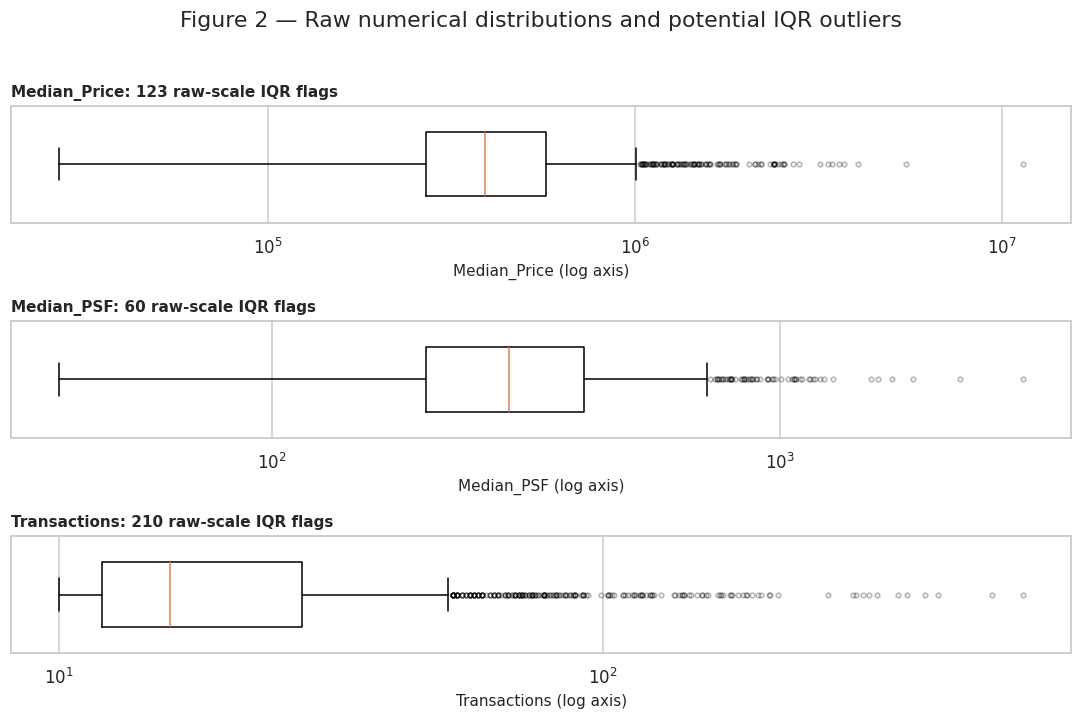

,Column,Lower fence,Upper fence,Flagged
0,Median_Price,-185375.0,1028825.0,123
1,Median_PSF,-115.5,728.5,60
2,Transactions,-12.0,52.0,210


In [10]:
def iqr_flags(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return (series < low) | (series > high), low, high

fig, axes = plt.subplots(3, 1, figsize=(10, 6.4))
raw_fences = []
for ax, col in zip(axes, NUMERIC_RAW):
    flags, low, high = iqr_flags(raw[col])
    ax.boxplot(raw[col], vert=False, widths=0.55,
               flierprops=dict(marker="o", markersize=3, alpha=0.3))
    ax.set_xscale("log")
    ax.set_yticks([])
    ax.set_xlabel(f"{col} (log axis)")
    ax.set_title(f"{col}: {flags.sum()} raw-scale IQR flags", fontsize=10, loc="left")
    raw_fences.append({"Column": col, "Lower fence": low, "Upper fence": high, "Flagged": int(flags.sum())})
plt.suptitle("Figure 2 — Raw numerical distributions and potential IQR outliers", y=1.02)
plt.tight_layout(); save_fig("fig02_raw_numeric_boxplots.png"); plt.show()
display(pd.DataFrame(raw_fences).round(2))

**Insight (Figure 2).** All three numerical variables are strongly right-skewed.
A logarithmic x-axis is used only to make the distributions easier to view; the
underlying values remain unchanged.


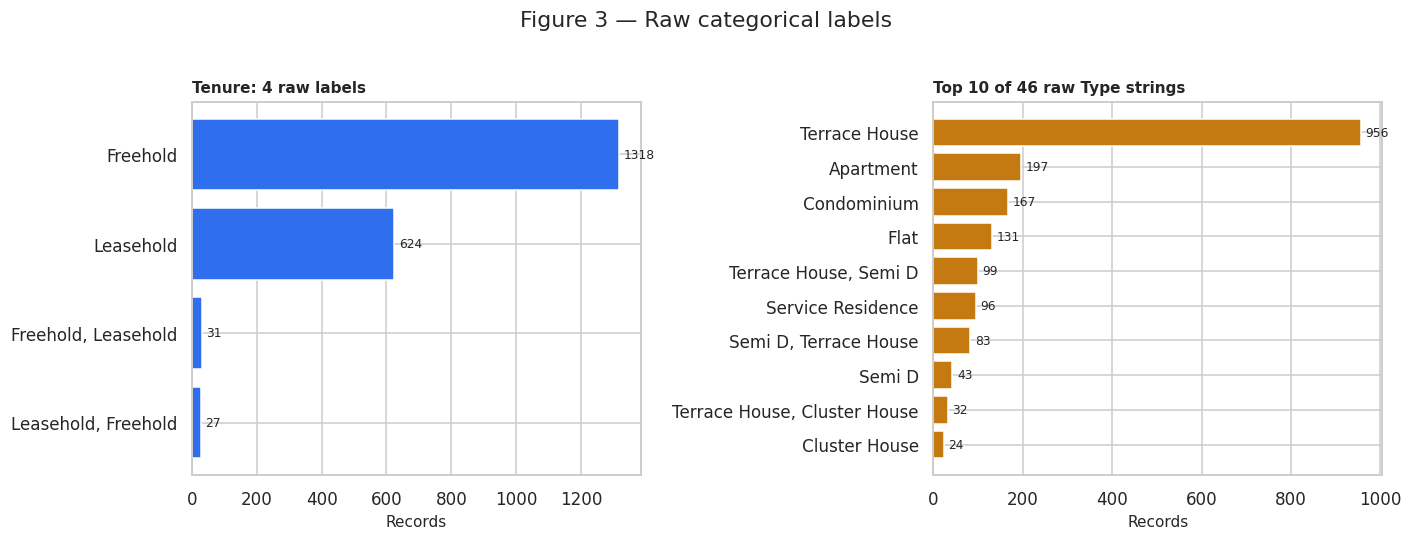

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
tenure_raw = raw["Tenure"].value_counts().sort_values()
bars = axes[0].barh(tenure_raw.index, tenure_raw.values, color="#2F6FED")
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_title(f"Tenure: {raw['Tenure'].nunique()} raw labels", loc="left", fontsize=10)
axes[0].set_xlabel("Records")

top_types_raw = raw["Type"].value_counts().head(10).sort_values()
bars = axes[1].barh(top_types_raw.index, top_types_raw.values, color="#C47A10")
axes[1].bar_label(bars, padding=3, fontsize=8)
axes[1].set_title(f"Top 10 of {raw['Type'].nunique()} raw Type strings", loc="left", fontsize=10)
axes[1].set_xlabel("Records")
plt.suptitle("Figure 3 — Raw categorical labels", y=1.02)
plt.tight_layout(); save_fig("fig03_raw_categories.png"); plt.show()

**Insight (Figure 3).** `Tenure` contains the same pair of values written in two
different orders, which must be standardised to a single `Mixed` category.

`Type` contains 46 raw labels, including multi-type combinations whose ordering is
inconsistent. For example, `Terrace House, Semi D` and `Semi D, Terrace House`
describe the same combination in different orders. This would create unnecessary
separate categories during modelling, so `Type` labels are standardised in Part 2.

---
# PART 2 — DATA PREPARATION
## 2.1 State, Area, Tenure and Type Standardisation

Text-based categorical variables were standardised to ensure consistent
formatting. `State` and `Area` values were normalised by standardising letter
case, removing unnecessary whitespace, and harmonising punctuation. Fuzzy matching
was **not** used, to avoid incorrectly merging different locations. `Tenure` and
`Type` labels were also standardised to reduce semantically duplicated categories.



In [12]:
AREA_HELPER_CODE = 'from __future__ import annotations\nimport re\nimport unicodedata\nimport pandas as pd\n\nPLACEHOLDERS = {"", "N/A", "NA", "NULL", "NONE", "NAN", "-"}\n\ndef _base_text(value) -> str:\n    if pd.isna(value):\n        return ""\n    text = unicodedata.normalize("NFKC", str(value)).strip()\n    text = re.sub(r"\\s+", " ", text)\n    return text\n\ndef clean_state_name(value) -> str:\n    text = _base_text(value)\n    if text.upper() in PLACEHOLDERS:\n        return "UNKNOWN STATE"\n    text = text.replace("–", "-").replace("—", "-")\n    text = re.sub(r"\\s*-\\s*", "-", text)\n    return text.upper()\n\ndef clean_area_name(value) -> str:\n    text = _base_text(value)\n    if text.upper() in PLACEHOLDERS:\n        return "UNKNOWN AREA"\n    text = text.replace("–", "-").replace("—", "-")\n    text = re.sub(r"\\s*-\\s*", "-", text)\n    text = re.sub(r"\\s*/\\s*", "/", text)\n    text = re.sub(r"\\s*,\\s*", ", ", text)\n    text = re.sub(r"\\s*&\\s*", " & ", text)\n    text = re.sub(r"\\s+", " ", text).strip()\n    return text.upper()\n\ndef create_area_key(state, area) -> str:\n    return f"{clean_state_name(state)} | {clean_area_name(area)}"\n\ndef display_name(value: str) -> str:\n    if not value:\n        return value\n    protected = {"KL", "MRT", "LRT", "USJ", "TTDI", "PJ", "JB"}\n    parts = []\n    for token in str(value).split(" "):\n        parts.append(token if token in protected else token.title())\n    return " ".join(parts)\n'
Path('area_preprocessing.py').write_text(AREA_HELPER_CODE, encoding='utf-8')
from area_preprocessing import clean_state_name, clean_area_name, create_area_key, display_name
examples = pd.DataFrame({'Input':['Skudai','SKUDAI',' skudai ','Taman  Molek','A – B',None]})
examples['Area_Clean']=examples['Input'].map(clean_area_name)
display(examples)
assert len({clean_area_name(v) for v in ['Skudai','SKUDAI',' skudai ','Skudai  ']}) == 1

,Input,Area_Clean
0,Skudai,SKUDAI
1,SKUDAI,SKUDAI
2,skudai,SKUDAI
3,Taman Molek,TAMAN MOLEK
4,A – B,A-B
5,None,UNKNOWN AREA


In [13]:
df_work = raw.copy()

# Capture TRUE raw values from the untouched `raw` frame BEFORE any cleaning step.
for col in ["Township", "State", "Area", "Tenure", "Type"]:
    df_work[f"{col}_Raw"] = raw[col]

for col in ["Township", "State", "Area", "Tenure", "Type"]:
    df_work[col] = df_work[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

df_work["State_Clean"] = df_work["State"].map(clean_state_name)
df_work["Area_Clean"] = df_work["Area"].map(clean_area_name)
df_work["Area_Key"] = [create_area_key(s, a) for s, a in zip(df_work["State"], df_work["Area"])]
# User-facing State remains readable; State_Clean is preserved for auditing and Area_Key.
df_work["State"] = df_work["State_Clean"].map(display_name)

TENURE_BEFORE = df_work["Tenure"].value_counts(dropna=False)
def clean_tenure(value) -> str:
    text = str(value).strip()
    parts = sorted({p.strip().title() for p in text.split(",") if p.strip()})
    if not parts:
        return "Unknown"
    return "Mixed" if len(parts) > 1 else parts[0]
df_work["Tenure"] = df_work["Tenure"].map(clean_tenure)
TENURE_AFTER = df_work["Tenure"].value_counts(dropna=False)

TYPE_PRIORITY = [
    "Bungalow", "Semi D", "Cluster House", "Terrace House", "Town House",
    "Condominium", "Service Residence", "Apartment", "Flat"
]
TYPE_RANK = {name: i for i, name in enumerate(TYPE_PRIORITY)}
def canonical_type_tokens(value) -> list[str]:
    return sorted({p.strip() for p in str(value).split(",") if p.strip()}, key=lambda x: TYPE_RANK.get(x, 999))
def choose_primary_type(value) -> str:
    tokens = canonical_type_tokens(value)
    return tokens[0] if tokens else "Unknown"

df_work["Type_Clean"] = df_work["Type"].map(lambda v: ", ".join(canonical_type_tokens(v)))
df_work["Primary_Type"] = df_work["Type"].map(choose_primary_type)
HIGH_RISE = {"Condominium", "Service Residence", "Apartment", "Flat"}
df_work["Category"] = np.where(df_work["Primary_Type"].isin(HIGH_RISE), "High-Rise", "Landed")

print("Tenure before:")
display(TENURE_BEFORE.rename("Rows").to_frame())
print("Tenure after:")
display(TENURE_AFTER.rename("Rows").to_frame())
print(f"Raw Type strings: {df_work['Type'].nunique()} | Canonical Type strings: {df_work['Type_Clean'].nunique()} | Primary_Type: {df_work['Primary_Type'].nunique()}")
display(df_work[["Type", "Type_Clean", "Primary_Type"]].drop_duplicates().sort_values(["Primary_Type", "Type"]).head(30))

Tenure before:


,Rows
Tenure,
Freehold,1318
Leasehold,624
"Freehold, Leasehold",31
"Leasehold, Freehold",27


Tenure after:


,Rows
Tenure,
Freehold,1318
Leasehold,624
Mixed,58


Raw Type strings: 46 | Canonical Type strings: 27 | Primary_Type: 9


,Type,Type_Clean,Primary_Type
88,Apartment,Apartment,Apartment
888,"Apartment, Flat","Apartment, Flat",Apartment
1325,"Flat, Apartment","Apartment, Flat",Apartment
207,Bungalow,Bungalow,Bungalow
206,"Bungalow, Semi D","Bungalow, Semi D",Bungalow
1524,"Bungalow, Semi D, Terrace House","Bungalow, Semi D, Terrace House",Bungalow
25,"Bungalow, Terrace House","Bungalow, Terrace House",Bungalow
309,"Bungalow, Terrace House, Semi D","Bungalow, Semi D, Terrace House",Bungalow
493,"Bungalow, Town House","Bungalow, Town House",Bungalow
1224,"Cluster House, Bungalow","Bungalow, Cluster House",Bungalow


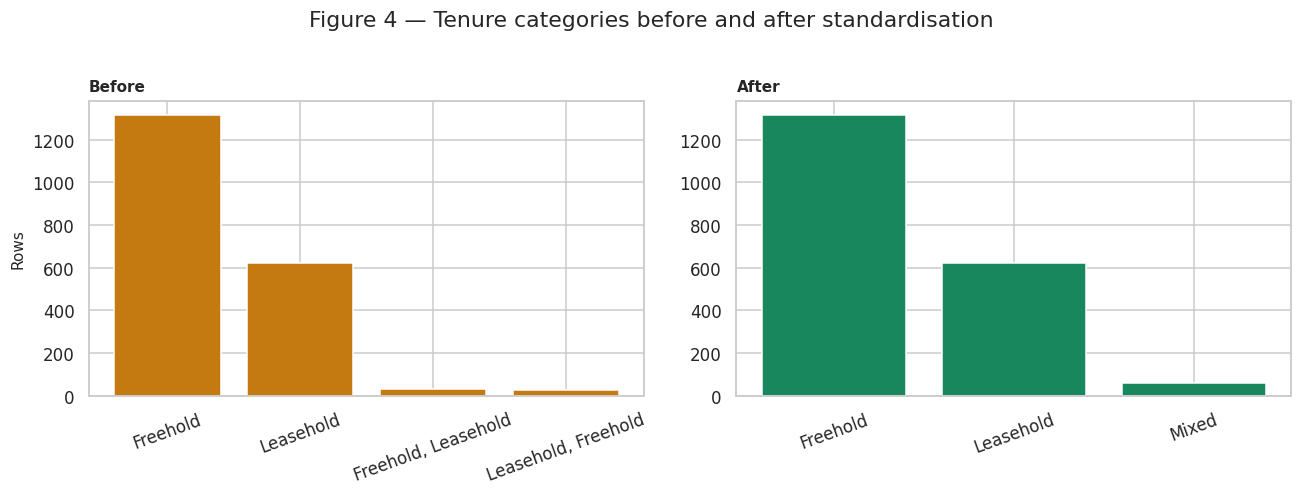

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].bar(TENURE_BEFORE.index.astype(str), TENURE_BEFORE.values, color="#C47A10")
axes[0].set_title("Before", loc="left", fontsize=10)
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Rows")
axes[1].bar(TENURE_AFTER.index.astype(str), TENURE_AFTER.values, color="#18875D")
axes[1].set_title("After", loc="left", fontsize=10)
axes[1].tick_params(axis="x", rotation=20)
plt.suptitle("Figure 4 — Tenure categories before and after standardisation", y=1.02)
plt.tight_layout(); save_fig("fig04_tenure_before_after.png"); plt.show()

**Insight (Figure 4).** The two mixed-tenure labels carry identical information in a
different word order and are standardised into a single `Mixed` category. No row is
deleted and no genuinely different tenure is merged — standardisation relabels,
it never discards data.

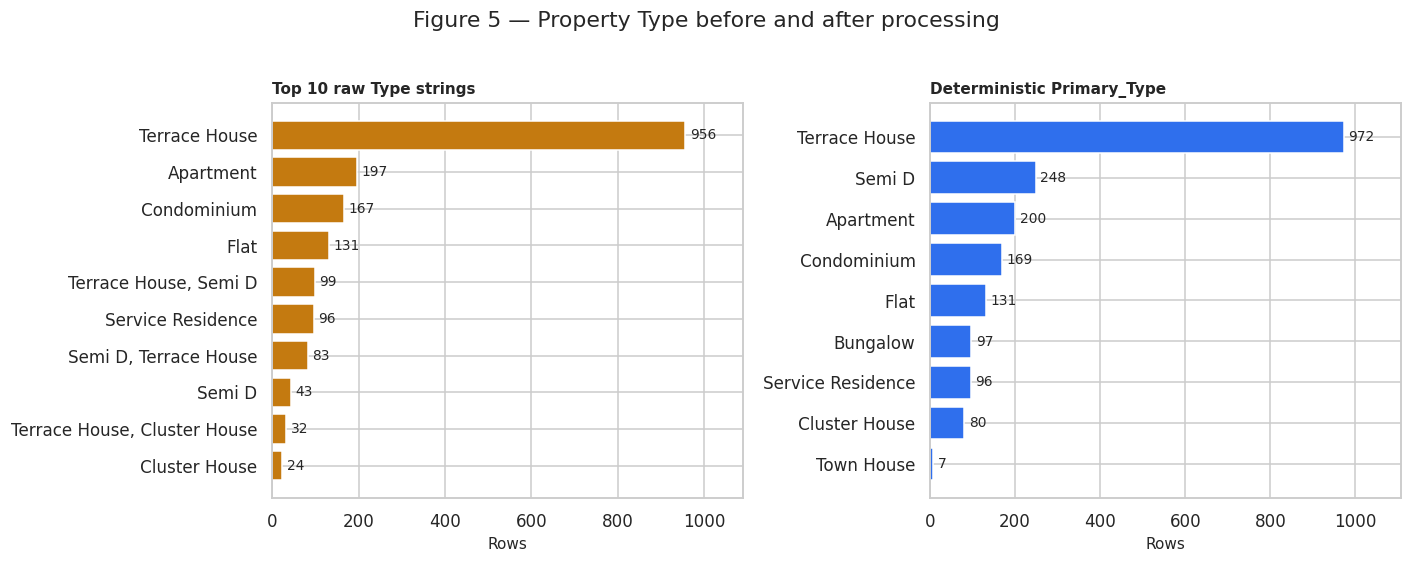

In [15]:
raw_type_counts = df_work["Type"].value_counts().head(10).sort_values()
primary_counts = df_work["Primary_Type"].value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
b0 = axes[0].barh(raw_type_counts.index, raw_type_counts.values, color="#C47A10")
axes[0].bar_label(b0, padding=3, fontsize=9)
axes[0].set_xlim(0, raw_type_counts.max() * 1.14)
axes[0].set_title("Top 10 raw Type strings", loc="left", fontsize=10)
axes[0].set_xlabel("Rows")
b1 = axes[1].barh(primary_counts.index, primary_counts.values, color="#2F6FED")
axes[1].bar_label(b1, padding=3, fontsize=9)
axes[1].set_xlim(0, primary_counts.max() * 1.14)
axes[1].set_title("Deterministic Primary_Type", loc="left", fontsize=10)
axes[1].set_xlabel("Rows")
plt.suptitle("Figure 5 — Property Type before and after processing", y=1.02)
plt.tight_layout(); save_fig("fig05_type_before_after.png"); plt.show()

### 2.2 Duplicate check after text standardisation — **Table 3**

Check whether any records become duplicates after standardisation.


In [16]:
CANONICAL_BUSINESS_KEY = ["Township", "Area_Key", "Tenure", "Type_Clean"]
canonical_group_sizes = (
    df_work.groupby(CANONICAL_BUSINESS_KEY, dropna=False)
    .size()
    .rename("Rows")
    .reset_index()
)
canonical_repeated_groups = canonical_group_sizes[
    canonical_group_sizes["Rows"] > 1
].copy()

# A repeated business key is only a genuine duplicate when all relevant
# numerical values are also identical.
canonical_duplicate_mask = df_work.duplicated(
    CANONICAL_BUSINESS_KEY + ["Median_Price", "Median_PSF", "Transactions"],
    keep=False,
)
canonical_exact_rows = int(canonical_duplicate_mask.sum())

canonical_duplicate_summary = pd.DataFrame({
    "Check": [
        "Repeated canonical business-key groups",
        "Rows in repeated canonical business-key groups",
        "Rows identical on canonical key and numerical values",
    ],
    "Count": [
        int(len(canonical_repeated_groups)),
        int(canonical_repeated_groups["Rows"].sum()) if len(canonical_repeated_groups) else 0,
        canonical_exact_rows,
    ],
    "Treatment": [
        "Review; repetition can be legitimate",
        "Do not remove automatically",
        "Remove only when confirmed genuine duplicates",
    ],
})
display(canonical_duplicate_summary)

if canonical_exact_rows:
    display(df_work.loc[canonical_duplicate_mask].sort_values(CANONICAL_BUSINESS_KEY).head(30))
    print("Canonical duplicate candidates were found. They are displayed for "
          "manual confirmation; no row is silently removed.")
else:
    print("No records became genuine duplicates after text standardisation. "
          "No observations were removed.")


,Check,Count,Treatment
0,Repeated canonical business-key groups,0,Review; repetition can be legitimate
1,Rows in repeated canonical business-key groups,0,Do not remove automatically
2,Rows identical on canonical key and numerical ...,0,Remove only when confirmed genuine duplicates


No records became genuine duplicates after text standardisation. No observations were removed.


## 2.3 Detailed Area audit before outlier treatment

In [17]:
raw_area_counts = df_work.groupby(["State_Clean", "Area_Raw"], dropna=False).size().rename("Raw frequency").reset_index()
clean_area_counts = df_work.groupby(["State_Clean", "Area_Clean"], dropna=False).size().rename("Cleaned frequency").reset_index()
area_key_counts_pre = df_work["Area_Key"].value_counts()

variant_table = (df_work.groupby(["State_Clean", "Area_Clean"])
                 .agg(Raw_variants=("Area_Raw", lambda s: sorted(set(map(str, s)))),
                      Rows=("Area_Raw", "size"))
                 .reset_index())
variant_table["Raw variant count"] = variant_table["Raw_variants"].map(len)
merged_variants = variant_table[variant_table["Raw variant count"] > 1].copy()
format_changed = (df_work["Area_Raw"].astype(str) != df_work["Area_Clean"].map(display_name)).sum()
shared_across_states = df_work.groupby("Area_Clean")["State_Clean"].nunique().gt(1)

print(f"Distinct raw Area text labels     : {df_work['Area_Raw'].nunique(dropna=False):,}")
print(f"Distinct cleaned Area text labels : {df_work['Area_Clean'].nunique(dropna=False):,}")
print(f"Distinct state-qualified Area_Key : {df_work['Area_Key'].nunique(dropna=False):,}")
print(f"Area names shared across states   : {int(shared_across_states.sum()):,}")

Distinct raw Area text labels     : 303
Distinct cleaned Area text labels : 303
Distinct state-qualified Area_Key : 307
Area names shared across states   : 4


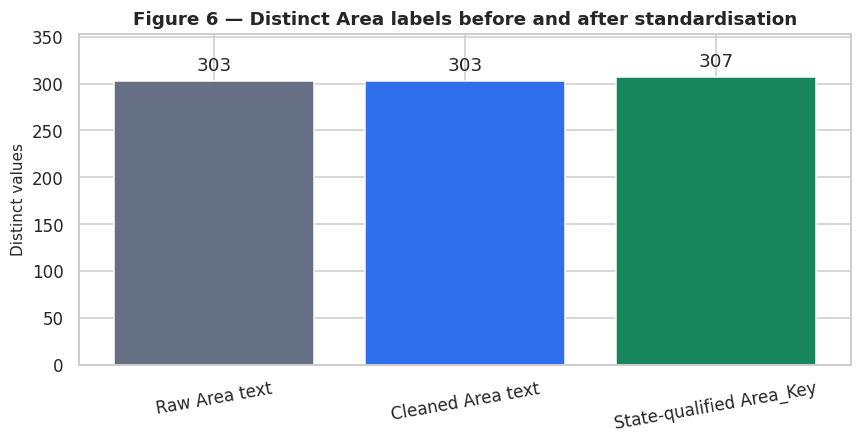

In [18]:
area_label_summary = pd.DataFrame({
    "Stage": ["Raw Area text", "Cleaned Area text", "State-qualified Area_Key"],
    "Distinct labels": [df_work["Area_Raw"].nunique(), df_work["Area_Clean"].nunique(), df_work["Area_Key"].nunique()],
})
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(area_label_summary["Stage"], area_label_summary["Distinct labels"], color=["#667085", "#2F6FED", "#18875D"])
ax.bar_label(bars, padding=4, fmt="%.0f")
ax.set_ylabel("Distinct values")
ax.set_title("Figure 6 — Distinct Area labels before and after standardisation")
ax.tick_params(axis="x", rotation=10)
ax.set_ylim(0, area_label_summary["Distinct labels"].max() * 1.15)
plt.tight_layout(); save_fig("fig06_area_labels_before_after.png"); plt.show()

**Insight (Figure 6).** Text cleaning did not merge different Area labels, but some
Area names occurred in multiple states. Therefore, combining `State` and `Area`
created 307 unique location categories.

- **Raw Area text** — distinct Area labels before standardisation.
- **Cleaned Area text** — distinct Area labels after case, whitespace and
  punctuation normalisation.
- **State-qualified Area_Key** — the modelling key. The same Area name can exist in
  two states (for example *Cheras* in Kuala Lumpur and *Cheras* in Selangor), and
  the state prefix keeps them as separate locations.

## 2.4 Outlier assessment — flagged and **retained**

The 1.5×IQR rule is applied to the log1p-transformed `Median_Price` and
`Median_PSF` to *identify* extreme values. **No record is deleted.**


In [19]:
def iqr_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

outlier_comparison = []
for col in ["Median_Price", "Median_PSF", "Transactions"]:
    log_flags = iqr_mask(np.log1p(df_work[col]))
    q1, q3 = np.log1p(df_work[col]).quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = max(0, np.expm1(q1 - 1.5 * iqr))
    upper = np.expm1(q3 + 1.5 * iqr)
    outlier_comparison.append({
        "Column": col,
        "Log-IQR Lower Fence": lower,
        "Log-IQR Upper Fence": upper,
        "Log-IQR Flagged (retained)": int(log_flags.sum()),
    })
outlier_table = pd.DataFrame(outlier_comparison)
display(outlier_table.round(2))


outlier_flag = (iqr_mask(np.log1p(df_work["Median_Price"]))
                | iqr_mask(np.log1p(df_work["Median_PSF"])))
df_work["Outlier_Flag"] = outlier_flag
df = df_work.copy()

price_only = int(iqr_mask(np.log1p(df_work["Median_Price"])).sum())
psf_only = int((iqr_mask(np.log1p(df_work["Median_PSF"]))
                & ~iqr_mask(np.log1p(df_work["Median_Price"]))).sum())
low_end = int((df_work.loc[outlier_flag, "Median_Price"]
               < outlier_table.loc[0, "Log-IQR Lower Fence"]).sum())
high_end = int((df_work.loc[outlier_flag, "Median_Price"]
                > outlier_table.loc[0, "Log-IQR Upper Fence"]).sum())

print(f"Records flagged as extreme : {outlier_flag.sum():,} ({outlier_flag.mean()*100:.1f}%)")
print(f"  - below the lower price fence (affordable segment) : {low_end}")
print(f"  - above the upper price fence (premium segment)    : {high_end}")
print(f"  - flagged on Median_PSF only                       : {psf_only}")
print(f"Records DELETED            : 0  <- all extreme values are retained")
print(f"Rows carried forward       : {len(df):,}")
print(f"Full price range retained  : RM {df['Median_Price'].min():,.0f} "
      f"to RM {df['Median_Price'].max():,.0f}")

,Column,Log-IQR Lower Fence,Log-IQR Upper Fence,Log-IQR Flagged (retained)
0,Median_Price,87177.98,1775851.27,73
1,Median_PSF,68.10,1206.39,30
2,Transactions,2.90,95.62,70


Records flagged as extreme : 86 (4.3%)
  - below the lower price fence (affordable segment) : 38
  - above the upper price fence (premium segment)    : 35
  - flagged on Median_PSF only                       : 13
Records DELETED            : 0  <- all extreme values are retained
Rows carried forward       : 2,000
Full price range retained  : RM 27,049 to RM 11,420,500


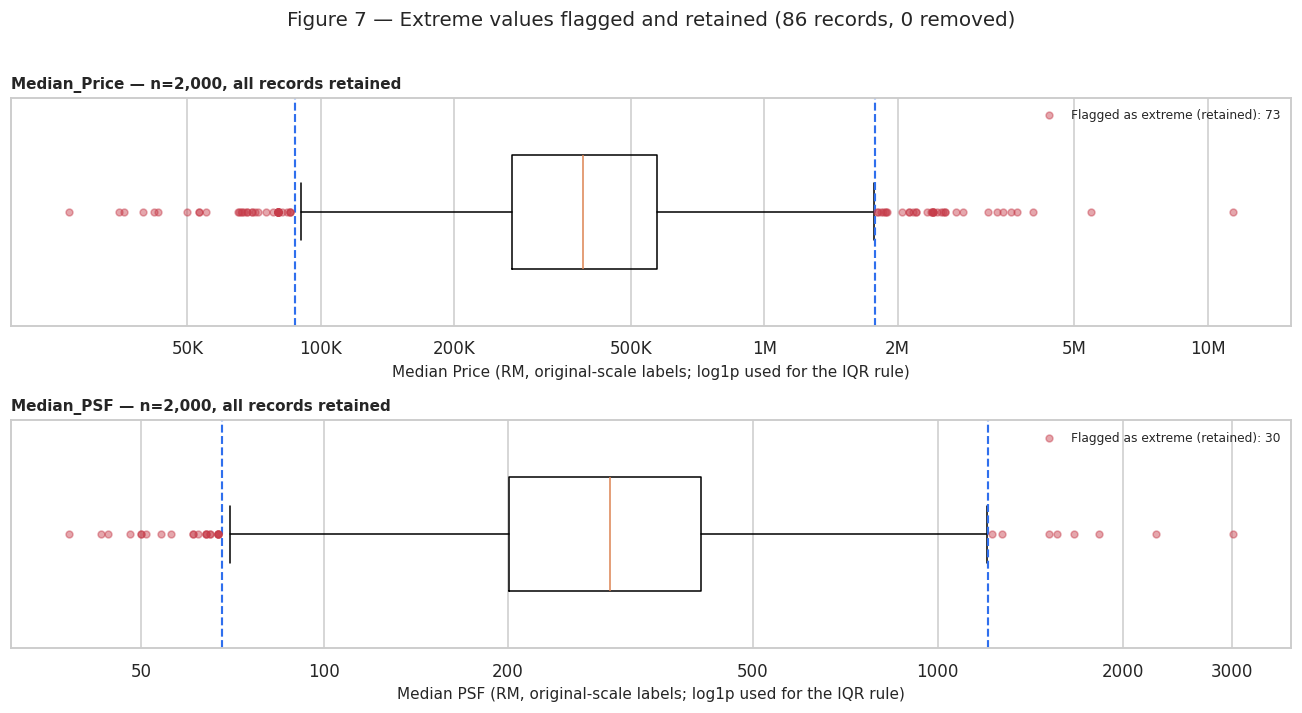

In [20]:
def log_iqr_fences(series, k=1.5):
    log_values = np.log1p(series)
    q1, q3 = log_values.quantile(0.25), log_values.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

fig, axes = plt.subplots(2, 1, figsize=(12, 6.4))

specs = [
    ("Median_Price", [50_000, 100_000, 200_000, 500_000, 1_000_000,
                      2_000_000, 5_000_000, 10_000_000],
     ["50K", "100K", "200K", "500K", "1M", "2M", "5M", "10M"],
     "Median Price (RM, original-scale labels; log1p used for the IQR rule)"),
    ("Median_PSF", [50, 100, 200, 500, 1000, 2000, 3000],
     ["50", "100", "200", "500", "1000", "2000", "3000"],
     "Median PSF (RM, original-scale labels; log1p used for the IQR rule)"),
]

for ax, (col, ticks, tick_labels, xlabel) in zip(axes, specs):
    values_log = np.log1p(df[col])
    lower, upper = log_iqr_fences(df[col])
    flags = (values_log < lower) | (values_log > upper)

    ax.boxplot(values_log, vert=False, widths=0.5, showfliers=False)
    ax.scatter(values_log[flags], np.ones(int(flags.sum())),
               s=20, alpha=0.45, color="#C63C4A", zorder=3,
               label=f"Flagged as extreme (retained): {int(flags.sum())}")
    ax.axvline(lower, linestyle="--", linewidth=1.4, color="#2F6FED")
    ax.axvline(upper, linestyle="--", linewidth=1.4, color="#2F6FED")
    ax.set_xticks(np.log1p(ticks)); ax.set_xticklabels(tick_labels)
    ax.set_yticks([]); ax.set_xlabel(xlabel)
    ax.set_title(f"{col} — n={len(df):,}, all records retained",
                 loc="left", fontsize=10)
    ax.legend(loc="upper right", fontsize=8, frameon=False)

plt.suptitle(f"Figure 7 — Extreme values flagged and retained "
             f"({int(outlier_flag.sum())} records, 0 removed)", y=1.01, fontsize=13)
plt.tight_layout(); save_fig("fig07_outlier_flagged_retained.png"); plt.show()

**Insight (Figure 7).** Applying the 1.5×IQR rule to the log1p-transformed values
flags **73 records on `Median_Price` and 30 on `Median_PSF`**, which combine to
**86 unique records (4.3%)** because 17 records are extreme on both variables at
once. That overlap is why the total is not 73 + 30.


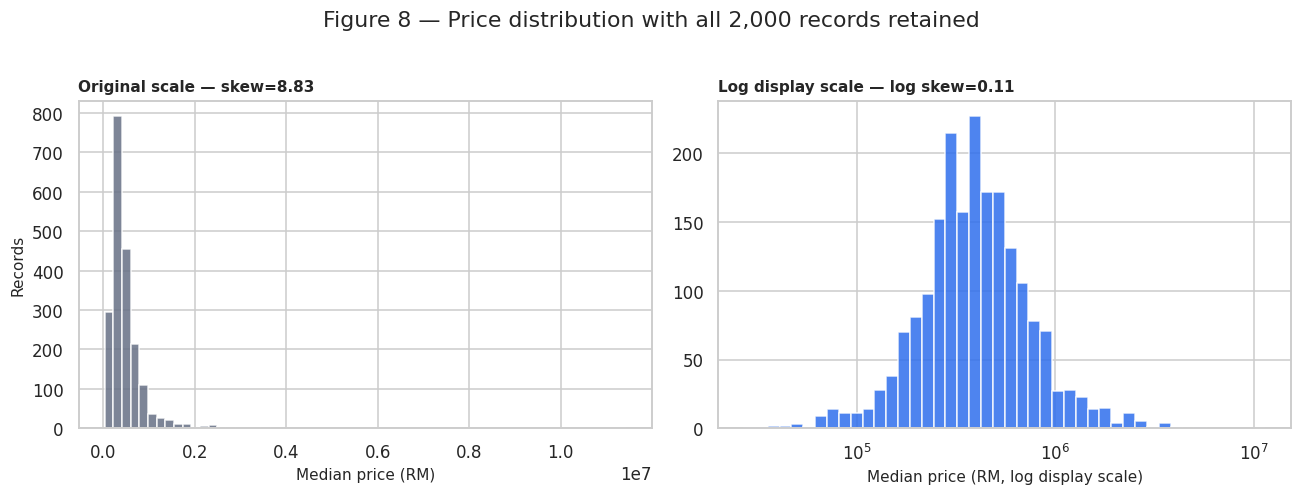

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
price = df["Median_Price"]

# Left: original scale - shows how the retained tail dominates the axis
axes[0].hist(price, bins=60, color="#667085", alpha=0.85)
axes[0].set_title(f"Original scale — skew={price.skew():.2f}", loc="left", fontsize=10)
axes[0].set_xlabel("Median price (RM)")
axes[0].set_ylabel("Records")

# Right: log scale - the same retained records, shape made readable
bins = np.logspace(np.log10(price.min()), np.log10(price.max()), 45)
axes[1].hist(price, bins=bins, color="#2F6FED", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_title(f"Log display scale — log skew={np.log1p(price).skew():.2f}",
                  loc="left", fontsize=10)
axes[1].set_xlabel("Median price (RM, log display scale)")

plt.suptitle(f"Figure 8 — Price distribution with all {len(df):,} records retained", y=1.02)
plt.tight_layout(); save_fig("fig08_price_distribution_retained.png"); plt.show()

**Insight (Figure 8).** Both panels show the **same 2,000 retained records**; only
the display scale differs. On the original scale the distribution appears almost
entirely compressed at the left because the retained premium properties stretch the
axis to RM11.4M. The log display scale reveals the underlying shape, which is
approximately symmetric (log skewness ≈ 0.11).

This is the practical consequence of retaining the full market: the raw target stays
heavily right-skewed, which the tree-based models in Part 4 handle without requiring
the target to be transformed.

## 2.5 Area coverage across the full retained dataset

,Measure,Value
0,Final rows,2000.0
1,Distinct Area_Key values,307.0
2,Singleton Areas,74.0
3,Repeated Areas,233.0
4,Rows in repeated Areas,1926.0
5,Median rows per Area,4.0
6,Areas with ≥5 rows,129.0
7,Areas with ≥10 rows,58.0


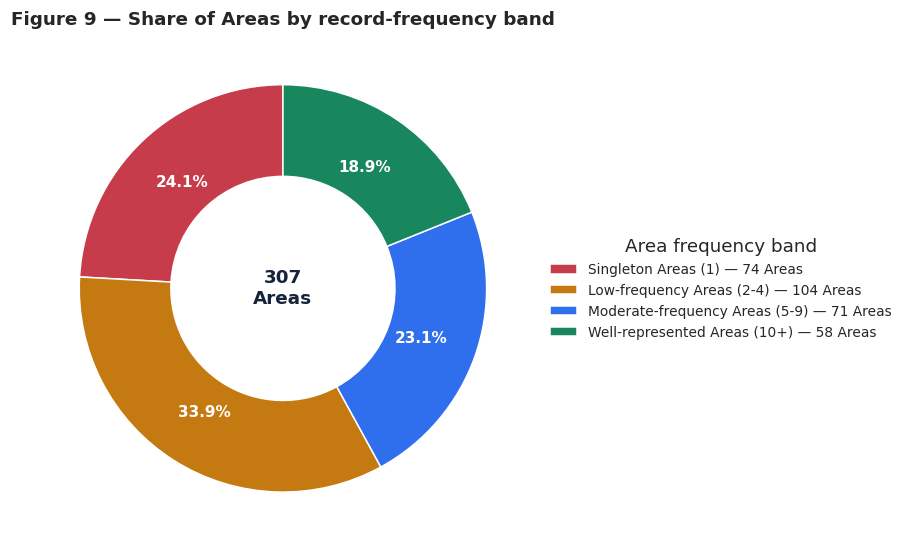

,Areas,Share (%)
count,,
Singleton Areas (1),74,24.1
Low-frequency Areas (2-4),104,33.9
Moderate-frequency Areas (5-9),71,23.1
Well-represented Areas (10+),58,18.9


In [22]:
area_counts = df["Area_Key"].value_counts()
row_repeat = pd.Series({
    "Rows in repeated Areas": int(area_counts[area_counts.gt(1)].sum()),
    "Rows in singleton Areas": int(area_counts[area_counts.eq(1)].sum()),
})
distinct_repeat = pd.Series({
    "Repeated Area values": int(area_counts.gt(1).sum()),
    "Singleton Area values": int(area_counts.eq(1).sum()),
})
area_frequency_summary = pd.DataFrame({
    "Measure": ["Final rows", "Distinct Area_Key values", "Singleton Areas", "Repeated Areas",
                "Rows in repeated Areas", "Median rows per Area", "Areas with ≥5 rows", "Areas with ≥10 rows"],
    "Value": [len(df), df["Area_Key"].nunique(), area_counts.eq(1).sum(), area_counts.gt(1).sum(),
              area_counts[area_counts.gt(1)].sum(), area_counts.median(), area_counts.ge(5).sum(), area_counts.ge(10).sum()]
})
display(area_frequency_summary)

# Frequency bands - how much of the Area vocabulary is well represented?
bands = pd.cut(area_counts, bins=[0, 1, 4, 9, np.inf],
               labels=["Singleton Areas (1)", "Low-frequency Areas (2-4)",
                       "Moderate-frequency Areas (5-9)", "Well-represented Areas (10+)"])
band_counts = bands.value_counts().reindex(
    ["Singleton Areas (1)", "Low-frequency Areas (2-4)",
     "Moderate-frequency Areas (5-9)", "Well-represented Areas (10+)"])

fig, ax = plt.subplots(figsize=(7.6, 5.2))
colours = ["#C63C4A", "#C47A10", "#2F6FED", "#18875D"]
wedges, _, autotexts = ax.pie(
    band_counts.values, colors=colours, startangle=90,
    autopct=lambda p: f"{p:.1f}%", pctdistance=0.72,
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(fontsize=10, color="white", fontweight="bold"))
ax.text(0, 0, f"{int(band_counts.sum()):,}\nAreas", ha="center", va="center",
        fontsize=12, fontweight="bold", color="#15243A")
ax.legend(wedges,
          [f"{label} — {count:,} Areas" for label, count in band_counts.items()],
          title="Area frequency band", loc="center left",
          bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=9)
ax.set_title("Figure 9 — Share of Areas by record-frequency band")
plt.tight_layout(); save_fig("fig09_area_frequency_bands.png"); plt.show()

display(band_counts.rename("Areas").to_frame().assign(
    **{"Share (%)": (band_counts / band_counts.sum() * 100).round(1)}))

**Insight (Figure 9).** Across all 2,000 retained records, a large majority belong
to Areas that appear more than once, but a substantial number of Areas appear only
a single time. Those singleton Areas cannot generalise — one record provides no
basis for learning an area-level price pattern. This motivates the `min_frequency`
grouping used by the encoder in Part 4.2, which routes rare and unseen Areas into a
shared bucket instead of giving each one its own unreliable column.

## 2.6 Leakage exclusions and final prepared dataset

`Township` remains excluded because it is near-unique per record and would be
memorised rather than learned. The prepared CSV stores the six unencoded features;
encoding and standardisation happen inside the modelling pipeline after the
train/test split, so no information leaks from test data into training.

**No records were removed during preparation.** The prepared dataset contains all
2,000 original records, with extreme values retained and flagged in
`Outlier_Flag`.

In [23]:
FINAL_COLUMNS = [
    "Township", "Area_Raw", "Area_Clean", "Area_Key", "State", "State_Clean",
    "Tenure", "Type", "Type_Clean", "Primary_Type", "Category",
    "Median_Price", "Median_PSF", "Transactions",
]
df = df[FINAL_COLUMNS].copy()
CLEANED_PATH = "malaysia_house_price_cleaned_with_area.csv"
df.to_csv(CLEANED_PATH, index=False)

MODEL_FEATURES = ["State", "Area_Key", "Tenure", "Primary_Type", "Median_PSF", "Transactions"]
model_ready = df[MODEL_FEATURES + ["Median_Price"]].copy()
model_ready.to_csv("malaysia_house_price_model_ready.csv", index=False)
print(f"Saved {CLEANED_PATH}: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Final model features:", MODEL_FEATURES)
display(df.head())

Saved malaysia_house_price_cleaned_with_area.csv: 2,000 rows × 14 columns
Final model features: ['State', 'Area_Key', 'Tenure', 'Primary_Type', 'Median_PSF', 'Transactions']


,Township,Area_Raw,Area_Clean,Area_Key,State,State_Clean,Tenure,Type,Type_Clean,Primary_Type,Category,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,TASEK GELUGOR,PENANG | TASEK GELUGOR,Penang,PENANG,Freehold,Terrace House,Terrace House,Terrace House,Landed,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,KULAI,JOHOR | KULAI,Johor,JOHOR,Freehold,"Cluster House, Terrace House","Cluster House, Terrace House",Cluster House,Landed,590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,CHENDERIANG,PERAK | CHENDERIANG,Perak,PERAK,Freehold,Terrace House,Terrace House,Terrace House,Landed,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,BEMBAN,MELAKA | BEMBAN,Melaka,MELAKA,Freehold,Terrace House,Terrace House,Terrace House,Landed,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,TAPAH,PERAK | TAPAH,Perak,PERAK,Leasehold,Terrace House,Terrace House,Terrace House,Landed,219300.0,168.0,363


---
# PART 3 — EXPLORATORY DATA ANALYSIS


| Section | Analyses | Question answered |
|---|---|---|
| 3.2 Market representation and composition | 1–3 | What does the prepared market look like? |
| 3.3 Housing price variation | 4–9 | Where, and between which groups, does price vary? |
| 3.4 Numerical relationships and correlation | 10–13 | Which variables are related to price? |
| 3.5 Combined market effects | 14–15 | Do factors interact with one another? |

**A note on the retained extreme values.** Because no records were deleted in
Part 2, the price axis spans the full RM27,049–RM11,420,500 range. Boxplots below
therefore hide flier markers (`showfliers=False`) so the boxes stay readable; the
records themselves remain in every calculation.

## 3.1 Descriptive summary of key market segments

Tables only — these provide the exact numbers behind the visual analyses that
follow and are **not counted among the fifteen figures**. Small groups are not
treated as equally reliable evidence, so the Area table reports only major Areas.

In [24]:
def grouped_summary(frame: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        frame.groupby(group_col, dropna=False)
        .agg(
            Records=("Median_Price", "size"),
            Median_price_RM=("Median_Price", "median"),
            Mean_price_RM=("Median_Price", "mean"),
            Price_std_RM=("Median_Price", "std"),
            Minimum_price_RM=("Median_Price", "min"),
            Maximum_price_RM=("Median_Price", "max"),
            Median_PSF_RM=("Median_PSF", "median"),
            Median_transactions=("Transactions", "median"),
        )
        .sort_values(["Median_price_RM", "Records"], ascending=[False, False])
    )

state_summary = grouped_summary(df, "State")
area_summary_all = grouped_summary(df, "Area_Key")
area_summary = area_summary_all[area_summary_all["Records"] >= 15].copy()
area_summary.index = [
    display_name(v.replace(" | ", " — ")) for v in area_summary.index
]
property_type_summary = grouped_summary(df, "Primary_Type")
tenure_summary = grouped_summary(df, "Tenure")
category_summary = grouped_summary(df, "Category")

print("State summary")
display(state_summary.round(1))
print("Major Area summary (minimum 15 records)")
display(area_summary.round(1))
print("Primary property type summary")
display(property_type_summary.round(1))
print("Tenure summary")
display(tenure_summary.round(1))
print("Landed / High-Rise summary")
display(category_summary.round(1))


State summary


,Records,Median_price_RM,Mean_price_RM,Price_std_RM,Minimum_price_RM,Maximum_price_RM,Median_PSF_RM,Median_transactions
State,,,,,,,,
Putrajaya,3,880000.0,796666.7,510130.7,250000.0,1260000.0,465.0,18.0
Kuala Lumpur,176,502500.0,853342.1,1125166.4,110000.0,11420500.0,448.0,14.0
Selangor,545,475000.0,594347.6,407836.7,36000.0,2700000.0,370.0,17.0
Johor,377,420000.0,484990.4,284101.1,35000.0,2386358.0,322.0,21.0
Perlis,1,414428.0,414428.0,NaN,414428.0,414428.0,205.0,29.0
Penang,187,350000.0,475844.4,414570.9,43000.0,3450000.0,338.0,15.0
Sarawak,54,350000.0,373358.9,190493.7,65500.0,865000.0,198.0,13.5
Kelantan,3,342500.0,379166.7,79149.1,325000.0,470000.0,97.0,13.0
Terengganu,12,325000.0,280945.8,88274.4,66500.0,360000.0,112.0,23.5


Major Area summary (minimum 15 records)


,Records,Median_price_RM,Mean_price_RM,Price_std_RM,Minimum_price_RM,Maximum_price_RM,Median_PSF_RM,Median_transactions
Selangor — Petaling Jaya,20,916500.0,1001925.0,383058.5,380000.0,1700000.0,445.0,17.5
Selangor — Setia Alam,17,705000.0,818323.5,617211.6,200000.0,2450000.0,507.0,16.0
Selangor — Dengkil,15,669600.0,720872.5,372571.7,180000.0,1450000.0,393.0,17.0
Johor — Tebrau,34,657000.0,606361.8,312883.4,53000.0,1201200.0,428.5,21.5
Selangor — Subang Jaya,32,630000.0,688203.1,382047.7,211000.0,2125000.0,476.5,17.0
Selangor — Shah Alam,37,590000.0,602040.2,356351.8,169000.0,1750000.0,376.0,17.0
Selangor — Puchong,35,562500.0,659071.4,378411.3,105000.0,1890000.0,454.0,16.0
Johor — Iskandar Puteri (Nusajaya),34,545000.0,626866.2,269606.9,200000.0,1344000.0,421.5,18.5
Selangor — Cheras,16,509250.0,672093.8,601628.0,165000.0,2700000.0,412.5,19.5
Johor — Skudai,45,498000.0,539398.7,289685.7,130000.0,1350000.0,334.0,28.0


Primary property type summary


,Records,Median_price_RM,Mean_price_RM,Price_std_RM,Minimum_price_RM,Maximum_price_RM,Median_PSF_RM,Median_transactions
Primary_Type,,,,,,,,
Bungalow,97,600000.0,907030.8,731274.1,152660.0,3600000.0,258.0,19.0
Condominium,169,485000.0,658713.5,546629.7,84000.0,3350000.0,437.0,14.0
Semi D,248,471400.0,547505.0,328768.6,150000.0,2400000.0,238.0,16.0
Service Residence,96,470000.0,813408.7,1341398.9,170000.0,11420500.0,532.5,16.5
Cluster House,80,434000.0,545944.3,301274.7,143000.0,1449665.0,288.0,24.0
Terrace House,972,392500.0,456965.9,275115.3,27049.0,3450000.0,267.5,18.0
Town House,7,352500.0,389642.9,96203.2,280000.0,510000.0,274.0,13.0
Apartment,200,290000.0,285607.2,96696.8,35000.0,650000.0,338.0,15.0
Flat,131,155000.0,156506.9,56383.9,42000.0,320000.0,243.0,16.0


Tenure summary


,Records,Median_price_RM,Mean_price_RM,Price_std_RM,Minimum_price_RM,Maximum_price_RM,Median_PSF_RM,Median_transactions
Tenure,,,,,,,,
Mixed,58,419625.0,503094.3,358025.6,190000.0,2400000.0,269.0,18.0
Freehold,1318,418400.0,535689.8,517905.1,27049.0,11420500.0,310.0,17.0
Leasehold,624,329345.0,394474.6,335197.2,42000.0,5460000.0,270.0,16.0


Landed / High-Rise summary


,Records,Median_price_RM,Mean_price_RM,Price_std_RM,Minimum_price_RM,Maximum_price_RM,Median_PSF_RM,Median_transactions
Category,,,,,,,,
Landed,1404,415486.5,508787.1,355519.0,27049.0,3600000.0,262.5,18.0
High-Rise,596,326500.0,448043.1,661216.6,35000.0,11420500.0,368.0,15.0


## 3.2 Market representation and composition

*Analyses 1–3: what does the prepared market actually contain?*

### Analysis 1 — Which states are most and least represented?

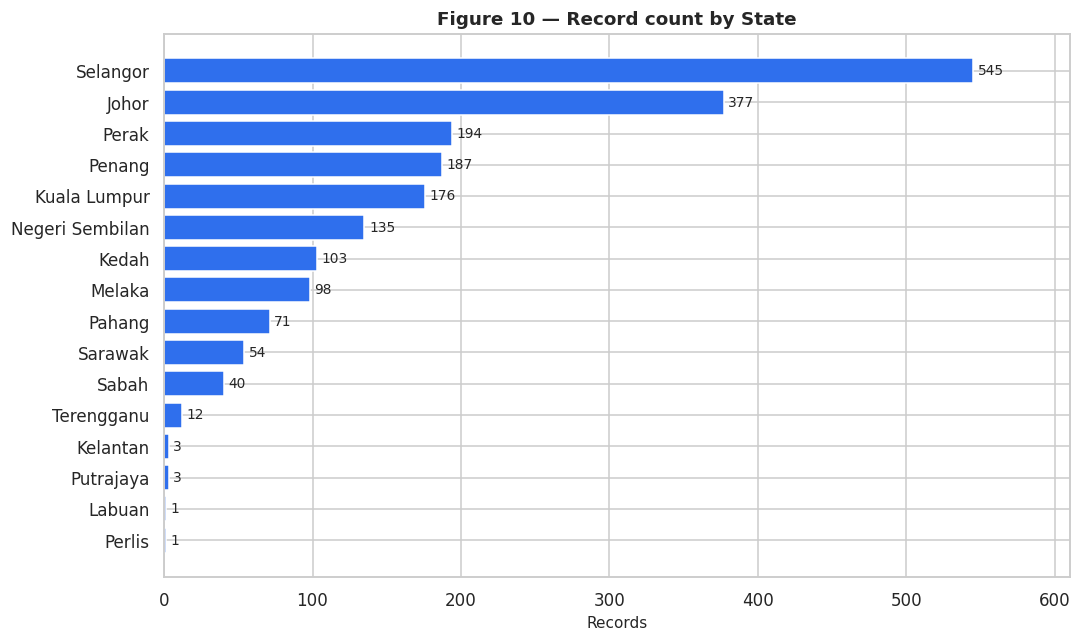

Top 2 states hold 922 of 2,000 records (46%).
States with fewer than 10 records: 4


In [25]:
state_counts = df["State"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(state_counts.index, state_counts.values, color="#2F6FED")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlim(0, state_counts.max() * 1.12)
ax.set_xlabel("Records")
ax.set_title("Figure 10 — Record count by State")
plt.tight_layout(); save_fig("fig10_state_counts.png"); plt.show()

print(f"Top 2 states hold {state_counts.nlargest(2).sum():,} of {len(df):,} records "
      f"({state_counts.nlargest(2).sum()/len(df)*100:.0f}%).")
print(f"States with fewer than 10 records: {int((state_counts < 10).sum())}")

**Insight (Figure 10).** Selangor and Johor contain the most records, while some states have much fewer observations. This means state-level findings for smaller groups should be interpreted carefully. In Part 4, Area_Key is used for group-aware validation to prevent the same local Area from appearing in both training and validation data.

### Analysis 2 — Which property types are most common?

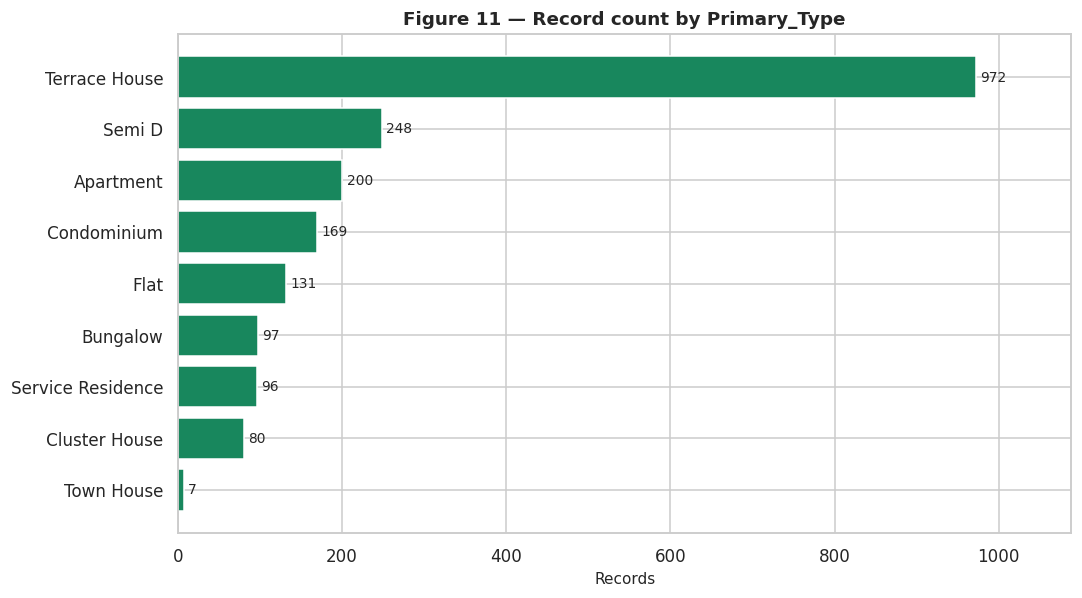

Most common property type: Terrace House (972 records, 49%)


In [26]:
type_counts = df["Primary_Type"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.barh(type_counts.index, type_counts.values, color="#18875D")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlim(0, type_counts.max() * 1.12)
ax.set_xlabel("Records")
ax.set_title("Figure 11 — Record count by Primary_Type")
plt.tight_layout(); save_fig("fig11_property_type_counts.png"); plt.show()

top_type = type_counts.idxmax()
print(f"Most common property type: {top_type} "
      f"({type_counts.max():,} records, {type_counts.max()/len(df)*100:.0f}%)")

**Insight (Figure 11).** Terrace House dominates the dataset by a wide margin,
while several types (Town House, Bungalow, Cluster House) have comparatively few
records. The model consequently has far more evidence about mainstream terraced
housing than about premium or niche property types, which is a limitation carried
into Evaluation.

### Analysis 3 — What proportion of the market is Landed versus High-Rise?

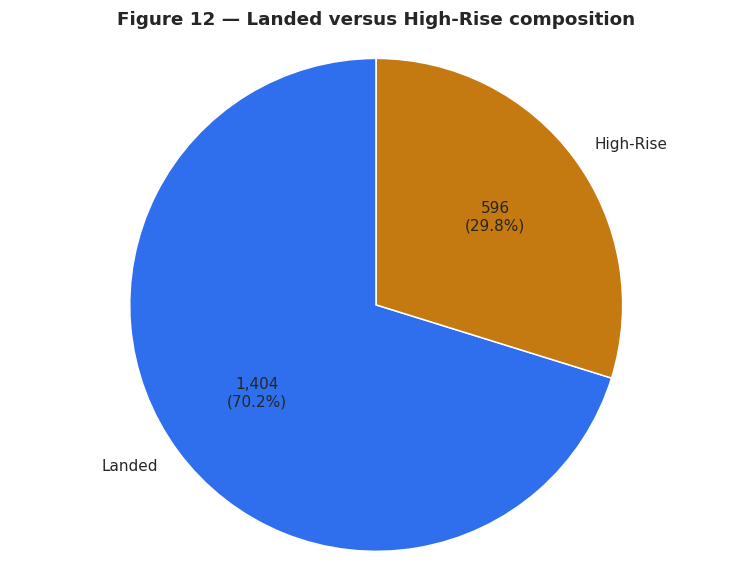

In [27]:
category_counts = df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5.5))

colors = ["#2F6FED", "#C47A10"][:len(category_counts)]

# Show both count and percentage
def show_count_pct(pct):
    total = category_counts.sum()
    count = int(round(pct / 100 * total))
    return f"{count:,}\n({pct:.1f}%)"

ax.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct=show_count_pct,
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10}
)

ax.set_title("Figure 12 — Landed versus High-Rise composition")
ax.axis("equal")

plt.tight_layout()
save_fig("fig12_category_share.png")
plt.show()

**Insight (Figure 12).** Landed properties make up about 70% of the dataset, while High-Rise properties account for about 30%. This shows that the dataset contains more Landed than High-Rise records. These percentages describe the composition of this dataset only and do not represent Malaysia’s overall housing market.

## 3.3 Housing price variation

*Analyses 4–9: where, and between which property groups, does price differ?*

Boxplot outlier markers are hidden for readability, but all records are retained in the analysis.

### Analysis 4 — How does Median_Price vary by State?

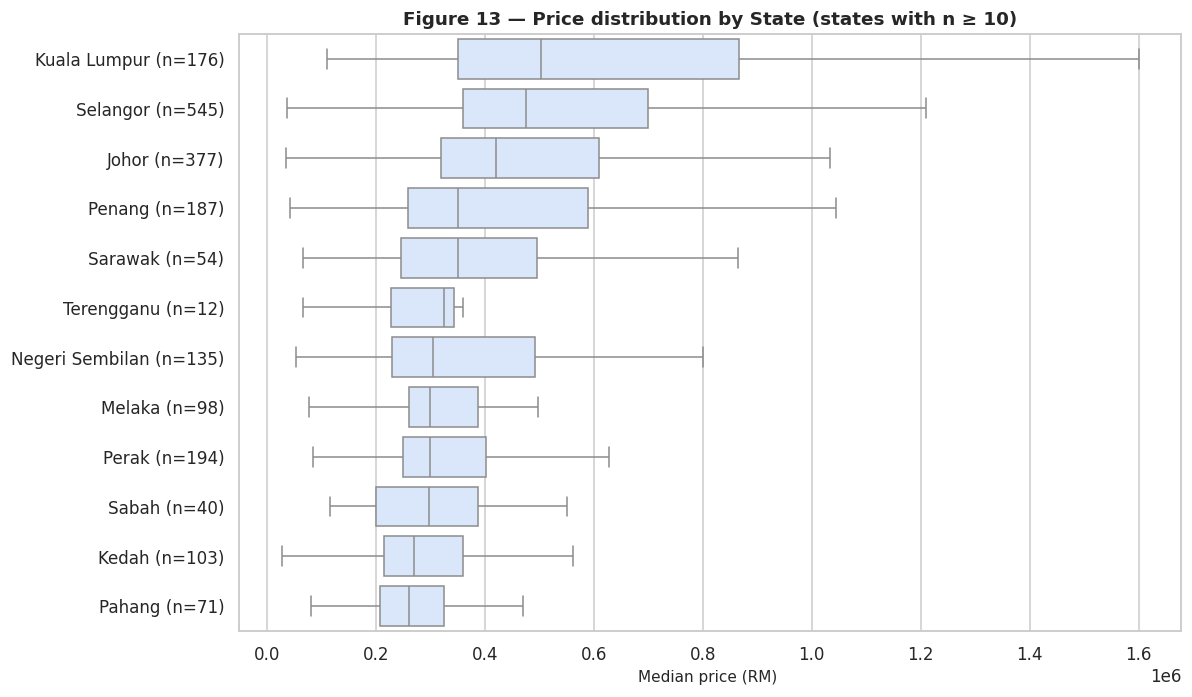

In [28]:
state_n = df["State"].value_counts()
major_states = state_n[state_n >= 10].index
state_data = df[df["State"].isin(major_states)]
order = state_data.groupby("State")["Median_Price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(data=state_data, x="Median_Price", y="State", order=order,
            showfliers=False, color="#D5E4FF", ax=ax)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{s} (n={state_n[s]:,})" for s in order])
ax.set_xlabel("Median price (RM) ")
ax.set_ylabel("")
ax.set_title("Figure 13 — Price distribution by State (states with n ≥ 10)")
plt.tight_layout(); save_fig("fig13_state_price.png"); plt.show()

States with fewer than 10 records were excluded from the boxplot because extremely small groups do not provide a reliable representation of the price distribution. The chart is arranged by median price from high to low.

**Insight (Figure 13).** Kuala Lumpur and Selangor show clearly higher median prices
than others. However, **every box is wide** — the spread
*within* a single state is large relative to the differences *between* states. State
alone therefore explains only part of the variation in price, which motivates
testing a finer location feature in the next analysis.



Median prices differ across states, indicating that State contains useful location information. However, the substantial variation within each state shows that State alone does not capture all differences in housing prices. Therefore, Area is examined next as a more detailed location feature.

### Analysis 5 — How does Median_Price vary by Area?

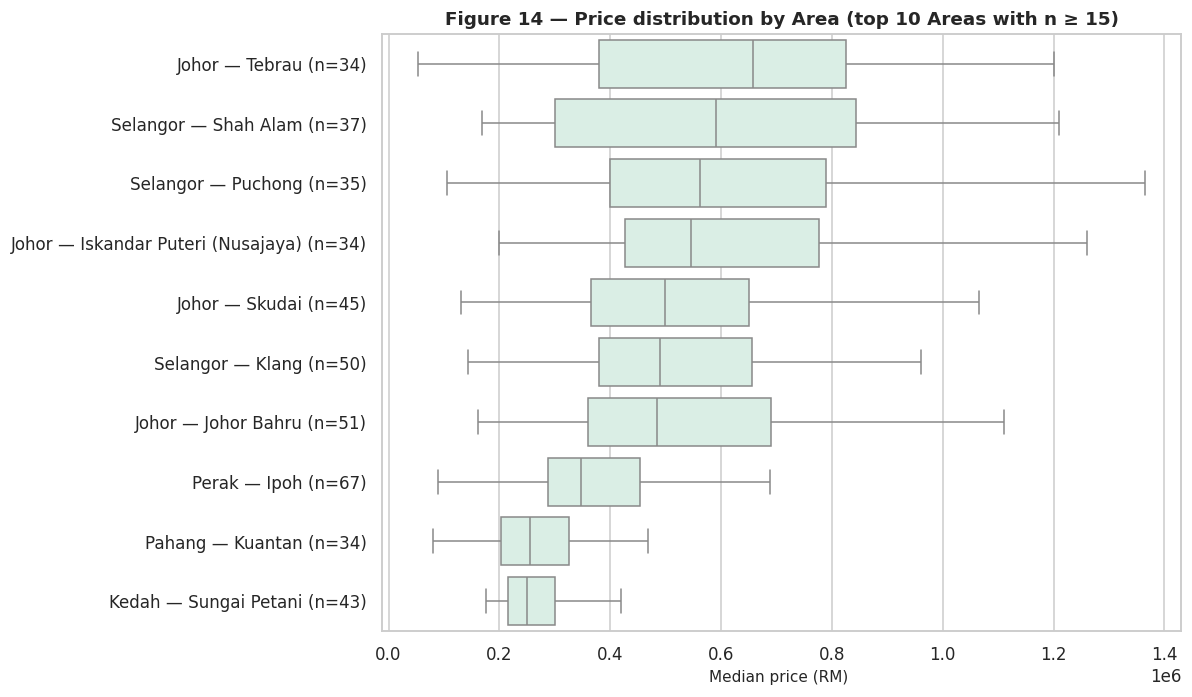

In [29]:
MIN_AREA_N = 15
TOP_AREAS = 10
area_counts_eda = df["Area_Key"].value_counts()
area_keys = area_counts_eda[area_counts_eda >= MIN_AREA_N].head(TOP_AREAS).index
area_data = df[df["Area_Key"].isin(area_keys)].copy()
area_data["Area display"] = area_data["Area_Key"].map(
    lambda v: display_name(v.replace(" | ", " — ")))
order = area_data.groupby("Area display")["Median_Price"].median().sort_values(ascending=False).index
area_n = area_data["Area display"].value_counts()

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(data=area_data, x="Median_Price", y="Area display", order=order,
            showfliers=False, color="#D7F1E5", ax=ax)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{a} (n={area_n[a]})" for a in order])
ax.set_xlabel("Median price (RM) ")
ax.set_ylabel("")
ax.set_title(f"Figure 14 — Price distribution by Area (top {TOP_AREAS} Areas with n ≥ {MIN_AREA_N})")
plt.tight_layout(); save_fig("fig14_area_price.png"); plt.show()

Insight (Figure 14). Median prices differ clearly across Areas, showing that Area provides more detailed location information than State alone. This supports testing Area_Key as a model feature.

Only Areas with at least 15 records are shown so that the comparison is based on more reliable groups. The usefulness of Area_Key is tested further in Part 4.

### Analysis 6 — How does price vary by property type?

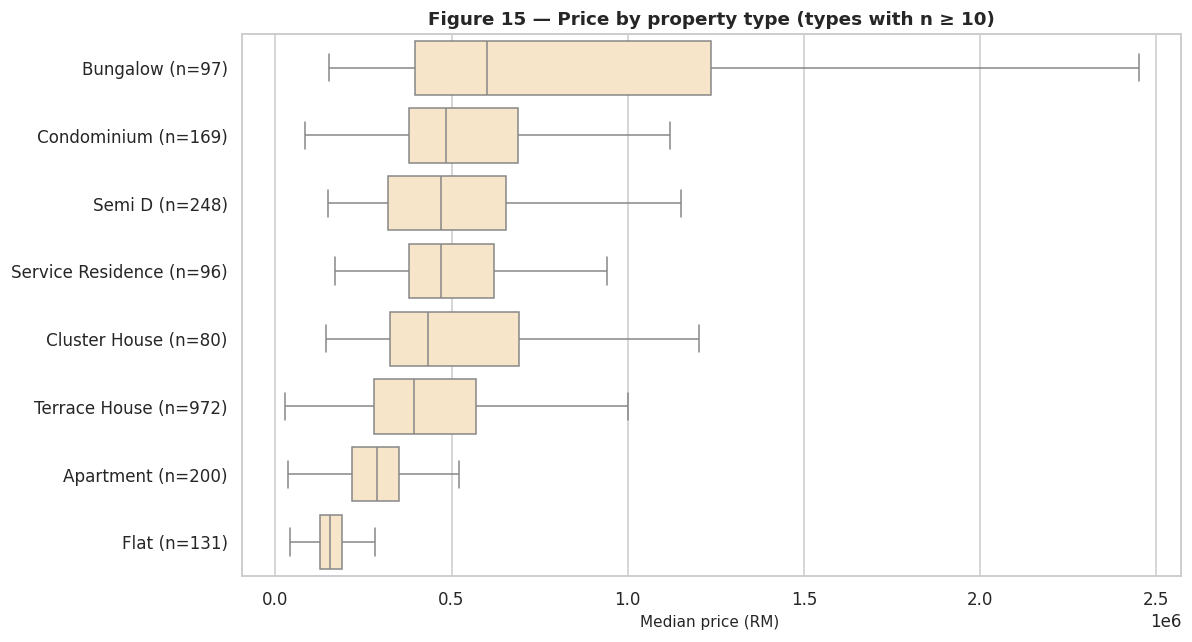

In [30]:
ptype_counts = df["Primary_Type"].value_counts()
major_types = ptype_counts[ptype_counts >= 10].index
ptype_data = df[df["Primary_Type"].isin(major_types)]
order = ptype_data.groupby("Primary_Type")["Median_Price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=ptype_data, x="Median_Price", y="Primary_Type", order=order,
            showfliers=False, color="#FFE7C2", ax=ax)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{t} (n={ptype_counts[t]:,})" for t in order])
ax.set_xlabel("Median price (RM) ")
ax.set_ylabel("")
ax.set_title("Figure 15 — Price by property type (types with n ≥ 10)")
plt.tight_layout(); save_fig("fig15_property_type_price.png"); plt.show()

**Insight (Figure 15).** Different property types have different price levels. Flats and Apartments are generally cheaper, while Semi-D and Bungalows are more expensive. The wide price ranges also show that property type alone cannot fully explain housing price.

### Analysis 7 — How does price vary by tenure?

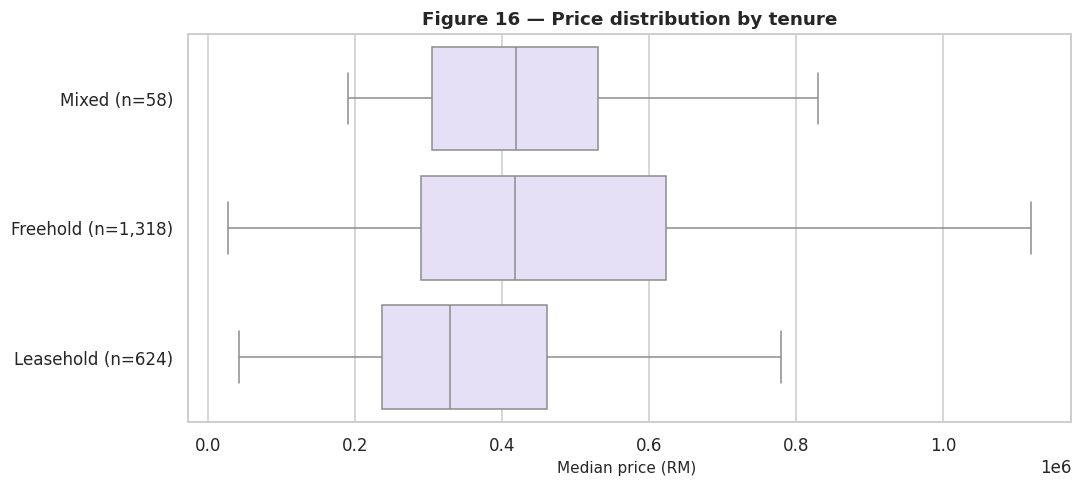

,Records,Median,Mean
Tenure,,,
Freehold,1318,418400.0,535690.0
Leasehold,624,329345.0,394475.0
Mixed,58,419625.0,503094.0


In [31]:
tenure_counts = df["Tenure"].value_counts()
order = df.groupby("Tenure")["Median_Price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4.6))
sns.boxplot(data=df, x="Median_Price", y="Tenure", order=order,
            showfliers=False, color="#E4DCFB", ax=ax)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{t} (n={tenure_counts[t]:,})" for t in order])
ax.set_xlabel("Median price (RM) ")
ax.set_ylabel("")
ax.set_title("Figure 16 — Price distribution by tenure")
plt.tight_layout(); save_fig("fig16_tenure_price.png"); plt.show()

display(df.groupby("Tenure")["Median_Price"].agg(
    Records="size", Median="median", Mean="mean").round(0))

**Insight (Figure 16).** Mixed and Freehold properties have similar median prices, while Leasehold properties have a lower median price. However, the Mixed group has only 58 records, so its result should be interpreted carefully.

### Analysis 8 — Do Landed and High-Rise properties show different prices?

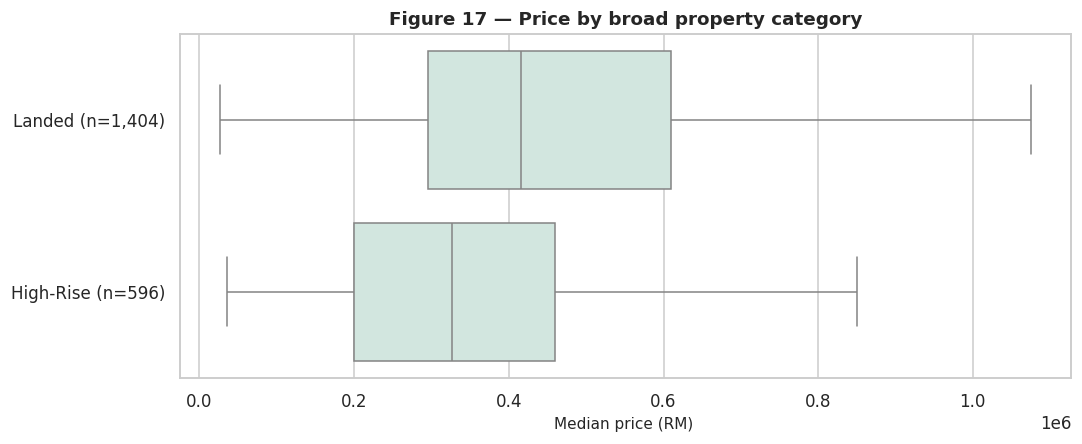

,Records,Median,Q1,Q3
Category,,,,
High-Rise,596,326500.0,200000.0,460000.0
Landed,1404,415486.0,295000.0,610000.0


In [32]:
fig, ax = plt.subplots(figsize=(10, 4.2))
order = df.groupby("Category")["Median_Price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Median_Price", y="Category", order=order,
            showfliers=False, color="#CFE9E0", ax=ax)
cat_n = df["Category"].value_counts()
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{c} (n={cat_n[c]:,})" for c in order])
ax.set_xlabel("Median price (RM) ")
ax.set_ylabel("")
ax.set_title("Figure 17 — Price by broad property category")
plt.tight_layout(); save_fig("fig17_category_price.png"); plt.show()

display(df.groupby("Category")["Median_Price"].agg(
    Records="size", Median="median", Q1=lambda s: s.quantile(.25),
    Q3=lambda s: s.quantile(.75)).round(0))

**Insight (Figure 17).**  Landed properties have a higher median price than High-Rise properties. However, their price ranges overlap, showing that property category alone does not fully explain housing price.

### Analysis 9 — How does Median_PSF vary across States?

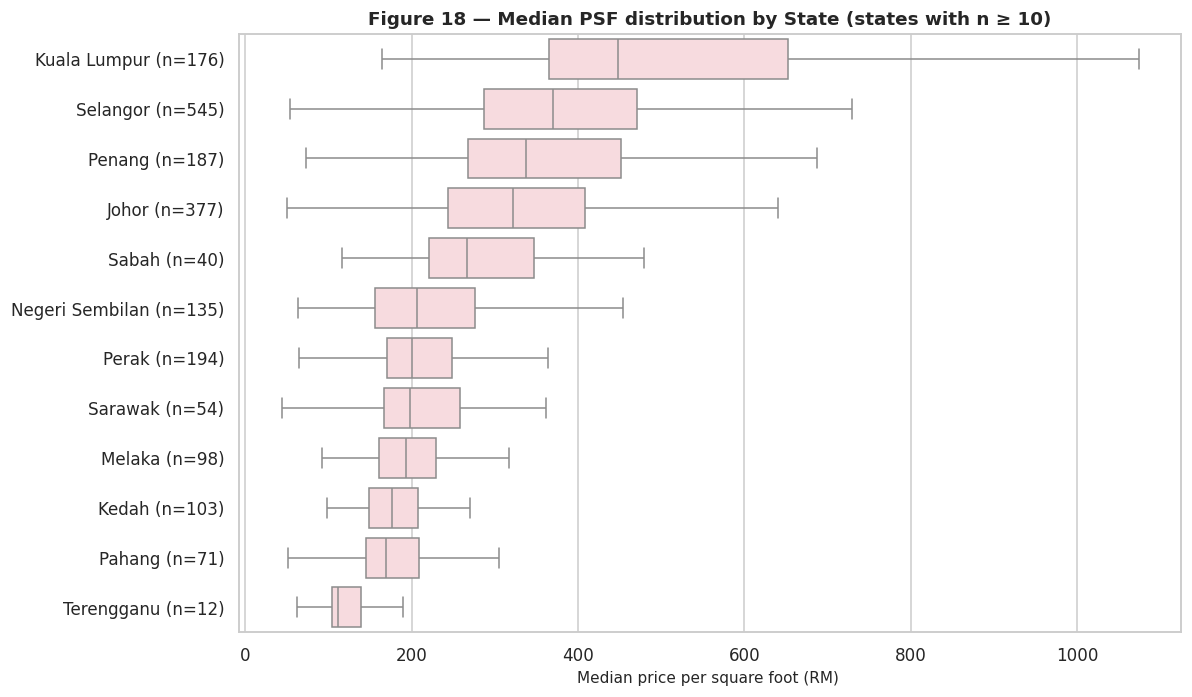

In [33]:
psf_state_data = df[df["State"].isin(major_states)]
order = psf_state_data.groupby("State")["Median_PSF"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.boxplot(data=psf_state_data, x="Median_PSF", y="State", order=order,
            showfliers=False, color="#FBD7DC", ax=ax)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{s} (n={state_n[s]:,})" for s in order])
ax.set_xlabel("Median price per square foot (RM) ")
ax.set_ylabel("")
ax.set_title("Figure 18 — Median PSF distribution by State (states with n ≥ 10)")
plt.tight_layout(); save_fig("fig18_state_psf.png"); plt.show()

**Insight (Figure 18).** Median price per square foot differs across states. Kuala Lumpur has the highest median PSF, while Terengganu and Pahang are among the lowest. This shows that location is related to PSF and may provide useful information for predicting housing price.

## 3.4 Numerical relationships and correlation

*Analyses 10–13: which variables actually relate to price?*

### Analysis 10 — Is the relationship between Median PSF and Median Price consistent across Landed and High-Rise properties?

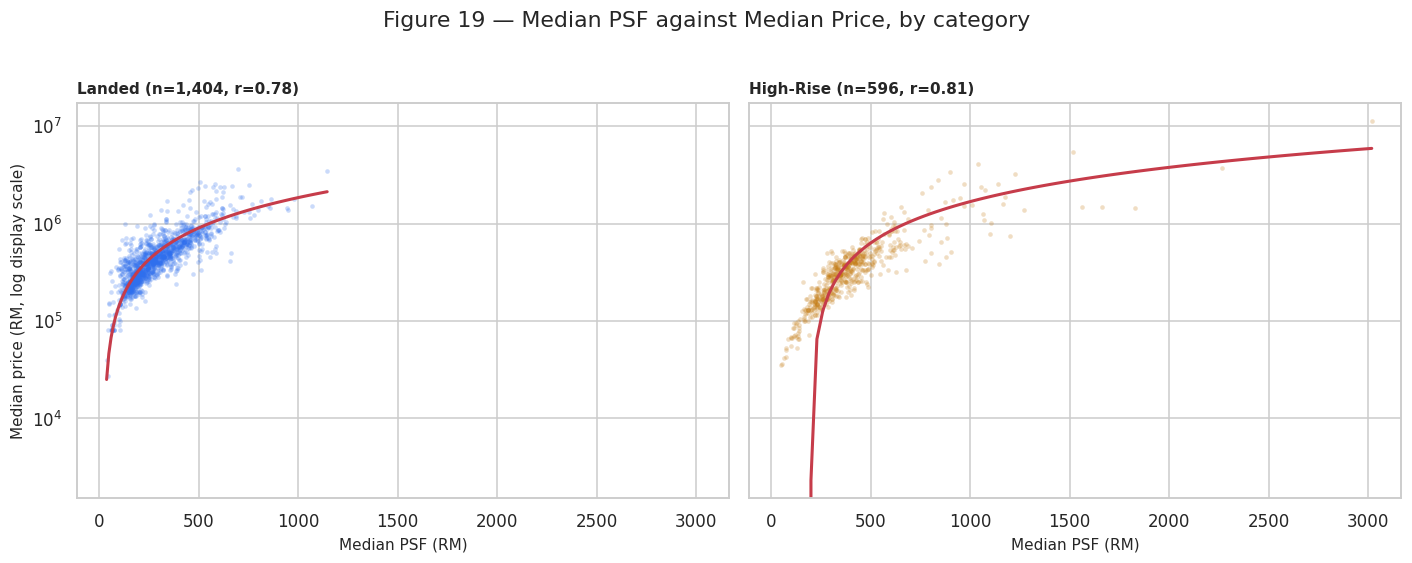

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, category, colour in zip(axes, ["Landed", "High-Rise"], ["#2F6FED", "#C47A10"]):
    part = df[df["Category"] == category]
    ax.scatter(part["Median_PSF"], part["Median_Price"], s=9, alpha=0.25,
               color=colour, linewidths=0)
    if len(part) > 1:
        slope, intercept = np.polyfit(part["Median_PSF"], part["Median_Price"], 1)
        xs = np.linspace(part["Median_PSF"].min(), part["Median_PSF"].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="#C63C4A", linewidth=2)
    r = part["Median_PSF"].corr(part["Median_Price"])
    ax.set_title(f"{category} (n={len(part):,}, r={r:.2f})", loc="left", fontsize=10)
    ax.set_xlabel("Median PSF (RM)")
    ax.set_yscale("log")
axes[0].set_ylabel("Median price (RM, log display scale)")
plt.suptitle("Figure 19 — Median PSF against Median Price, by category", y=1.02)
plt.tight_layout(); save_fig("fig19_psf_price_by_category.png"); plt.show()

**Insight (Figure 19).** Median PSF has a strong positive relationship with Median Price for both Landed (r = 0.78) and High-Rise (r = 0.81) properties. This shows that the relationship is strong across both property categories.

### Analysis 11 — Is transaction activity related to price?

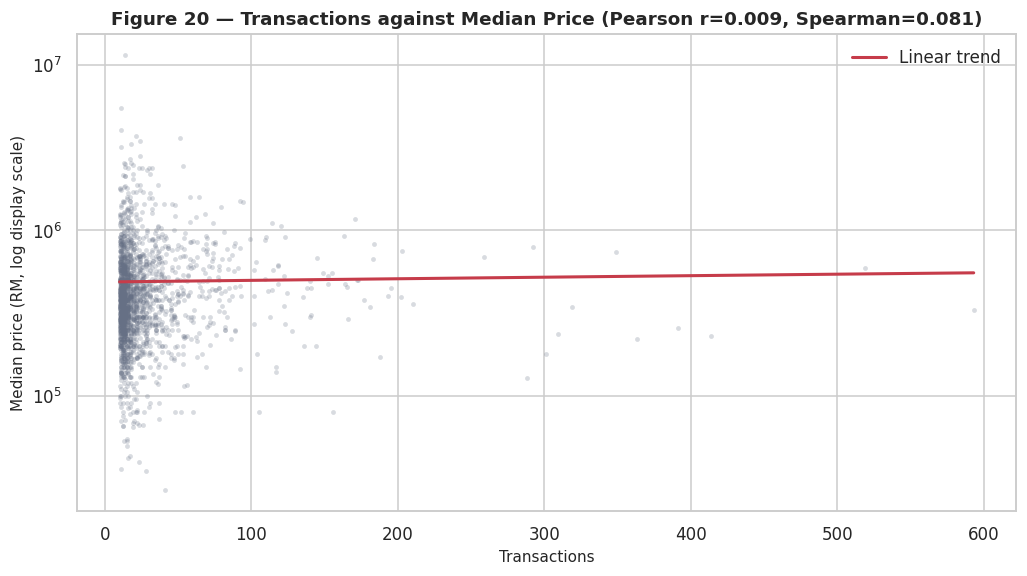

In [35]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(df["Transactions"], df["Median_Price"], s=10, alpha=0.25,
           color="#667085", linewidths=0)
slope, intercept = np.polyfit(df["Transactions"], df["Median_Price"], 1)
xs = np.linspace(df["Transactions"].min(), df["Transactions"].max(), 100)
ax.plot(xs, slope * xs + intercept, color="#C63C4A", linewidth=2, label="Linear trend")
ax.set_yscale("log")
ax.set_xlabel("Transactions")
ax.set_ylabel("Median price (RM, log display scale)")
pearson = df["Transactions"].corr(df["Median_Price"])
spearman = df["Transactions"].corr(df["Median_Price"], method="spearman")
ax.set_title(f"Figure 20 — Transactions against Median Price "
             f"(Pearson r={pearson:.3f}, Spearman={spearman:.3f})")
ax.legend(frameon=False)
plt.tight_layout(); save_fig("fig20_transactions_price.png"); plt.show()

**Insight (Figure 20) —Transactions show very little relationship with Median Price. The trend line is almost flat, while both Pearson (r = 0.009) and Spearman (ρ = 0.081) are close to zero.

“Pearson measures the linear relationship, while Spearman measures the ranked or monotonic relationship.

### Analysis 12 — Which numerical variables move together?

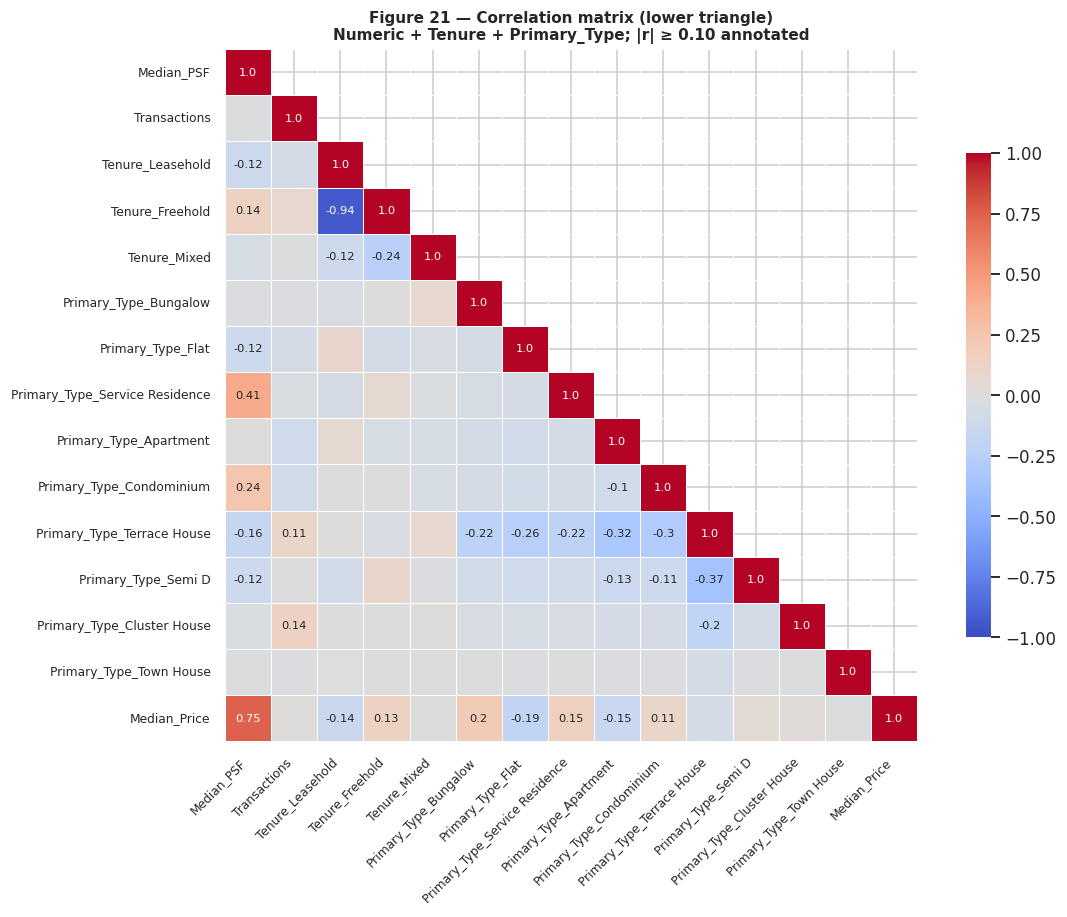

In [36]:
from sklearn.preprocessing import OneHotEncoder

CAT_HEATMAP = ["Tenure", "Primary_Type"]
NUM_HEATMAP = ["Median_PSF", "Transactions"]
ohe_heat = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_heat = pd.DataFrame(ohe_heat.fit_transform(df[CAT_HEATMAP]),
                            columns=ohe_heat.get_feature_names_out(CAT_HEATMAP))
encoded_heat = pd.concat([encoded_heat, df[NUM_HEATMAP].reset_index(drop=True)], axis=1)
encoded_heat["Median_Price"] = df["Median_Price"].values

corr_target = encoded_heat.corr()["Median_Price"].drop("Median_Price")
def _group(prefix):
    cols = [c for c in encoded_heat.columns if c.startswith(prefix)]
    return corr_target[cols].abs().sort_values(ascending=False).index.tolist()
ordered = NUM_HEATMAP + _group("Tenure_") + _group("Primary_Type_") + ["Median_Price"]
corr = encoded_heat[ordered].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
annot = corr.round(2).astype(str); annot[corr.abs() < .10] = ""
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, mask=mask, annot=annot, fmt="", annot_kws={"size": 7.5},
            cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.4,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Figure 21 — Correlation matrix (lower triangle)\n"
             "Numeric + Tenure + Primary_Type; |r| ≥ 0.10 annotated", fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); save_fig("fig21_correlation_matrix.png"); plt.show()

**Insight (Figure 21).**
Median_PSF has the strongest positive relationship with Median_Price, while Transactions shows almost no relationship with price.

Tenure and Primary_Type are temporarily one-hot encoded for this correlation analysis only and are not used directly for model training.
   
State and Area_Key are excluded because they contain many categories and would make the heatmap too crowded.

Correlation values below |r| = 0.10 are not labelled to improve readability, but their relationships can still be seen from the cell colours.
   


### Analysis 13 — Which final features associate most strongly with price?

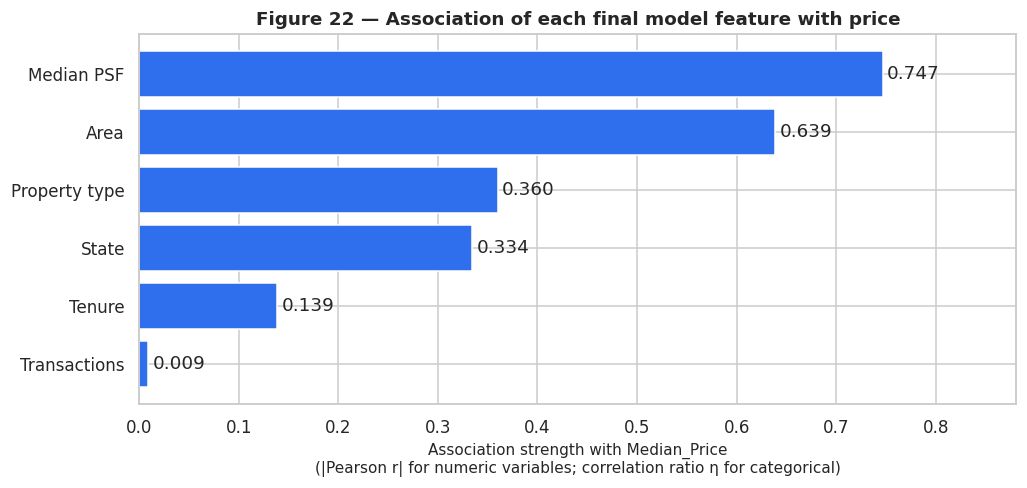

,Association
Median PSF,0.747
Area,0.639
Property type,0.360
State,0.334
Tenure,0.139
Transactions,0.009


In [37]:
import math

def correlation_ratio(categories, measurements):
    """Eta - association between a categorical variable and a continuous one.
    Handles any cardinality, so Area_Key can be assessed in a single number."""
    cat = pd.Categorical(categories)
    values = np.asarray(measurements, dtype=float)
    grand_mean = values.mean()
    numerator = 0.0
    for level in range(len(cat.categories)):
        group = values[cat.codes == level]
        if len(group):
            numerator += len(group) * (group.mean() - grand_mean) ** 2
    denominator = ((values - grand_mean) ** 2).sum()
    return math.sqrt(numerator / denominator) if denominator else 0.0

association = pd.Series({
    "Median PSF": abs(df["Median_PSF"].corr(df["Median_Price"])),
    "Transactions": abs(df["Transactions"].corr(df["Median_Price"])),
})
for col, label in [("State", "State"), ("Area_Key", "Area"),
                   ("Tenure", "Tenure"), ("Primary_Type", "Property type")]:
    association[label] = correlation_ratio(df[col], df["Median_Price"])
association = association.sort_values()

fig, ax = plt.subplots(figsize=(9.5, 4.6))
bars = ax.barh(association.index, association.values, color="#2F6FED")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlim(0, association.max() * 1.18)
ax.set_xlabel("Association strength with Median_Price\n"
              "(|Pearson r| for numeric variables; correlation ratio η for categorical)")
ax.set_title("Figure 22 — Association of each final model feature with price")
plt.tight_layout(); save_fig("fig22_feature_association.png"); plt.show()

display(association.sort_values(ascending=False).round(3).rename("Association").to_frame())

**Insight (Figure 22).** Median_PSF has the strongest association with Median_Price, followed by Area and Property Type. Area shows a stronger relationship with price than State, suggesting that more detailed location information is useful. Transactions has the weakest relationship with price. These results show association only and do not prove cause and effect.



## 3.5 Combined market effects

*Analyses 14–15: Analyses 14–15 examine how price patterns change when two categorical factors are considered together.*

examines two meaningful combinations of categorical features to see whether housing price patterns change when two factors are considered together. Only selected combinations are analysed to keep the results clear and avoid very small groups. More complex relationships between all features are handled later by the machine-learning models.

### Analysis 14 — Does the Landed/High-Rise price pattern depend on State?

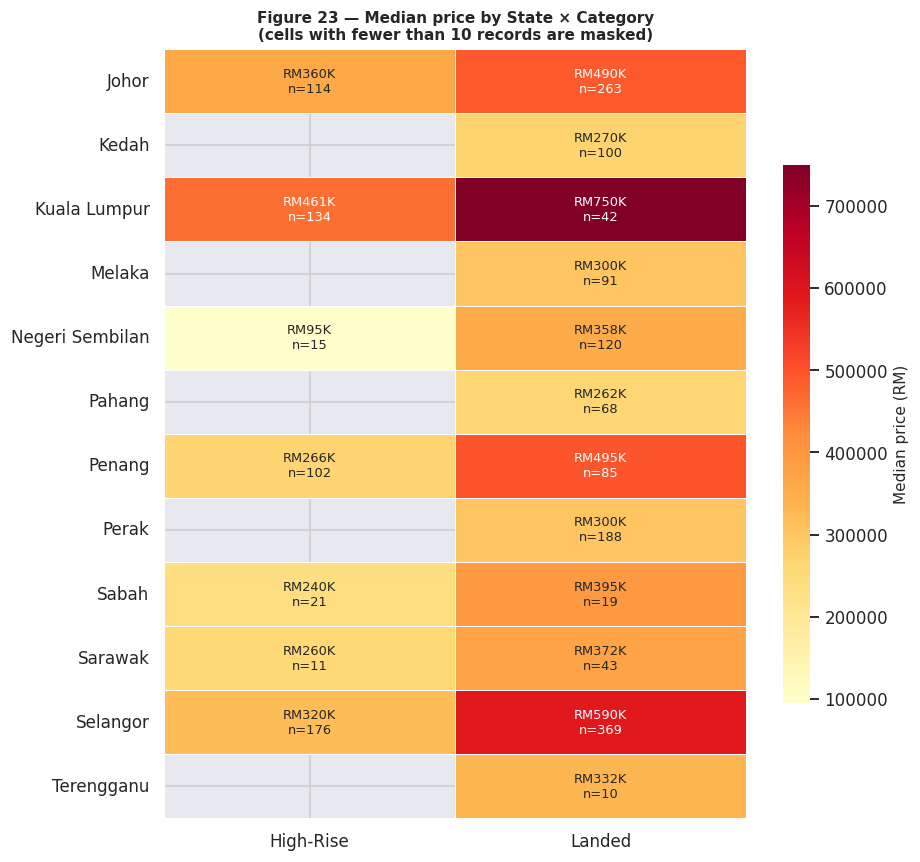

Masked cells (n < 10 or empty): 5 of 24


In [38]:
MIN_CELL_N = 10

price_matrix = df.pivot_table(index="State", columns="Category",
                              values="Median_Price", aggfunc="median")
count_matrix = df.pivot_table(index="State", columns="Category",
                              values="Median_Price", aggfunc="size")
thin = count_matrix.isna() | (count_matrix < MIN_CELL_N)
price_matrix = price_matrix.loc[~thin.all(axis=1)]
count_matrix = count_matrix.loc[price_matrix.index]
thin = thin.loc[price_matrix.index]

labels = price_matrix.copy().astype(object)
for r in price_matrix.index:
    for c in price_matrix.columns:
        n = count_matrix.loc[r, c]
        labels.loc[r, c] = ("—" if thin.loc[r, c]
                            else f"RM{price_matrix.loc[r, c]/1000:,.0f}K\nn={int(n)}")

fig, ax = plt.subplots(figsize=(8.5, 8))
sns.heatmap(price_matrix, mask=thin, annot=labels, fmt="", annot_kws={"size": 8.5},
            cmap="YlOrRd", linewidths=.6, linecolor="white",
            cbar_kws={"label": "Median price (RM)", "shrink": .7}, ax=ax)
ax.set_facecolor("#E7E9EE")
ax.set_title(f"Figure 23 — Median price by State × Category\n"
             f"(cells with fewer than {MIN_CELL_N} records are masked)", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); save_fig("fig23_state_category_heatmap.png"); plt.show()

print(f"Masked cells (n < {MIN_CELL_N} or empty): {int(thin.values.sum())} of {thin.size}")

**Insight (Figure 23).**  Landed properties generally have higher median prices than High-Rise properties across the states shown. However, the size of the price difference varies by state, showing that both location and property category are related to housing price. Grey cells represent combinations with fewer than 10 records and are not interpreted.

### Analysis 15 — Does tenure's price pattern depend on property type?

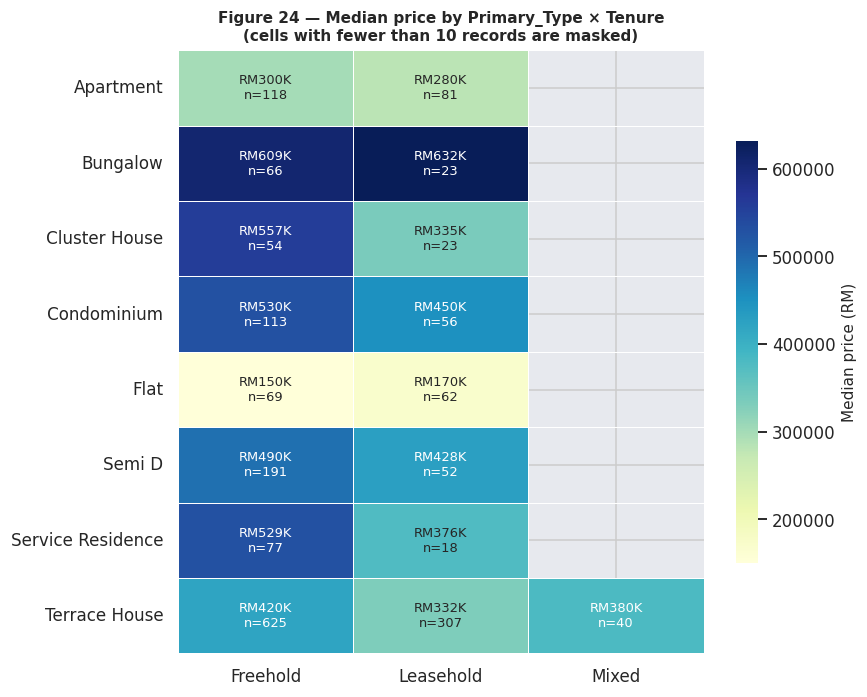

Masked cells (n < 10 or empty): 7 of 24


In [39]:
price_matrix2 = df.pivot_table(index="Primary_Type", columns="Tenure",
                               values="Median_Price", aggfunc="median")
count_matrix2 = df.pivot_table(index="Primary_Type", columns="Tenure",
                               values="Median_Price", aggfunc="size")
thin2 = count_matrix2.isna() | (count_matrix2 < MIN_CELL_N)
keep_rows = ~thin2.all(axis=1)
price_matrix2 = price_matrix2.loc[keep_rows]
count_matrix2 = count_matrix2.loc[keep_rows]
thin2 = thin2.loc[keep_rows]

labels2 = price_matrix2.copy().astype(object)
for r in price_matrix2.index:
    for c in price_matrix2.columns:
        n = count_matrix2.loc[r, c]
        labels2.loc[r, c] = ("—" if thin2.loc[r, c]
                             else f"RM{price_matrix2.loc[r, c]/1000:,.0f}K\nn={int(n)}")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(price_matrix2, mask=thin2, annot=labels2, fmt="", annot_kws={"size": 8.5},
            cmap="YlGnBu", linewidths=.6, linecolor="white",
            cbar_kws={"label": "Median price (RM)", "shrink": .7}, ax=ax)
ax.set_facecolor("#E7E9EE")
ax.set_title(f"Figure 24 — Median price by Primary_Type × Tenure\n"
             f"(cells with fewer than {MIN_CELL_N} records are masked)", fontsize=10)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); save_fig("fig24_type_tenure_heatmap.png"); plt.show()

print(f"Masked cells (n < {MIN_CELL_N} or empty): {int(thin2.values.sum())} of {thin2.size}")

**Insight (Figure 24).** Median Price differs across combinations of Property Type and Tenure. Freehold properties are generally more expensive than Leasehold properties, but the size of the difference varies by property type. Most Mixed-tenure groups have fewer than 10 records, so they are not interpreted.


Conclusion for Section 3.5. Figures 23 and 24 show that price patterns can differ when two features are considered together. This supports using machine-learning models that can capture more complex relationships between multiple features.

---
# PART 4 — MODELLING
Main purpose: **prepare, train and tune the models**.

## 4.1 Model choice and justification

| Role | Model | Simple reason for using it | Main weakness |
|---|---|---|---|
| Baseline | Decision Tree | Easy to understand and can learn non-linear rules | A full tree can memorise training data |
| Ensemble | Random Forest | Averages many trees to reduce overfitting | Larger and less easy to explain than one tree |
| Boosting | XGBoost | Builds trees step by step and corrects earlier errors | Needs careful parameter settings |
| Boosting | LightGBM | Fast gradient boosting and works well with many encoded features | Can overfit small or rare groups |



## 4.2 Split the data before tuning

The correct order is:

```text
Prepared Dataset
        ↓
Group train-test split by Area_Key
        ↓
Training set only: preprocessing + 4-fold GroupKFold
        ↓
Tune Random Forest, XGBoost and LightGBM; evaluate Decision Tree baseline
        ↓
Compare models using training-set Group CV results
        ↓
Select the final model
        ↓
Refit selected model using all training data
        ↓
Evaluate once on the untouched test set
```

Leakage controls used here:

1. `GroupShuffleSplit` is used before tuning.
2. One Area cannot appear in both training and test data.
3. Encoding and imputation are inside the pipeline, so every fold learns its own
   preprocessing from that fold's training rows only.
4. `GridSearchCV` receives `X_train` and `y_train` only.
5. Test metrics are calculated later in Part 5.

- Split the data
- No overlap between area

In [40]:
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, GridSearchCV, cross_validate, ParameterGrid
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,
    r2_score
)
from sklearn.inspection import permutation_importance
import joblib

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

TARGET = "Median_Price"
CAT_FEATURES = ["State", "Area_Key", "Tenure", "Primary_Type"]
NUM_FEATURES = ["Median_PSF", "Transactions"]
MODEL_FEATURES = CAT_FEATURES + NUM_FEATURES

X = df[MODEL_FEATURES].copy()
y = df[TARGET].copy()
groups = df["Area_Key"].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

area_overlap = set(groups_train) & set(groups_test)
assert len(area_overlap) == 0, "Area leakage found between training and test sets."
assert set(X_train.index).isdisjoint(set(X_test.index))

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Row share (%)": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100],
    "Areas": [groups_train.nunique(), groups_test.nunique()],
    "Median price (RM)": [y_train.median(), y_test.median()],
    "Maximum price (RM)": [y_train.max(), y_test.max()],
})

display(split_summary.round(2))
print(f"Area overlap between training and test: {len(area_overlap)}")
print("The test set will not be used during parameter tuning.")

,Dataset,Rows,Row share (%),Areas,Median price (RM),Maximum price (RM)
0,Training,1634,81.7,245,397041.5,11420500.0
1,Test,366,18.3,62,360000.0,3715000.0


Area overlap between training and test: 0
The test set will not be used during parameter tuning.


## 4.3 Preprocessing pipeline

- Convert category column into number using one-hot encoding
- If area appear less than 5 , then group into infrequent category
- No standardization as we choose tree-based model

In [41]:
RARE_AREA_MIN_FREQUENCY = 5

def make_preprocessor(features: list[str]):
    categorical = [c for c in CAT_FEATURES if c in features]
    numerical = [c for c in NUM_FEATURES if c in features]

    try:
        encoder = OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=RARE_AREA_MIN_FREQUENCY,
            sparse_output=True,
        )
    except TypeError:  # compatibility with older scikit-learn versions
        encoder = OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=RARE_AREA_MIN_FREQUENCY,
            sparse=True,
        )

    transformers = []
    if categorical:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", encoder),
            ]),
            categorical,
        ))
    if numerical:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numerical,
        ))

    return ColumnTransformer(transformers, remainder="drop")


def make_pipeline(model, features=MODEL_FEATURES):
    return Pipeline([
        ("preprocess", make_preprocessor(features)),
        ("model", model),
    ])

GROUP_CV = GroupKFold(n_splits=4)
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

print(f"Fixed rare-Area minimum frequency: {RARE_AREA_MIN_FREQUENCY}")
print("Cross-validation: 4-fold GroupKFold on training Areas only")

Fixed rare-Area minimum frequency: 5
Cross-validation: 4-fold GroupKFold on training Areas only


## 4.4 Baseline model

Make as a baseline to compare with other model wherther tuning is useful

In [42]:
BASELINE_MODEL = DecisionTreeRegressor(random_state=RANDOM_STATE)

best_pipelines = {
    "Decision Tree (Baseline)": make_pipeline(BASELINE_MODEL)
}

print("Baseline created: untuned Decision Tree")

Baseline created: untuned Decision Tree


## 4.5 Tune the three ensemble models

Hyperparameter tuning: test the setting of each combination

K-Fold : Split each training data into different fold

GridSearch CV: find the avg RMSE of each hyperparameter tuning

In [43]:
SEARCH_SPACES = OrderedDict({
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        {
            "model__n_estimators": [80, 120],
            "model__min_samples_leaf": [1, 2],
            "model__max_depth": [None],
            "model__max_features": [0.8],
        },
    ),
    "XGBoost": (
        XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            objective="reg:squarederror",
            tree_method="hist",
        ),
        {
            "model__n_estimators": [120, 180],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.05],
            "model__subsample": [0.90],
            "model__colsample_bytree": [0.90],
        },
    ),
    "LightGBM": (
        LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=-1,
        ),
        {
            "model__n_estimators": [120, 180],
            "model__num_leaves": [15, 31],
            "model__learning_rate": [0.05],
            "model__min_child_samples": [20],
        },
    ),
})

grid_summary = pd.DataFrame([
    {
        "Model": name,
        "Parameter combinations": len(list(ParameterGrid(grid))),
        "Parameters that change": ", ".join(
            key.replace("model__", "")
            for key, values in grid.items() if len(values) > 1
        ),
    }
    for name, (_, grid) in SEARCH_SPACES.items()
])
display(grid_summary)

search_summaries = []
for name, (model, grid) in SEARCH_SPACES.items():
    print(f"Tuning {name}...")
    start = time.time()

    search = GridSearchCV(
        estimator=make_pipeline(model),
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=GROUP_CV,
        n_jobs=1,
        refit=True,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train, groups=groups_train)

    best_pipelines[name] = search.best_estimator_
    search_summaries.append({
        "Model": name,
        "Combinations tested": len(list(ParameterGrid(grid))),
        "Best Group CV RMSE (RM)": -search.best_score_,
        "Best parameters": json.dumps(search.best_params_, sort_keys=True),
        "Search time (s)": time.time() - start,
    })

    print(f"  Best RMSE: RM {-search.best_score_:,.0f}")
    print(f"  Best settings: {search.best_params_}")

tuning_results = pd.DataFrame(search_summaries)
tuning_results.to_csv("tuning_results.csv", index=False)
display(tuning_results.round(2))

print("Tuning is complete. The untouched test set has not been used.")

,Model,Parameter combinations,Parameters that change
0,Random Forest,4,"n_estimators, min_samples_leaf"
1,XGBoost,4,"n_estimators, max_depth"
2,LightGBM,4,"n_estimators, num_leaves"


Tuning Random Forest...
  Best RMSE: RM 279,261
  Best settings: {'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__n_estimators': 120}
Tuning XGBoost...
  Best RMSE: RM 279,064
  Best settings: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 180, 'model__subsample': 0.9}
Tuning LightGBM...
  Best RMSE: RM 296,706
  Best settings: {'model__learning_rate': 0.05, 'model__min_child_samples': 20, 'model__n_estimators': 120, 'model__num_leaves': 15}


,Model,Combinations tested,Best Group CV RMSE (RM),Best parameters,Search time (s)
0,Random Forest,4,279261.07,"{""model__max_depth"": null, ""model__max_feature...",18.53
1,XGBoost,4,279063.78,"{""model__colsample_bytree"": 0.9, ""model__learn...",1.98
2,LightGBM,4,296705.89,"{""model__learning_rate"": 0.05, ""model__min_chi...",1.36


Tuning is complete. The untouched test set has not been used.


---
# PART 5 — MODEL EVALUATION AND SELECTION

Part 5 compares the trained models, explains the errors and selects the final
model.

## 5.1 Why the RMSE value looks high

The RMSE value may look high because the target variable, `Median_Price`, is measured in Ringgit. Since house prices are large values, the RMSE will also appear large in Ringgit.

RMSE also gives a stronger penalty to large prediction errors because errors are squared before averaging. In this dataset, some properties have very high prices, so a few large errors on expensive properties can increase the RMSE noticeably.

Therefore, RMSE should not be interpreted alone. It should be compared together with MAE, MAPE and R² to understand the model performance more fairly.

## 5.2 Compare the four models

The Decision Tree is the baseline model. Random Forest, XGBoost and LightGBM are the advanced ensemble models.

The final model is selected without looking at test performance:

1. compare mean Group CV RMSE on the training set;
2. treat models within 1% of the best mean as a practical tie;
3. within that tie, choose the model with the lower fold-to-fold RMSE variation;
4. use the test set once to report final performance, not to change the choice.

In [44]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def training_cv_result(name, pipeline):
    """Calculate training-only cross-validation results."""
    cv_output = cross_validate(
        pipeline,
        X_train,
        y_train,
        groups=groups_train,
        cv=GROUP_CV,
        scoring=SCORING,
        n_jobs=1,
        error_score="raise",
    )

    for fold_number, (fold_rmse, fold_mae, fold_r2) in enumerate(zip(
        -cv_output["test_rmse"],
        -cv_output["test_mae"],
        cv_output["test_r2"],
    ), start=1):
        fold_score_rows.append({
            "Model": name,
            "Fold": fold_number,
            "RMSE (RM)": fold_rmse,
            "MAE (RM)": fold_mae,
            "R²": fold_r2,
        })

    return {
        "Model": name,
        "Group_CV_RMSE_mean": -cv_output["test_rmse"].mean(),
        "Group_CV_RMSE_std": cv_output["test_rmse"].std(),
        "Group_CV_MAE_mean": -cv_output["test_mae"].mean(),
        "Group_CV_R2_mean": cv_output["test_r2"].mean(),
    }


# Phase A — model selection uses training GroupKFold only.
fold_score_rows = []
cv_rows = []

for model_name, pipeline in best_pipelines.items():
    cv_rows.append(training_cv_result(model_name, pipeline))

cv_results_table = pd.DataFrame(cv_rows)

best_mean = cv_results_table["Group_CV_RMSE_mean"].min()
practical_tie_limit = best_mean * 1.01

practical_ties = cv_results_table[
    cv_results_table["Group_CV_RMSE_mean"] <= practical_tie_limit
].copy()

selected_cv_row = practical_ties.sort_values(
    ["Group_CV_RMSE_std", "Group_CV_RMSE_mean"]
).iloc[0]

BEST_MODEL_NAME = selected_cv_row["Model"]

cv_results_table["Within_1pct_of_best_CV"] = (
    cv_results_table["Group_CV_RMSE_mean"] <= practical_tie_limit
)

cv_results_table["Selected_Model"] = (
    cv_results_table["Model"] == BEST_MODEL_NAME
)

cv_results_table["Group_CV_Rank"] = (
    cv_results_table["Group_CV_RMSE_mean"].rank(method="min")
)

print(f"Selected from training CV only: {BEST_MODEL_NAME}")
print(f"Practical tie rule: within 1% of RM {best_mean:,.0f} Group CV RMSE")
print("The final test set has not been evaluated yet.")


# Phase B — after the choice is locked, fit on all training rows and report test results.
evaluation_pipelines = dict(best_pipelines)

final_rows = []
test_prediction_frame = pd.DataFrame({"Actual": y_test.values}, index=y_test.index)

for model_name, pipeline in evaluation_pipelines.items():
    pipeline.fit(X_train, y_train)

    train_prediction = pipeline.predict(X_train)
    test_prediction = pipeline.predict(X_test)

    test_prediction_frame[model_name] = test_prediction

    final_rows.append({
        "Model": model_name,
        "RMSE_train": rmse(y_train, train_prediction),
        "RMSE_test": rmse(y_test, test_prediction),
        "MAE_test": mean_absolute_error(y_test, test_prediction),
        "MAPE_test_pct": mean_absolute_percentage_error(y_test, test_prediction) * 100,
        "R2_test": r2_score(y_test, test_prediction),
        "Gap_RMSE": rmse(y_test, test_prediction) - rmse(y_train, train_prediction),
    })

    filename = model_name.split(" (")[0].lower().replace(" ", "_") + ".pkl"
    joblib.dump(pipeline, MODELS_DIR / filename)

final_metrics = pd.DataFrame(final_rows)

results = cv_results_table.merge(final_metrics, on="Model", how="left")

results["Test_Rank"] = results["RMSE_test"].rank(method="min")

results = results.sort_values(
    ["Group_CV_RMSE_mean", "Group_CV_RMSE_std"]
).reset_index(drop=True)

fold_scores = pd.DataFrame(fold_score_rows)

results.to_csv("model_results.csv", index=False)
fold_scores.to_csv("fold_scores.csv", index=False)
test_prediction_frame.to_csv("test_predictions.csv", index=True)

display(results.round(3))

print(f"Selected model: {BEST_MODEL_NAME}")
print("Test metrics were calculated only after the training-CV choice was locked.")

Selected from training CV only: Random Forest
Practical tie rule: within 1% of RM 279,064 Group CV RMSE
The final test set has not been evaluated yet.


,Model,Group_CV_RMSE_mean,Group_CV_RMSE_std,Group_CV_MAE_mean,Group_CV_R2_mean,Within_1pct_of_best_CV,Selected_Model,Group_CV_Rank,RMSE_train,RMSE_test,MAE_test,MAPE_test_pct,R2_test,Gap_RMSE,Test_Rank
0,XGBoost,279063.779,196101.982,121572.436,0.642,True,False,1.0,112005.280,158972.305,83821.345,21.007,0.763,46967.025,2.0
1,Random Forest,279261.066,194229.289,123987.736,0.639,True,True,2.0,229124.762,131393.112,85495.878,21.915,0.838,-97731.650,1.0
2,LightGBM,296705.888,199776.311,130307.485,0.585,False,False,3.0,287981.890,176629.690,92355.256,21.374,0.707,-111352.200,3.0
3,Decision Tree (Baseline),358155.055,180728.301,164442.409,0.344,False,False,4.0,437.320,248439.102,120114.798,26.119,0.421,248001.782,4.0


Selected model: Random Forest
Test metrics were calculated only after the training-CV choice was locked.


In [45]:
comparison_columns = [
    "Model",
    "Group_CV_RMSE_mean",
    "Group_CV_RMSE_std",
    "Group_CV_MAE_mean",
    "Group_CV_R2_mean",
    "RMSE_train",
    "RMSE_test",
    "MAE_test",
    "MAPE_test_pct",
    "R2_test",
    "Selected_Model",
]

missing_columns = [col for col in comparison_columns if col not in results.columns]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    model_comparison_table = results[comparison_columns].copy()

    model_comparison_table = model_comparison_table.round({
        "Group_CV_RMSE_mean": 3,
        "Group_CV_RMSE_std": 3,
        "Group_CV_MAE_mean": 3,
        "Group_CV_R2_mean": 3,
        "RMSE_train": 3,
        "RMSE_test": 3,
        "MAE_test": 3,
        "MAPE_test_pct": 3,
        "R2_test": 3,
    })

    # Make row number start from 1 instead of 0
    model_comparison_table.index = range(1, len(model_comparison_table) + 1)

    display(model_comparison_table)

    model_comparison_table.to_csv("model_comparison_table.csv", index=False)
    print("Saved: model_comparison_table.csv")

,Model,Group_CV_RMSE_mean,Group_CV_RMSE_std,Group_CV_MAE_mean,Group_CV_R2_mean,RMSE_train,RMSE_test,MAE_test,MAPE_test_pct,R2_test,Selected_Model
1,XGBoost,279063.779,196101.982,121572.436,0.642,112005.280,158972.305,83821.345,21.007,0.763,False
2,Random Forest,279261.066,194229.289,123987.736,0.639,229124.762,131393.112,85495.878,21.915,0.838,True
3,LightGBM,296705.888,199776.311,130307.485,0.585,287981.890,176629.690,92355.256,21.374,0.707,False
4,Decision Tree (Baseline),358155.055,180728.301,164442.409,0.344,437.320,248439.102,120114.798,26.119,0.421,False


Saved: model_comparison_table.csv


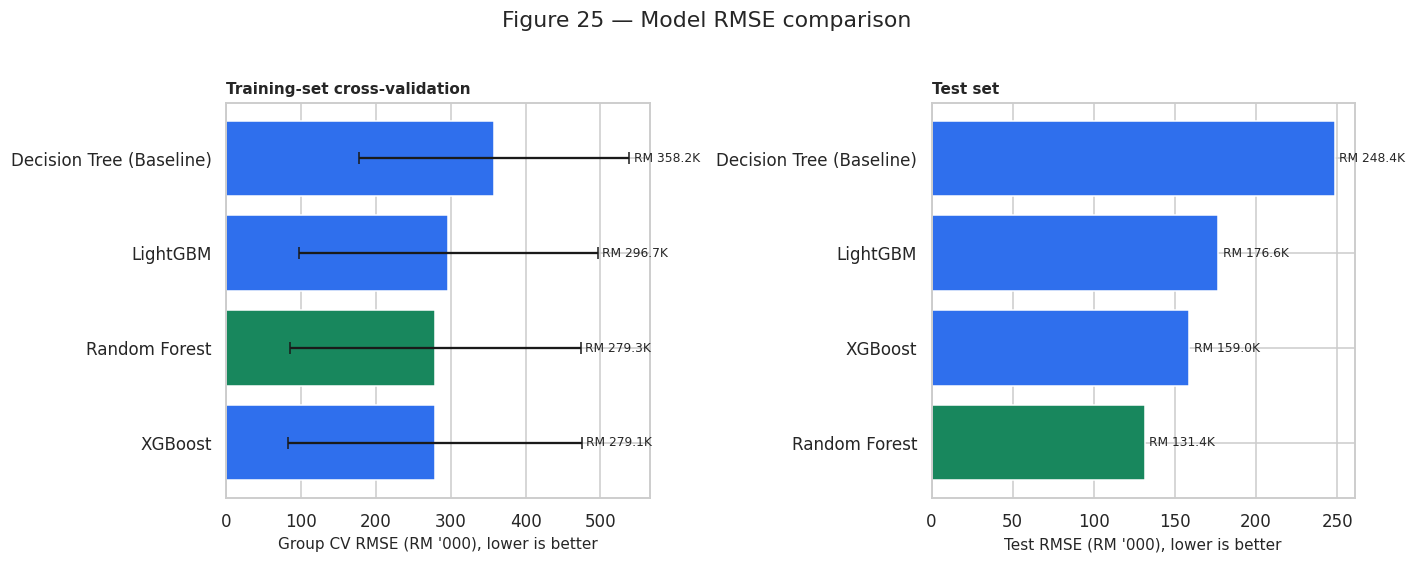

**Figure 25 insight.** Random Forest was selected using training-set Group CV. Its Group CV RMSE is **RM 279,261**, which is about **22.0% lower** than the Decision Tree baseline. The test set is reported only as the final unseen-data check.

In [46]:
plot_results = results.copy()
plot_results["Display model"] = plot_results["Model"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: training-set Group CV RMSE
ordered_cv = plot_results.sort_values("Group_CV_RMSE_mean")

cv_colours = [
    "#18875D" if selected else "#2F6FED"
    for selected in ordered_cv["Selected_Model"]
]

cv_bars = axes[0].barh(
    ordered_cv["Display model"],
    ordered_cv["Group_CV_RMSE_mean"] / 1000,
    xerr=ordered_cv["Group_CV_RMSE_std"] / 1000,
    color=cv_colours,
    capsize=4,
)

axes[0].bar_label(
    cv_bars,
    labels=[f"RM {value / 1000:,.1f}K" for value in ordered_cv["Group_CV_RMSE_mean"]],
    padding=3,
    fontsize=8,
)

axes[0].set_xlabel("Group CV RMSE (RM '000), lower is better")
axes[0].set_title("Training-set cross-validation", loc="left", fontsize=10)

# Right panel: test RMSE
ordered_test = plot_results.sort_values("RMSE_test")

test_colours = [
    "#18875D" if selected else "#2F6FED"
    for selected in ordered_test["Selected_Model"]
]

test_bars = axes[1].barh(
    ordered_test["Display model"],
    ordered_test["RMSE_test"] / 1000,
    color=test_colours,
)

axes[1].bar_label(
    test_bars,
    labels=[f"RM {value / 1000:,.1f}K" for value in ordered_test["RMSE_test"]],
    padding=3,
    fontsize=8,
)

axes[1].set_xlabel("Test RMSE (RM '000), lower is better")
axes[1].set_title("Test set", loc="left", fontsize=10)

plt.suptitle("Figure 25 — Model RMSE comparison", y=1.02)
plt.tight_layout()
save_fig("fig25_model_rmse_comparison.png")
plt.show()

selected_row = results.loc[results["Selected_Model"]].iloc[0]
baseline_row = results.loc[results["Model"].eq("Decision Tree (Baseline)")].iloc[0]

cv_improvement = (
    baseline_row["Group_CV_RMSE_mean"] - selected_row["Group_CV_RMSE_mean"]
) / baseline_row["Group_CV_RMSE_mean"] * 100

display(Markdown(
    f"**Figure 25 insight.** {BEST_MODEL_NAME} was selected using training-set "
    f"Group CV. Its Group CV RMSE is **RM {selected_row['Group_CV_RMSE_mean']:,.0f}**, "
    f"which is about **{cv_improvement:.1f}% lower** than the Decision Tree baseline. "
    "The test set is reported only as the final unseen-data check."
))

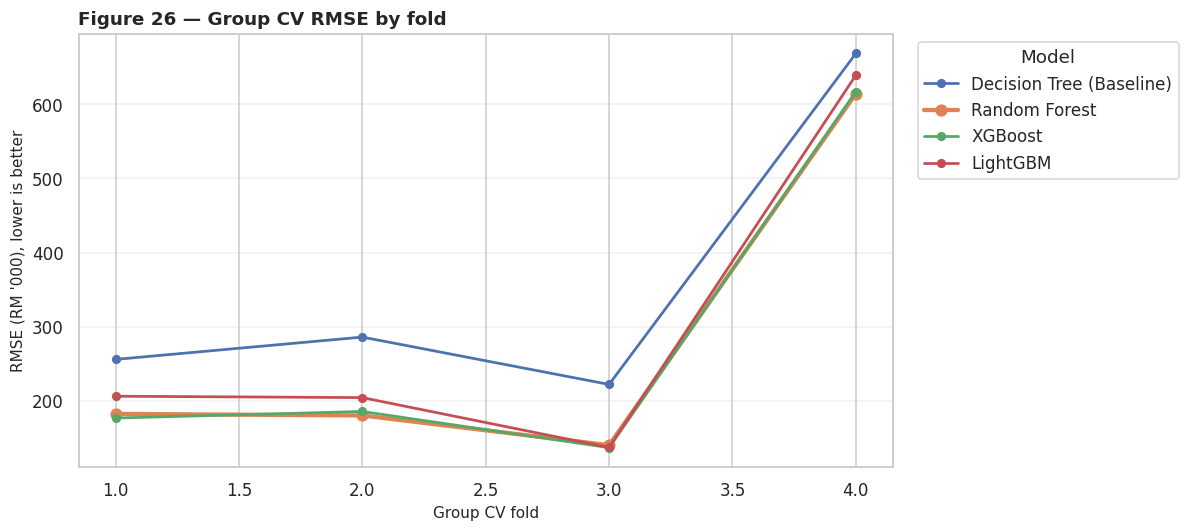

**Figure 26 insight.** Random Forest was compared across the Group CV folds. The fold RMSE ranges from **RM 140,106** to **RM 614,413**, showing that some validation folds are harder than others because they contain different Area groups.

In [47]:
fig, ax = plt.subplots(figsize=(11, 5))

for model_name in fold_scores["Model"].unique():
    model_scores = fold_scores[fold_scores["Model"] == model_name]

    linewidth = 2.8 if model_name == BEST_MODEL_NAME else 1.8
    marker_size = 7 if model_name == BEST_MODEL_NAME else 5

    ax.plot(
        model_scores["Fold"],
        model_scores["RMSE (RM)"] / 1000,
        marker="o",
        linewidth=linewidth,
        markersize=marker_size,
        label=model_name,
    )

ax.set_xlabel("Group CV fold")
ax.set_ylabel("RMSE (RM '000), lower is better")
ax.set_title("Figure 26 — Group CV RMSE by fold", loc="left")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("fig26_group_cv_fold_rmse.png")
plt.show()

selected_fold_scores = fold_scores[fold_scores["Model"] == BEST_MODEL_NAME]

display(Markdown(
    f"**Figure 26 insight.** {BEST_MODEL_NAME} was compared across the Group CV folds. "
    f"The fold RMSE ranges from **RM {selected_fold_scores['RMSE (RM)'].min():,.0f}** "
    f"to **RM {selected_fold_scores['RMSE (RM)'].max():,.0f}**, showing that some "
    "validation folds are harder than others because they contain different Area groups."
))

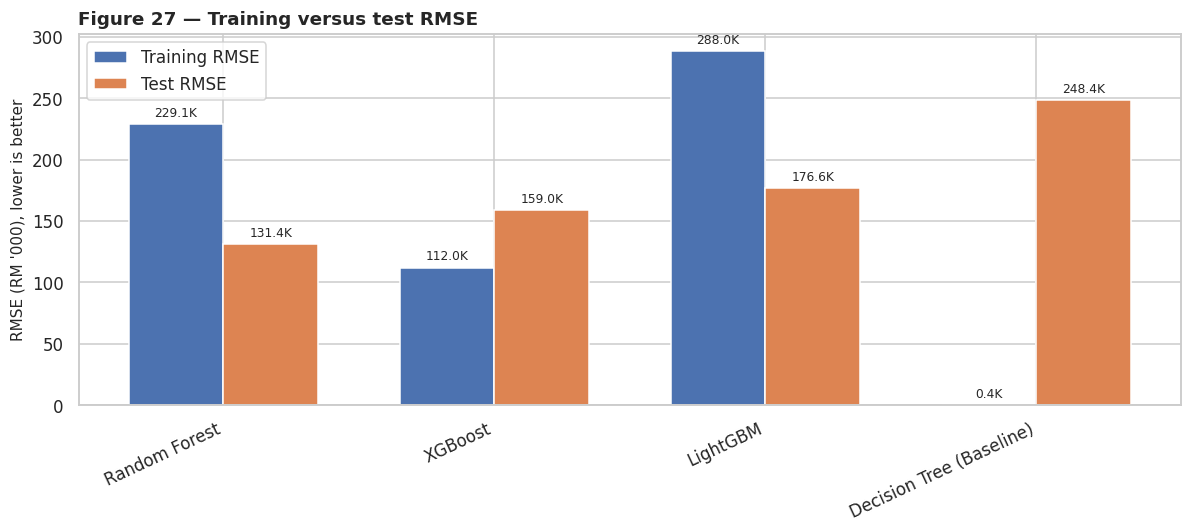

**Figure 27 insight.** The Decision Tree baseline has very low training RMSE (**RM 437**) but much higher test RMSE (**RM 248,439**), showing overfitting. The selected Random Forest model has a more reliable test result and is therefore more suitable for final prediction.

In [48]:
plot_results = results.copy().sort_values("RMSE_test")

x = np.arange(len(plot_results))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

train_bars = ax.bar(
    x - width / 2,
    plot_results["RMSE_train"] / 1000,
    width,
    label="Training RMSE",
)

test_bars = ax.bar(
    x + width / 2,
    plot_results["RMSE_test"] / 1000,
    width,
    label="Test RMSE",
)

ax.set_xticks(x)
ax.set_xticklabels(plot_results["Model"], rotation=25, ha="right")
ax.set_ylabel("RMSE (RM '000), lower is better")
ax.set_title("Figure 27 — Training versus test RMSE", loc="left")
ax.legend()

ax.bar_label(
    train_bars,
    labels=[f"{value/1000:,.1f}K" for value in plot_results["RMSE_train"]],
    padding=3,
    fontsize=8,
)

ax.bar_label(
    test_bars,
    labels=[f"{value/1000:,.1f}K" for value in plot_results["RMSE_test"]],
    padding=3,
    fontsize=8,
)

plt.tight_layout()
save_fig("fig27_train_test_overfitting.png")
plt.show()

baseline_row = results.loc[results["Model"].eq("Decision Tree (Baseline)")].iloc[0]
selected_row = results.loc[results["Selected_Model"]].iloc[0]

display(Markdown(
    f"**Figure 27 insight.** The Decision Tree baseline has very low training RMSE "
    f"(**RM {baseline_row['RMSE_train']:,.0f}**) but much higher test RMSE "
    f"(**RM {baseline_row['RMSE_test']:,.0f}**), showing overfitting. "
    f"The selected {BEST_MODEL_NAME} model has a more reliable test result and is "
    "therefore more suitable for final prediction."
))

## 5.3 `Median_PSF` dependency and leakage check




,Feature set,Validation RMSE (RM),Validation MAE (RM),Validation R²,Selected model,RMSE difference vs With Median_PSF (%)
0,Without Median_PSF,598984.45,208566.59,0.08,Random Forest,23.75
1,With Median_PSF,484014.42,125062.12,0.40,Random Forest,0.00


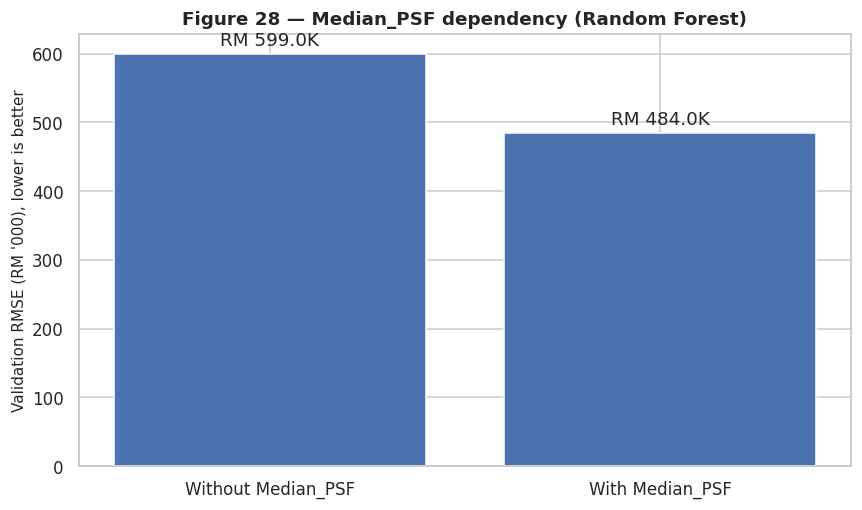

**Figure 28 insight.** Removing `Median_PSF` increases validation RMSE by **23.8%** for Random Forest.

In [49]:
from sklearn.base import clone

diagnostic_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE + 1,
)

diagnostic_train_idx, diagnostic_validation_idx = next(
    diagnostic_splitter.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)

X_diagnostic_train = X_train.iloc[diagnostic_train_idx].copy()
X_diagnostic_validation = X_train.iloc[diagnostic_validation_idx].copy()
y_diagnostic_train = y_train.iloc[diagnostic_train_idx].copy()
y_diagnostic_validation = y_train.iloc[diagnostic_validation_idx].copy()
diagnostic_groups_train = groups_train.iloc[diagnostic_train_idx].copy()
diagnostic_groups_validation = groups_train.iloc[diagnostic_validation_idx].copy()

diagnostic_area_overlap = (
    set(diagnostic_groups_train)
    & set(diagnostic_groups_validation)
)
assert len(diagnostic_area_overlap) == 0, "Area overlap found in the diagnostic split."


def diagnostic_feature_result(label, features):
    model_template = best_pipelines[BEST_MODEL_NAME].named_steps["model"]
    diagnostic_pipeline = make_pipeline(
        clone(model_template),
        features=features,
    )
    diagnostic_pipeline.fit(
        X_diagnostic_train[features],
        y_diagnostic_train,
    )
    prediction = diagnostic_pipeline.predict(
        X_diagnostic_validation[features]
    )
    return {
        "Feature set": label,
        "Validation RMSE (RM)": rmse(y_diagnostic_validation, prediction),
        "Validation MAE (RM)": mean_absolute_error(
            y_diagnostic_validation,
            prediction,
        ),
        "Validation R²": r2_score(y_diagnostic_validation, prediction),
    }


FEATURES_WITHOUT_PSF = [
    feature
    for feature in MODEL_FEATURES
    if feature != "Median_PSF"
]
FEATURES_WITH_PSF = MODEL_FEATURES.copy()

psf_check = pd.DataFrame([
    diagnostic_feature_result(
        "Without Median_PSF",
        FEATURES_WITHOUT_PSF,
    ),
    diagnostic_feature_result(
        "With Median_PSF",
        FEATURES_WITH_PSF,
    ),
])
psf_check["Selected model"] = BEST_MODEL_NAME

without_psf_rmse = psf_check.loc[
    psf_check["Feature set"] == "Without Median_PSF",
    "Validation RMSE (RM)",
].iloc[0]
with_psf_rmse = psf_check.loc[
    psf_check["Feature set"] == "With Median_PSF",
    "Validation RMSE (RM)",
].iloc[0]
psf_increase_pct = (
    (without_psf_rmse - with_psf_rmse)
    / with_psf_rmse
    * 100
)
psf_check["RMSE difference vs With Median_PSF (%)"] = [
    psf_increase_pct,
    0.0,
]
psf_check.to_csv("median_psf_ablation_results.csv", index=False)
display(psf_check.round(2))

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(
    psf_check["Feature set"],
    psf_check["Validation RMSE (RM)"] / 1000,
)
ax.bar_label(
    bars,
    labels=[
        f"RM {value / 1000:,.1f}K"
        for value in psf_check["Validation RMSE (RM)"]
    ],
    padding=3,
)
ax.set_ylabel("Validation RMSE (RM '000), lower is better")
ax.set_title(f"Figure 28 — Median_PSF dependency ({BEST_MODEL_NAME})")
plt.tight_layout()
save_fig("fig28_median_psf_dependency.png")
plt.show()

effect_word = "increases" if psf_increase_pct >= 0 else "decreases"
display(Markdown(
    f"**Figure 28 insight.** Removing `Median_PSF` {effect_word} "
    f"validation RMSE by **{abs(psf_increase_pct):.1f}%** for "
    f"{BEST_MODEL_NAME}."
))


## 5.4 Prediction diagnostics

The selected model is checked using predicted-versus-actual values and residuals.
A residual is `actual price − predicted price`.


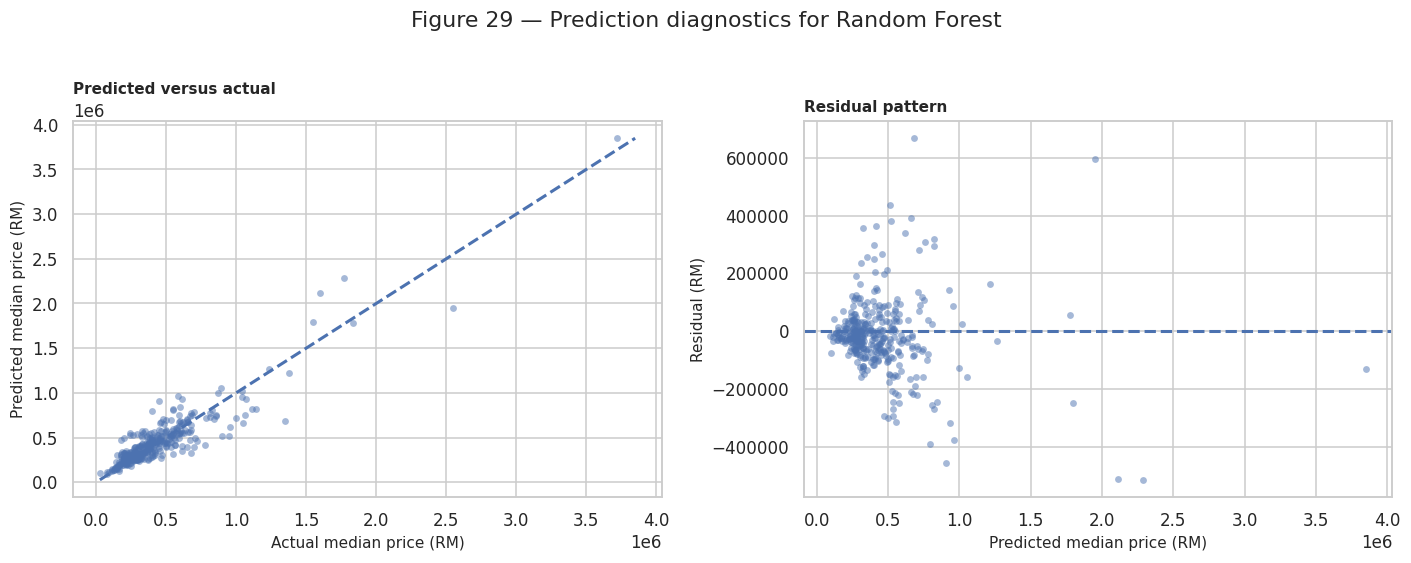

**Figure 29 insight.** The median absolute residual is about **RM 33,289** in the lower predicted-price half and **RM 82,387** in the upper half. This helps show whether errors become larger for more expensive properties.

In [50]:
selected_filename = (
    BEST_MODEL_NAME.split(" (")[0].lower().replace(" ", "_") + ".pkl"
)
best_pipeline = joblib.load(MODELS_DIR / selected_filename)
best_test_prediction = best_pipeline.predict(X_test)
residuals = y_test - best_test_prediction

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, best_test_prediction, s=20, alpha=0.5, linewidths=0)
limits = [
    min(y_test.min(), best_test_prediction.min()),
    max(y_test.max(), best_test_prediction.max()),
]
axes[0].plot(limits, limits, "--", linewidth=2)
axes[0].set_xlabel("Actual median price (RM)")
axes[0].set_ylabel("Predicted median price (RM)")
axes[0].set_title("Predicted versus actual", loc="left", fontsize=10)

axes[1].scatter(best_test_prediction, residuals, s=20, alpha=0.5, linewidths=0)
axes[1].axhline(0, linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted median price (RM)")
axes[1].set_ylabel("Residual (RM)")
axes[1].set_title("Residual pattern", loc="left", fontsize=10)

plt.suptitle(f"Figure 29 — Prediction diagnostics for {BEST_MODEL_NAME}", y=1.02)
plt.tight_layout()
save_fig("fig29_prediction_diagnostics.png")
plt.show()

lower_half = np.abs(residuals[best_test_prediction <= np.median(best_test_prediction)]).median()
upper_half = np.abs(residuals[best_test_prediction > np.median(best_test_prediction)]).median()
display(Markdown(
    f"**Figure 29 insight.** The median absolute residual is about "
    f"**RM {lower_half:,.0f}** in the lower predicted-price half and "
    f"**RM {upper_half:,.0f}** in the upper half. This helps show whether errors "
    "become larger for more expensive properties."
))

## 5.5 Feature importance

Permutation importance is the main interpretation because it measures how much
test R² decreases when one original input is shuffled. Native importance is
shown only as supporting evidence.


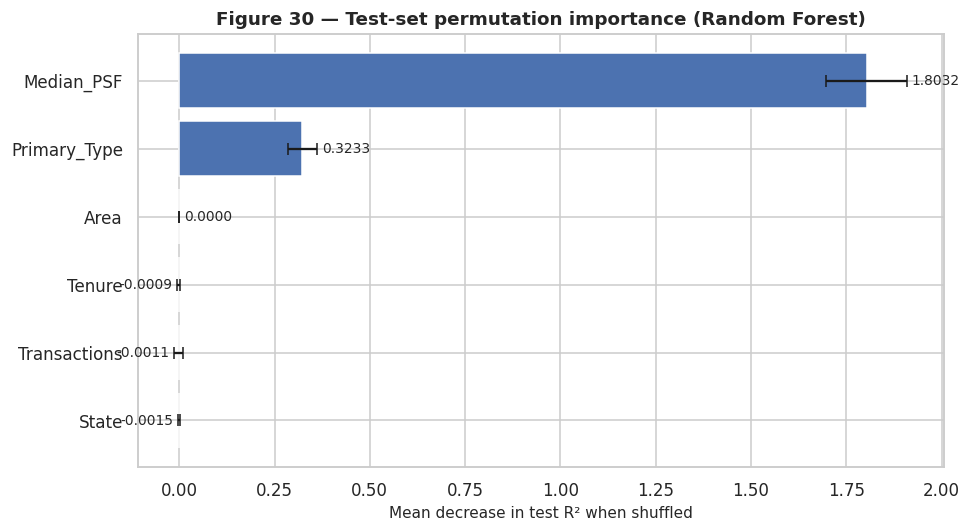

,Feature,Mean drop in R²,Standard deviation
4,Median_PSF,1.8032,0.1056
3,Primary_Type,0.3233,0.0391
1,Area,0.0000,0.0000
2,Tenure,-0.0009,0.0037
5,Transactions,-0.0011,0.0121
0,State,-0.0015,0.0026


**Figure 30 insight.** `Median_PSF` causes the largest drop in test R² when shuffled.

In [51]:
permutation_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=1,
)

permutation_table = pd.DataFrame({
    "Feature": [
        "Area" if column == "Area_Key" else column
        for column in X_test.columns
    ],
    "Mean drop in R²": permutation_result.importances_mean,
    "Standard deviation": permutation_result.importances_std,
}).sort_values("Mean drop in R²")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    permutation_table["Feature"],
    permutation_table["Mean drop in R²"],
    xerr=permutation_table["Standard deviation"],
    capsize=4,
)
ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in permutation_table["Mean drop in R²"]
    ],
    padding=3,
    fontsize=9,
)
ax.set_xlabel("Mean decrease in test R² when shuffled")
ax.set_title(f"Figure 30 — Test-set permutation importance ({BEST_MODEL_NAME})")
plt.tight_layout()
save_fig("fig30_permutation_importance.png")
plt.show()
display(
    permutation_table
    .sort_values("Mean drop in R²", ascending=False)
    .round(4)
)

most_important_feature = permutation_table.sort_values(
    "Mean drop in R²",
    ascending=False,
).iloc[0]["Feature"]
display(Markdown(
    f"**Figure 30 insight.** `{most_important_feature}` causes the "
    "largest drop in test R² when shuffled."
))


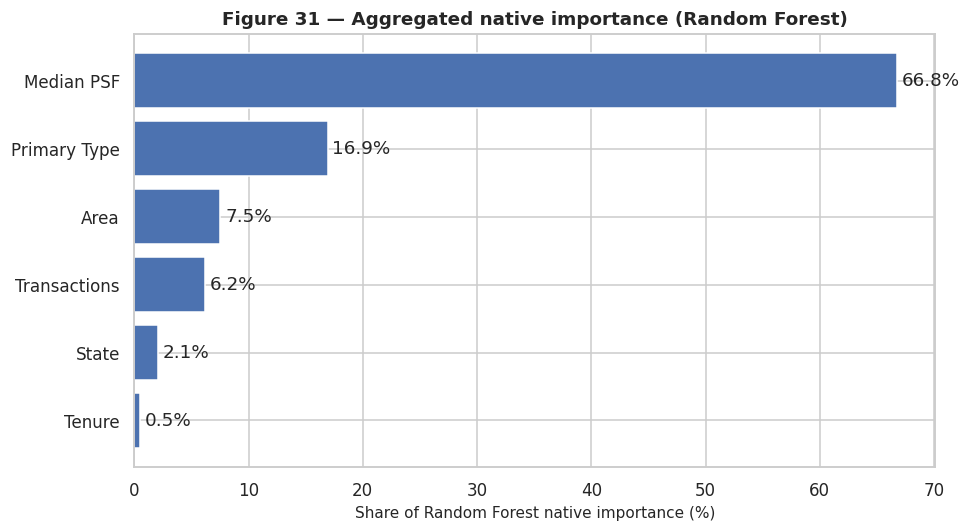

,Raw native importance,Share (%)
Median PSF,0.6677,66.7729
Primary Type,0.1691,16.9120
Area,0.0754,7.5356
Transactions,0.0621,6.2133
State,0.0210,2.0985
Tenure,0.0047,0.4678


Importance type: impurity-based and averaged across trees


**Figure 31 insight.** `Median PSF` has the largest native importance share at **66.8%**.

In [52]:
model_object = best_pipeline.named_steps["model"]
preprocessor_object = best_pipeline.named_steps["preprocess"]

IMPORTANCE_MEANING = {
    "Decision Tree (Baseline)": "impurity-based",
    "Random Forest": "impurity-based and averaged across trees",
    "XGBoost": "gain-based",
    "LightGBM": "model-native split/gain based",
}
importance_kind = IMPORTANCE_MEANING.get(BEST_MODEL_NAME, "model-native")

if hasattr(model_object, "feature_importances_"):
    encoded_names = preprocessor_object.get_feature_names_out()
    raw_importance = pd.Series(
        model_object.feature_importances_,
        index=encoded_names,
    )

    def original_feature_group(encoded_name: str) -> str:
        name = encoded_name.split("__", 1)[-1]
        if name.startswith("State_"):
            return "State"
        if name.startswith("Area_Key_"):
            return "Area"
        if name.startswith("Tenure_"):
            return "Tenure"
        if name.startswith("Primary_Type_"):
            return "Primary Type"
        if "Median_PSF" in name:
            return "Median PSF"
        if "Transactions" in name:
            return "Transactions"
        return "Other"

    aggregated_importance = raw_importance.groupby([
        original_feature_group(name)
        for name in raw_importance.index
    ]).sum().sort_values()
    importance_share = (
        aggregated_importance
        / aggregated_importance.sum()
        * 100
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(
        importance_share.index,
        importance_share.values,
    )
    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f}%"
            for value in importance_share.values
        ],
        padding=3,
    )
    ax.set_xlabel(
        f"Share of {BEST_MODEL_NAME} native importance (%)"
    )
    ax.set_title(
        f"Figure 31 — Aggregated native importance ({BEST_MODEL_NAME})"
    )
    plt.tight_layout()
    save_fig("fig31_native_importance.png")
    plt.show()

    native_importance_table = pd.DataFrame({
        "Raw native importance": aggregated_importance.sort_values(
            ascending=False
        ),
        "Share (%)": importance_share.sort_values(
            ascending=False
        ),
    })
    display(native_importance_table.round(4))
    print(f"Importance type: {importance_kind}")

    top_native_feature = importance_share.idxmax()
    top_native_share = importance_share.max()
    display(Markdown(
        f"**Figure 31 insight.** `{top_native_feature}` has the "
        f"largest native importance share at **{top_native_share:.1f}%**."
    ))
else:
    print("The selected model does not provide model-native feature importance.")


In [53]:
selected_row = results.loc[results["Selected_Model"]].iloc[0]
practical_tie_models = results.loc[
    results["Within_1pct_of_best_CV"], "Model"
].tolist()

print(f"Selected model: {BEST_MODEL_NAME}")
print(
    f"Group CV RMSE: RM {selected_row['Group_CV_RMSE_mean']:,.0f} "
    f"± RM {selected_row['Group_CV_RMSE_std']:,.0f}"
)
print(f"Group CV MAE: RM {selected_row['Group_CV_MAE_mean']:,.0f}")
print(f"Test RMSE: RM {selected_row['RMSE_test']:,.0f}")
print(f"Test MAE: RM {selected_row['MAE_test']:,.0f}")
print(f"Test MAPE: {selected_row['MAPE_test_pct']:.1f}%")
print(f"Test R²: {selected_row['R2_test']:.4f}")
print("Models within 1% of the best CV mean:", practical_tie_models)
print("The test set was not used for tuning or model selection.")

Selected model: Random Forest
Group CV RMSE: RM 279,261 ± RM 194,229
Group CV MAE: RM 123,988
Test RMSE: RM 131,393
Test MAE: RM 85,496
Test MAPE: 21.9%
Test R²: 0.8380
Models within 1% of the best CV mean: ['XGBoost', 'Random Forest']
The test set was not used for tuning or model selection.


---
# PART 6 — DEPLOYMENT PROTOTYPE
## 6.1 Streamlit UI

The UI has three pages:
- **Price Prediction**
- **Market Insights**
- **Model Report**


In [54]:
%%writefile streamlit_app.py
"""
BMDS2003 Data Science - Deployment Prototype
Malaysia Housing Median Price Estimator

Run locally:  streamlit run streamlit_app.py
"""
from __future__ import annotations
from pathlib import Path
import inspect
import joblib
import pandas as pd
import streamlit as st
import folium
from folium.plugins import MarkerCluster
from streamlit_folium import st_folium
import hashlib
import time
import re

try:
    from geopy.geocoders import Nominatim
    HAS_GEOPY = True
except ImportError:
    HAS_GEOPY = False

from area_preprocessing import clean_area_name, clean_state_name, create_area_key, display_name

st.set_page_config(
    page_title="Malaysia Housing Price Estimator",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="collapsed",
)

# ---------------------------------------------------------------------------
# CONFIGURATION & REAL-WORLD COORDINATES
# ---------------------------------------------------------------------------
APP_DIR = Path(__file__).resolve().parent
DATA_PATH = APP_DIR / "malaysia_house_price_cleaned_with_area.csv"
RESULTS_PATH = APP_DIR / "model_results.csv"
MODELS_DIR = APP_DIR / "models"
FIGURES_DIR = APP_DIR / "figures"
MODEL_FEATURES = ["State", "Area_Key", "Tenure", "Primary_Type", "Median_PSF", "Transactions"]

NO_AREA = "— No Area Selected —"

STATE_COORDS = {
    "Johor": [1.9344, 103.3587], "Kedah": [6.1184, 100.3685],
    "Kelantan": [5.3500, 102.0000], "Melaka": [2.2500, 102.2500],
    "Negeri Sembilan": [2.7258, 101.9424], "Pahang": [3.8126, 102.8000],
    "Penang": [5.4141, 100.3288], "Perak": [4.5921, 101.0901],
    "Perlis": [6.4449, 100.2048], "Sabah": [5.4204, 116.7968],
    "Sarawak": [2.5574, 113.0012], "Selangor": [3.0738, 101.5183],
    "Terengganu": [4.7500, 103.0000], "Kuala Lumpur": [3.1390, 101.6869],
    "Putrajaya": [2.9264, 101.6964], "Labuan": [5.2831, 115.2308]
}


# ---------------------------------------------------------------------------
# MAP COVERAGE
# ---------------------------------------------------------------------------
# Nationwide map coverage combines three layers:
# 1) every State -> Area pair in the uploaded 2025 housing dataset,
# 2) all 160 DOSM administrative-district units across Malaysia, and
# 3) useful official/local subdivisions for the four DOSM state-level units
#    that are not split into lower administrative districts in that dataset.
#
# The prediction model still receives the selected location directly. Its
# OneHotEncoder was trained with handle_unknown="infrequent_if_exist", so
# official locations absent from the housing data remain valid inputs but are
# identified in the result as out-of-dataset area estimates.

OFFICIAL_DISTRICTS = {'Johor': ['Batu Pahat',
           'Johor Bahru',
           'Kluang',
           'Kota Tinggi',
           'Kulai',
           'Mersing',
           'Muar',
           'Pontian',
           'Segamat',
           'Tangkak'],
 'Kedah': ['Baling',
           'Bandar Baharu',
           'Kota Setar',
           'Kuala Muda',
           'Kubang Pasu',
           'Kulim',
           'Langkawi',
           'Padang Terap',
           'Pendang',
           'Pokok Sena',
           'Sik',
           'Yan'],
 'Kelantan': ['Bachok',
              'Kota Bharu',
              'Machang',
              'Pasir Mas',
              'Pasir Puteh',
              'Tanah Merah',
              'Tumpat',
              'Gua Musang',
              'Kuala Krai',
              'Jeli',
              'Kecil Lojing'],
 'Melaka': ['Alor Gajah', 'Jasin', 'Melaka Tengah'],
 'Negeri Sembilan': ['Jelebu', 'Jempol', 'Kuala Pilah', 'Port Dickson', 'Rembau', 'Seremban', 'Tampin'],
 'Pahang': ['Bentong',
            'Bera',
            'Cameron Highlands',
            'Jerantut',
            'Kuantan',
            'Lipis',
            'Maran',
            'Pekan',
            'Raub',
            'Rompin',
            'Temerloh'],
 'Penang': ['Barat Daya',
            'Seberang Perai Selatan',
            'Seberang Perai Tengah',
            'Seberang Perai Utara',
            'Timur Laut'],
 'Perak': ['Batang Padang',
           'Manjung',
           'Kinta',
           'Kerian',
           'Kuala Kangsar',
           'Larut & Matang',
           'Hilir Perak',
           'Hulu Perak',
           'Perak Tengah',
           'Kampar',
           'Muallim',
           'Bagan Datuk',
           'Selama'],
 'Perlis': ['Perlis'],
 'Sabah': ['Tawau',
           'Lahad Datu',
           'Semporna',
           'Sandakan',
           'Kinabatangan',
           'Beluran',
           'Kota Kinabalu',
           'Ranau',
           'Kota Belud',
           'Tuaran',
           'Penampang',
           'Papar',
           'Kudat',
           'Kota Marudu',
           'Pitas',
           'Beaufort',
           'Kuala Penyu',
           'Sipitang',
           'Tenom',
           'Nabawan',
           'Keningau',
           'Tambunan',
           'Kunak',
           'Tongod',
           'Putatan',
           'Telupid',
           'Kalabakan'],
 'Sarawak': ['Kuching',
             'Bau',
             'Lundu',
             'Samarahan',
             'Serian',
             'Simunjan',
             'Sri Aman',
             'Lubok Antu',
             'Betong',
             'Saratok',
             'Sarikei',
             'Maradong',
             'Daro',
             'Julau',
             'Sibu',
             'Dalat',
             'Mukah',
             'Kanowit',
             'Bintulu',
             'Tatau',
             'Kapit',
             'Song',
             'Belaga',
             'Miri',
             'Marudi',
             'Limbang',
             'Lawas',
             'Matu',
             'Asajaya',
             'Pakan',
             'Selangau',
             'Tebedu',
             'Pusa',
             'Kabong',
             'Tanjung Manis',
             'Sebauh',
             'Bukit Mabong',
             'Subis',
             'Beluru',
             'Telang Usan'],
 'Selangor': ['Gombak',
              'Hulu Langat',
              'Hulu Selangor',
              'Klang',
              'Kuala Langat',
              'Kuala Selangor',
              'Petaling',
              'Sabak Bernam',
              'Sepang'],
 'Terengganu': ['Besut',
                'Dungun',
                'Hulu Terengganu',
                'Kemaman',
                'Kuala Nerus',
                'Kuala Terengganu',
                'Marang',
                'Setiu'],
 'Kuala Lumpur': ['Kuala Lumpur'],
 'Labuan': ['Labuan'],
 'Putrajaya': ['Putrajaya']}

assert len(OFFICIAL_DISTRICTS) == 16
assert sum(len(v) for v in OFFICIAL_DISTRICTS.values()) == 160

SPECIAL_DISPLAY_AREAS = {'Putrajaya': ['Precinct 1',
               'Precinct 2',
               'Precinct 3',
               'Precinct 4',
               'Precinct 5',
               'Precinct 6',
               'Precinct 7',
               'Precinct 8',
               'Precinct 9',
               'Precinct 10',
               'Precinct 11',
               'Precinct 12',
               'Precinct 13',
               'Precinct 14',
               'Precinct 15',
               'Precinct 16',
               'Precinct 17',
               'Precinct 18',
               'Precinct 19',
               'Precinct 20'],
 'Perlis': ['Titi Tinggi',
            'Beseri',
            'Chuping',
            'Paya',
            'Padang Siding',
            'Abi',
            'Padang Pauh',
            'Ngulang',
            'Oran',
            'Kurong Batang',
            'Arau',
            'Kechor',
            'Sena',
            'Sungai Adam',
            'Kurong Anai',
            'Jejawi',
            'Kuala Perlis',
            'Wang Bintong',
            'Seriab',
            'Kayang',
            'Utan Aji',
            'Sanglang'],
 'Kuala Lumpur': ['City Centre',
                  'Wangsa Maju - Maluri',
                  'Bukit Jalil - Seputeh',
                  'Bandar Tun Razak - Sungai Besi',
                  'Sentul - Menjalara',
                  'Damansara - Penchala'],
 'Labuan': ['Batu Arang',
            'Batu Manikar',
            'Bebuloh',
            'Belukut',
            'Bukit Kallam',
            'Bukit Kuda',
            'Durian Tunjong',
            'Ganggarak',
            'Gersik/Saguking',
            'Kerupang/Nagalang',
            'Kilan/Pulau Akar',
            'Lajau',
            'Layang-Layangan',
            'Lubuk Temiang',
            'Pantai',
            'Patau-Patau 1',
            'Patau-Patau 2',
            'Pohon Batu',
            'Rancha-Rancha',
            'Sungai Bangat',
            'Sungai Bedaun',
            'Sungai Buton',
            'Sungai Keling',
            'Sungai Labu',
            'Sungai Lada',
            'Sungai Miri',
            'Tanjung Aru']}

SPECIAL_AREA_LABELS = {'Putrajaya': 'Precinct', 'Perlis': 'Mukim', 'Kuala Lumpur': 'Strategic zone', 'Labuan': 'Village area'}


# Dataset validation snapshot (from malaysia_house_price_data_2025.csv).
# This is NOT loaded at runtime and does not control the UI design. It is only
# merged into the nationwide map list so every State -> Area pair found in the
# supplied dataset is guaranteed to remain available on the map.
VALIDATED_DATASET_AREAS = {'Johor': ['Bakri',
           'Batu Pahat',
           'Gelang Patah',
           'Gerisek',
           'Iskandar Puteri (Nusajaya)',
           'Jementah',
           'Johor Bahru',
           'Kluang',
           'Kota Tinggi',
           'Kulai',
           'Labis',
           'Masai',
           'Mersing',
           'Muar',
           'Pagoh',
           'Paloh',
           'Pasir Gudang',
           'Pengerang',
           'Perling',
           'Permas Jaya',
           'Pontian',
           'Segamat',
           'Senai',
           'Senggarang',
           'Simpang Rengam',
           'Skudai',
           'Tampoi',
           'Tangkak',
           'Tebrau',
           'Ulu Tiram',
           'Yong Peng'],
 'Kedah': ['Alor Setar',
           'Bandar Baharu',
           'Bedong',
           'Gurun',
           'Jitra',
           'Kota Sarang Semut',
           'Kuah',
           'Kuala Kedah',
           'Kuala Ketil',
           'Kulim',
           'Lunas',
           'Merbok',
           'Padang Serai',
           'Pokok Sena',
           'Sungai Lalang',
           'Sungai Petani',
           'Teloi Kiri'],
 'Kelantan': ['Cherang Ruku', 'Machang', 'Padang Enggang'],
 'Kuala Lumpur': ['Ampang',
                  'Ampang Hilir',
                  'Bandar Menjalara',
                  'Bandar Tasik Selatan',
                  'Bangsar',
                  'Batu Caves',
                  'Brickfields',
                  'Bukit Bintang',
                  'Bukit Jalil',
                  'Cheras',
                  'City Centre',
                  'Damansara Heights',
                  'Desa ParkCity',
                  'Desa Petaling',
                  'Dutamas',
                  'Jalan Ipoh',
                  'Jalan Klang Lama (Old Klang Road)',
                  'Jalan Kuching',
                  'Jinjang',
                  'KL City',
                  'KL Sentral',
                  'KLCC',
                  'Kampung Kerinchi (Bangsar South)',
                  'Kepong',
                  'Kuchai Lama',
                  'Mont Kiara',
                  'Pantai',
                  'Salak Selatan',
                  'Segambut',
                  'Sentul',
                  'Setapak',
                  'Setiawangsa',
                  'Sri Hartamas',
                  'Sri Petaling',
                  'Sungai Besi',
                  'Taman Desa',
                  'Taman Tun Dr Ismail',
                  'Wangsa Maju'],
 'Labuan': ['Labuan'],
 'Melaka': ['Alor Gajah',
            'Ayer Molek',
            'Bachang',
            'Balai Panjang',
            'Batu Berendam',
            'Bemban',
            'Bertam',
            'Bukit Baru',
            'Bukit Katil',
            'Bukit Rambai',
            'Cheng',
            'Durian Tunggal',
            'Duyong',
            'Jasin',
            'Klebang',
            'Krubong',
            'Kuala Sungai Baru',
            'Masjid Tanah',
            'Melaka City',
            'Merlimau',
            'Paya Rumput',
            'Sungai Rambai',
            'Sungai Udang',
            'Sungei Baru Tengah',
            'Sungei Petai',
            'Tanjong Kling',
            'Tanjong Minyak',
            'Umbai'],
 'Negeri Sembilan': ['Ampangan',
                     'Bahau',
                     'Bandar Enstek',
                     'Bandar Sri Sendayan',
                     'Bukit Kepayang',
                     'Gemas',
                     'Jimah',
                     'Juasseh',
                     'Kuala Pilah',
                     'Labu',
                     'Lenggeng',
                     'Linggi',
                     'Lukut',
                     'Mantin',
                     'Nilai',
                     'Paroi',
                     'Pasir Panjang',
                     'Port Dickson',
                     'Rantau',
                     'Rasah',
                     'Rembau',
                     'Senawang',
                     'Seremban',
                     'Seremban 2',
                     'Sikamat',
                     'Simpang Pertang',
                     'Tampin',
                     'Telok Kemang'],
 'Pahang': ['Bentong',
            'Chenor',
            'Genting Highlands',
            'Hulu Lepar',
            'Kuala Lipis',
            'Kuantan',
            'Mentakab',
            'Pekan',
            'Raub',
            'Rompin',
            'Sungai Karang',
            'Teras',
            'Triang'],
 'Penang': ['Ayer Itam',
            'Balik Pulau',
            'Batu Ferringhi',
            'Batu Kawan',
            'Bayan Baru',
            'Bayan Lepas',
            'Bukit Jambul',
            'Bukit Mertajam',
            'Bukit Minyak',
            'Butterworth',
            'Gelugor',
            'Georgetown',
            'Gurney',
            'Jelutong',
            'Juru',
            'Kepala Batas',
            'Kubang Semang',
            'Nibong Tebal',
            'Penaga',
            'Perai',
            'Permatang Pauh',
            'Relau',
            'Seberang Jaya',
            'Simpang Ampat',
            'Sungai Ara',
            'Sungai Bakap',
            'Sungai Dua',
            'Sungai Jawi',
            'Tanjong Tokong',
            'Tanjung Bungah',
            'Tasek Gelugor',
            'Teluk Kumbar'],
 'Perak': ['Bagan Serai',
           'Batu Gajah',
           'Batu Kurau',
           'Bidor',
           'Chemor',
           'Chenderiang',
           'Gerik',
           'Gopeng',
           'Hutan Melintang',
           'Ipoh',
           'Kampar',
           'Kamunting',
           'Kuala Kangsar',
           'Lahat',
           'Lumut',
           'Menglembu',
           'Padang Rengas',
           'Parit Buntar',
           'Pengkalan Hulu',
           'Pusing',
           'Seri Iskandar',
           'Seri Manjong',
           'Simpang',
           'Simpang Pulai',
           'Sitiawan',
           'Sungai Siput',
           'Taiping',
           'Tambun',
           'Tanjong Tualang',
           'Tapah',
           'Teluk Intan',
           'Tronoh',
           'Ulu Bernam'],
 'Perlis': ['Arau'],
 'Putrajaya': ['Putrajaya'],
 'Sabah': ['Kota Kinabalu', 'Kota Marudu', 'Lahad Datu', 'Papar', 'Penampang', 'Sandakan', 'Tawau', 'Tuaran'],
 'Sarawak': ['Bintulu', 'Kota Samarahan', 'Kuching', 'Limbang', 'Miri', 'Sibu', 'Sri Aman'],
 'Selangor': ['Ampang',
              'Ara Damansara',
              'Balakong',
              'Bandar Kinrara',
              'Bandar Puncak Alam',
              'Bandar Sri Damansara',
              'Bandar Sungai Long',
              'Bandar Sunway',
              'Bandar Utama',
              'Bangi',
              'Banting',
              'Batang Kali',
              'Batu Arang',
              'Batu Caves',
              'Beranang',
              'Cheras',
              'Cyberjaya',
              'Damansara Damai',
              'Damansara Perdana',
              'Dengkil',
              'Glenmarie',
              'Hulu Langat',
              'Hulu Selangor',
              'Ijok',
              'Jenjarom',
              'Kajang',
              'Kapar',
              'Kelana Jaya',
              'Kepong',
              'Klang',
              'Kota Damansara',
              'Kuala Kubu Baru',
              'Kuala Selangor',
              'Mutiara Damansara',
              'Pandamaran',
              'Petaling Jaya',
              'Port Klang',
              'Puchong',
              'Rasa',
              'Rawang',
              'Sabak Bernam',
              'Saujana',
              'Saujana Utama',
              'Selayang',
              'Semenyih',
              'Sepang',
              'Serendah',
              'Seri Kembangan',
              'Setia Alam',
              'Shah Alam',
              'Subang Jaya',
              'Sungai Besar',
              'Sungai Buloh',
              'Tanjong Duabelas',
              'Telok Panglima Garang',
              'Tropicana',
              'Ulu Klang',
              'Ulu Langat'],
 'Terengganu': ['Besut', 'Dungun', 'Hulu Terengganu', 'Kemaman', 'Kerteh', 'Kijal', 'Kuala Ibai', 'Kuala Terengganu']}


# Massively expanded pre-calculated real-world coordinates for exact map pins
HARDCODED_AREAS = {
    "Selangor": {
        "Sekinchan": [3.5053, 101.1036], "Tanjong Karang": [3.4267, 101.1773],
        "Pandamaran": [3.0132, 101.4172], "Kuala Selangor": [3.3364, 101.2504],
        "Sabak Bernam": [3.7667, 100.9833], "Sungai Besar": [3.6833, 100.9833],
        "Banting": [2.8155, 101.4975], "Petaling Jaya": [3.1073, 101.6067],
        "Shah Alam": [3.0738, 101.5183], "Subang Jaya": [3.0471, 101.5832],
        "Klang": [3.0449, 101.4456], "Puchong": [3.0246, 101.6168],
        "Kajang": [2.9935, 101.7892], "Cheras": [3.1062, 101.7690],
        "Rawang": [3.3213, 101.5822], "Cyberjaya": [2.9228, 101.6572],
        "Setia Alam": [3.1110, 101.4450], "Bukit Beruntung": [3.3100, 101.5540],
        "Bandar Saujana Putra": [2.9490, 101.5790], "Semenyih": [2.9480, 101.8440],
        "Bangi": [2.9200, 101.7800], "Serdang": [3.0220, 101.7100],
        "Batu Caves": [3.2380, 101.6810], "Ampang": [3.1490, 101.7610],
        "Sungai Buloh": [3.2080, 101.5790], "Gombak": [3.2200, 101.7000],
        "Sepang": [2.6865, 101.7483], "Selayang": [3.2505, 101.6448],
    },
    "Kuala Lumpur": {
        "Bukit Bintang": [3.1460, 101.7110], "Setapak": [3.1895, 101.7058],
        "Kepong": [3.2120, 101.6358], "Mont Kiara": [3.1672, 101.6508],
        "Bukit Jalil": [3.0578, 101.6885], "Wangsa Maju": [3.2045, 101.7348],
        "Bangsar": [3.1253, 101.6749], "Old Klang Road": [3.0830, 101.6740],
    },
    "Johor": {
        "Skudai": [1.5333, 103.6667], "Tebrau": [1.5833, 103.7500],
        "Pasir Gudang": [1.4703, 103.8966], "Kulai": [1.6561, 103.6023],
        "Johor Bahru": [1.4927, 103.7414], "Batu Pahat": [1.8548, 102.9325],
        "Kluang": [2.0251, 103.3328], "Muar": [2.0442, 102.5689],
        "Pontian": [1.4883, 103.3888], "Kota Tinggi": [1.7381, 103.8999],
        "Segamat": [2.5144, 102.8159], "Mersing": [2.4312, 103.8361],
    },
    "Perak": {
        "Tapah": [4.2000, 101.2600], "Ipoh": [4.5975, 101.0901],
        "Taiping": [4.8500, 100.7333], "Teluk Intan": [4.0259, 101.0213],
        "Sitiawan": [4.2144, 100.6974], "Seri Manjong": [4.1950, 100.6650],
        "Kampar": [4.3000, 101.1500], "Lumut": [4.2333, 100.6333],
        "Chenderiang": [4.2667, 101.2333],
    },
    "Penang": {
        "Georgetown": [5.4141, 100.3288], "Butterworth": [5.3995, 100.3638],
        "Bayan Lepas": [5.2952, 100.2588], "Tasek Gelugor": [5.4833, 100.4833],
        "Bukit Mertajam": [5.3629, 100.4666], "Perai": [5.3833, 100.3833],
        "Batu Kawan": [5.2652, 100.4283], "Nibong Tebal": [5.1667, 100.4667],
        "Kepala Batas": [5.5167, 100.4333],
    },
    "Melaka": {
        "Bemban": [2.2667, 102.3667], "Jasin": [2.3130, 102.4312],
        "Ayer Keroh": [2.2642, 102.2858], "Alor Gajah": [2.3833, 102.2000],
    },
    "Negeri Sembilan": {
        "Seremban": [2.7297, 101.9381], "Port Dickson": [2.5228, 101.7959],
        "Nilai": [2.8167, 101.8000],
    },
    "Kedah": {
        "Alor Setar": [6.1210, 100.3601], "Sungai Petani": [5.6436, 100.4897],
        "Kulim": [5.3667, 100.5500],
    },
    "Pahang": {
        "Kuantan": [3.8077, 103.3260], "Temerloh": [3.4506, 102.4168],
        "Cameron Highlands": [4.4721, 101.3801]
    },
    "Kelantan": { "Kota Bharu": [6.1254, 102.2381] },
    "Terengganu": { "Kuala Terengganu": [5.3302, 103.1408], "Kemaman": [4.2333, 103.3333] },
    "Sabah": { "Kota Kinabalu": [5.9804, 116.0735] },
    "Sarawak": { "Kuching": [1.5533, 110.3592] }
}

# ---------------------------------------------------------------------------
# STYLES & FLAWLESS CSS GRID OVERLAY
# ---------------------------------------------------------------------------
st.markdown(r"""
<style>
:root {
    --ink:#1E293B;
    --muted:#667085;
    --line:#DDE3EC;
    --surface:#FFFFFF;
    --page:#F6F8FC;
    --navy:#17233B;
    --navy-2:#223452;
    --navy-3:#2D4264;
    --blue:#4F6FEA;
    --blue-dark:#3F5CC7;
    --blue-soft:#EEF2FF;
    --green:#2F8F68;
    --green-dark:#247653;
    --green-soft:#EAF7F0;
    --green-pale:#F4FBF7;
    --amber:#C68A35;
    --mono:ui-monospace,"SF Mono",monospace;
    --shadow:0 12px 30px rgba(23,35,59,.10);
}

.stApp { background:var(--page); color:var(--ink); }
.block-container { max-width:1240px; padding-top:14px!important; padding-bottom:2.2rem; }
header[data-testid="stHeader"] { background:transparent!important; }
div[data-testid="stToolbar"] { display:none!important; }
#MainMenu { visibility:hidden; }
footer { visibility:hidden; }

/* ---------- HEADER / NAVIGATION ---------- */
.stTabs [role="tablist"] {
    display:flex!important;
    align-items:center!important;
    gap:8px!important;
    min-height:82px;
    padding:14px 18px!important;
    background:linear-gradient(135deg, #18243B 0%, #22324E 100%)!important;
    border:1px solid rgba(255,255,255,.07)!important;
    border-radius:21px!important;
    margin:10px 0 28px!important;
    box-shadow:0 14px 30px rgba(23,35,59,.16);
}
.stTabs [role="tablist"]::before {
    content:"⌂  Malaysia Housing Estimator";
    white-space:nowrap;
    display:flex;
    align-items:center;
    min-width:320px;
    height:42px;
    padding:0 22px 0 10px;
    margin-right:14px;
    border-right:1px solid rgba(255,255,255,.14);
    font-size:1.08rem;
    font-weight:800;
    letter-spacing:.01em;
    color:#FFFFFF;
}
.stTabs [role="tab"] {
    align-self:stretch!important;
    height:auto!important;
    padding:0 24px!important;
    border-radius:12px!important;
    color:#C5D0E2!important;
    font-weight:650!important;
    font-size:.94rem!important;
    background:transparent!important;
    border:1px solid transparent!important;
    transition:all .16s ease!important;
    cursor:pointer!important;
}
.stTabs [role="tab"]:hover {
    color:#FFFFFF!important;
    background:rgba(255,255,255,.065)!important;
}
.stTabs [role="tab"][aria-selected="true"] {
    color:#1E2B43!important;
    background:#F8FAFC!important;
    border-color:#DDE4EE!important;
    box-shadow:0 6px 14px rgba(8,18,36,.15)!important;
}
.stTabs [data-baseweb="tab-highlight"], .stTabs [data-baseweb="tab-border"] { display:none!important; }
.stTabs [data-baseweb="tab-panel"] { min-height:60vh; }

/* ---------- SECTION HEADERS ---------- */
.mh-section-head {
    display:flex;
    align-items:flex-start;
    gap:13px;
    margin:2px 0 16px;
}
.mh-step {
    width:38px;
    height:38px;
    flex:0 0 38px;
    border-radius:12px;
    background:var(--blue-soft);
    color:var(--blue-dark);
    display:flex;
    align-items:center;
    justify-content:center;
    font-family:var(--mono);
    font-weight:800;
    border:1px solid #D9E0F7;
}
.mh-section-title { margin:0!important; color:#1E293B; font-size:1.38rem; line-height:1.2; }
.mh-section-note { color:var(--muted); font-size:.94rem; margin:.3rem 0 0; }
.mh-label { font-family:var(--mono); font-size:.75rem; letter-spacing:.16em; color:#667085; margin:6px 0 8px; text-transform:uppercase; }
.mh-rule { border:none; border-top:1px solid var(--line); margin:26px 0 22px; }

/* ---------- MAP / LOCATION ---------- */
.mh-map-wrap {
    border:1px solid var(--line);
    border-radius:20px;
    overflow:hidden;
    box-shadow:0 10px 26px rgba(23,35,59,.08);
    background:#FFFFFF;
}
.mh-chiprow { display:flex; flex-wrap:wrap; gap:10px; margin-top:10px; }
.mh-chip {
    display:inline-flex;
    align-items:center;
    gap:8px;
    background:#FFFFFF;
    border:1px solid #DDE3EC;
    padding:10px 15px;
    min-height:48px;
    border-radius:14px;
    color:#475569;
    font-size:.95rem;
    box-shadow:0 3px 10px rgba(23,35,59,.04);
}
.mh-chip strong { color:#1E293B; }

/* ---------- PROPERTY TYPE ---------- */
div[class*="st-key-btn_"] button[kind="secondary"],
div[class*="st-key-btn_"] button[kind="primary"] {
    min-height:82px!important;
    border-radius:17px!important;
    white-space:pre-line!important;
    line-height:1.24!important;
    padding:9px 5px!important;
    font-weight:650!important;
    font-size:.76rem!important;
    text-align:center!important;
    transition:all .16s ease!important;
}
div[class*="st-key-btn_"] button[kind="secondary"] {
    background:#FFFFFF!important;
    color:#334155!important;
    border:1px solid #DDE3EC!important;
    box-shadow:0 5px 14px rgba(23,35,59,.05)!important;
}
div[class*="st-key-btn_"] button[kind="secondary"]:hover {
    background:#F8FAFC!important;
    border-color:#B8C5D8!important;
    color:#243A5A!important;
    transform:translateY(-1px);
}
div[class*="st-key-btn_"] button[kind="primary"] {
    background:var(--green-soft)!important;
    color:var(--green-dark)!important;
    border:1.5px solid #76BE9E!important;
    box-shadow:0 7px 16px rgba(47,143,104,.12)!important;
}
div[class*="st-key-btn_"] button p {
    margin:0!important;
    white-space:pre-line!important;
    overflow-wrap:anywhere!important;
}

/* ---------- TENURE: COMPACT SEGMENTED CONTROL ---------- */
.tenure-hint {
    color:#8A94A6;
    font-size:.78rem;
    margin:-2px 0 7px;
}
div[class*="st-key-tenure_btn_"] button {
    width:100%!important;
    min-height:40px!important;
    padding:6px 12px!important;
    border-radius:999px!important;
    font-size:.86rem!important;
    font-weight:650!important;
    line-height:1.1!important;
    transition:all .15s ease!important;
    box-shadow:none!important;
}
div[class*="st-key-tenure_btn_"] button[kind="secondary"] {
    background:#FFFFFF!important;
    color:#5A6475!important;
    border:1px solid #D9E0EA!important;
}
div[class*="st-key-tenure_btn_"] button[kind="secondary"]:hover {
    background:#F8FAFC!important;
    border-color:#BCC7D6!important;
    color:#263852!important;
}
div[class*="st-key-tenure_btn_"] button[kind="primary"] {
    background:var(--green-soft)!important;
    color:var(--green-dark)!important;
    border:1.5px solid #76BE9E!important;
    box-shadow:0 3px 9px rgba(47,143,104,.10)!important;
}
div[class*="st-key-tenure_btn_"] button p {
    margin:0!important;
    white-space:nowrap!important;
}

/* ---------- INPUTS / BUTTONS ---------- */
div[data-testid="stNumberInputContainer"], div[data-baseweb="input"] {
    background:#FFFFFF;
    border:1px solid #DDE3EC;
    border-radius:14px;
}
.stButton>button[kind="primary"] {
    background:linear-gradient(180deg, #5876E8 0%, var(--blue) 100%);
    border-color:var(--blue);
    border-radius:14px;
    min-height:50px;
    font-weight:750;
    box-shadow:0 10px 20px rgba(79,111,234,.18);
}
.stButton>button[kind="primary"]:hover {
    background:var(--blue-dark);
    border-color:var(--blue-dark);
}
button[kind="secondary"] { border-radius:14px!important; }


/* ---------- MAP LEGEND ---------- */
.mh-map-legend {
    display:flex;
    align-items:center;
    flex-wrap:wrap;
    gap:10px 18px;
    margin-top:10px;
    color:#667085;
    font-size:.82rem;
}
.mh-map-legend .legend-title { font-weight:700; color:#475467; margin-right:2px; }
.mh-map-legend .legend-item { display:inline-flex; align-items:center; gap:7px; white-space:nowrap; }
.mh-map-legend .legend-dot { width:12px; height:12px; border-radius:50%; display:inline-block; box-sizing:border-box; }
.mh-map-legend .state-dot { background:#2F6FED; border:2px solid #15243A; }
.mh-map-legend .verified-dot { background:#F59E0B; border:2px solid #C47A10; }
.mh-map-legend .approx-dot { background:#D0D5DD; border:2px solid #98A2B3; }
.mh-map-legend .selected-dot { background:#10B981; border:2px solid #18875D; }

/* ---------- PREDICTION RESULT ---------- */
.mh-result {
    position:relative;
    overflow:hidden;
    background:linear-gradient(135deg, #17233B 0%, #223452 64%, #2D4264 100%);
    border-radius:26px;
    padding:30px 32px;
    box-shadow:0 18px 42px rgba(23,35,59,.18);
    margin-top:22px;
    border:1px solid rgba(255,255,255,.08);
}
.mh-result::after {
    content:"";
    position:absolute;
    width:260px;
    height:260px;
    right:-110px;
    top:-120px;
    border-radius:50%;
    background:rgba(120,150,220,.10);
    pointer-events:none;
}
.mh-result-top {
    position:relative;
    z-index:1;
    display:flex;
    justify-content:space-between;
    align-items:flex-start;
    gap:20px;
}
.mh-result .cap {
    font-family:var(--mono);
    font-size:.75rem;
    letter-spacing:.18em;
    color:#B8C5DD;
    text-transform:uppercase;
}
.mh-result .price {
    font-size:3.7rem;
    line-height:1.02;
    font-weight:820;
    color:#FFFFFF;
    margin:12px 0 10px;
}
.mh-result .sub { color:#DCE4F2; font-size:1.02rem; }
.mh-result .note { margin-top:9px; color:#B9C7DD; font-size:.86rem; line-height:1.45; }
.mh-result-badge {
    min-width:220px;
    background:rgba(255,255,255,.09);
    border:1px solid rgba(255,255,255,.12);
    border-radius:18px;
    padding:15px 17px;
    box-shadow:inset 0 1px 0 rgba(255,255,255,.05);
}
.mh-result-badge .kicker {
    font-family:var(--mono);
    font-size:.66rem;
    letter-spacing:.13em;
    color:#B8C5DD;
    text-transform:uppercase;
}
.mh-result-badge .model { color:#FFFFFF; font-size:1.16rem; font-weight:800; margin-top:6px; }
.mh-result .rule { border-top:1px solid rgba(255,255,255,.14); margin:22px 0 17px; }
.mh-stats { position:relative; z-index:1; display:grid; grid-template-columns:repeat(3,1fr); gap:14px; }
.mh-stat {
    background:rgba(255,255,255,.065);
    border:1px solid rgba(255,255,255,.09);
    border-radius:16px;
    padding:15px 17px;
}
.mh-stats .k {
    font-family:var(--mono);
    font-size:.66rem;
    letter-spacing:.12em;
    color:#B8C5DD;
    text-transform:uppercase;
    margin-bottom:6px;
}
.mh-stats .v { font-family:var(--mono); font-size:1.04rem; font-weight:800; color:#FFFFFF; }
.mh-empty {
    background:#FFFFFF;
    border:1px dashed #C7D0E0;
    border-radius:20px;
    padding:42px 24px;
    text-align:center;
    color:#667085;
    box-shadow:0 5px 18px rgba(23,35,59,.05);
    margin-top:20px;
}
.mh-empty .icon { font-size:1.7rem; color:var(--blue); margin-bottom:7px; }

/* ---------- MARKET EXPLORER ---------- */
.mh-panel {
    background:#FFFFFF;
    border:1px solid var(--line);
    border-radius:20px;
    padding:20px 22px;
    box-shadow:0 8px 22px rgba(23,35,59,.06);
    margin-bottom:18px;
}
.mh-metric-row { display:grid; grid-template-columns:repeat(4,1fr); gap:14px; margin-top:4px; }
.mh-metric {
    background:linear-gradient(135deg, #17233B 0%, #22324E 100%);
    border-radius:16px;
    padding:15px 17px;
    border:1px solid rgba(255,255,255,.08);
}
.mh-metric .k { font-family:var(--mono); font-size:.65rem; letter-spacing:.12em; color:#B8C5DD; text-transform:uppercase; }
.mh-metric .v { font-family:var(--mono); font-size:1.28rem; font-weight:800; color:#FFFFFF; margin-top:6px; }
.mh-search-row { display:flex; gap:10px; align-items:center; margin-bottom:2px; }

/* ---------- FOOTER ---------- */
.mh-footer {
    margin-top:36px;
    padding:18px 22px;
    border-radius:18px;
    background:linear-gradient(135deg, #18243B 0%, #22324E 100%);
    border:1px solid rgba(255,255,255,.06);
    color:#DCE4F2;
    display:flex;
    align-items:center;
    justify-content:space-between;
    gap:18px;
    box-shadow:0 13px 30px rgba(23,35,59,.14);
    border:1px solid rgba(255,255,255,.07);
    border-top:3px solid #7188C8;
}
.mh-footer .brand { color:#FFFFFF; font-weight:800; letter-spacing:.01em; }
.mh-footer .sub { color:#BBC7DB; font-size:.84rem; }

@media (max-width:900px) {
    .stTabs [role="tablist"] { flex-wrap:wrap!important; }
    .stTabs [role="tablist"]::before { width:100%; min-width:0; }
    .mh-stats { grid-template-columns:1fr; }
    .mh-metric-row { grid-template-columns:1fr 1fr; }
    .mh-chip { width:100%; justify-content:center; }
    .mh-result-top { flex-direction:column; }
    .mh-result-badge { width:100%; min-width:auto; }
    .mh-footer { flex-direction:column; align-items:flex-start; }
}
</style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------------------------
# POSTCODE -> STATE LOOKUP (offline, deterministic — no network dependency)
# ---------------------------------------------------------------------------
# Standard Malaysian postcode prefix ranges (first two digits). Used as the
# primary signal for address/postcode detection so the feature keeps working
# even when there is no internet access or the geocoding service is
# unreachable/rate-limited.
POSTCODE_STATE_RANGES = [
    (1, 2, "Perlis"),
    (5, 9, "Kedah"),
    (10, 14, "Penang"),
    (15, 18, "Kelantan"),
    (20, 24, "Terengganu"),
    (25, 28, "Pahang"),
    (30, 36, "Perak"),
    (39, 39, "Pahang"),          # Cameron Highlands
    (40, 48, "Selangor"),
    (49, 49, "Selangor"),
    (50, 60, "Kuala Lumpur"),
    (62, 62, "Putrajaya"),
    (63, 64, "Selangor"),        # Cyberjaya / Sepang
    (68, 68, "Kuala Lumpur"),
    (70, 73, "Negeri Sembilan"),
    (75, 78, "Melaka"),
    (79, 86, "Johor"),
    (87, 87, "Labuan"),
    (88, 91, "Sabah"),
    (93, 98, "Sarawak"),
]


def get_state_from_postcode(postcode: str):
    """Deterministic offline lookup — always responds, regardless of network."""
    if not postcode or len(postcode) != 5 or not postcode.isdigit():
        return None
    prefix = int(postcode[:2])
    for lo, hi, state in POSTCODE_STATE_RANGES:
        if lo <= prefix <= hi:
            return state
    return None

# ---------------------------------------------------------------------------
# DATA & MAP HELPERS
# ---------------------------------------------------------------------------
@st.cache_data(show_spinner=False)
def load_data():
    return pd.read_csv(DATA_PATH)

@st.cache_data(show_spinner=False)
def load_results():
    return pd.read_csv(RESULTS_PATH).sort_values(["Group_CV_RMSE_mean"]).reset_index(drop=True)

@st.cache_resource(show_spinner=False)
def load_model(name):
    filename = name.split(" (")[0].lower().replace(" ", "_") + ".pkl"
    return joblib.load(MODELS_DIR / filename)

@st.cache_data(show_spinner=False)
def get_area_coords(area_name: str, state_name: str):
    """Return a real known/geocoded coordinate, or None if it cannot be verified."""
    if state_name in HARDCODED_AREAS and area_name in HARDCODED_AREAS[state_name]:
        return HARDCODED_AREAS[state_name][area_name]

    if HAS_GEOPY:
        try:
            geolocator = Nominatim(user_agent="mh_estimator", timeout=4)
            for query in (
                f"{area_name}, {state_name}, Malaysia",
                f"{area_name} District, {state_name}, Malaysia",
            ):
                loc = geolocator.geocode(query, country_codes="my")
                if loc:
                    return [loc.latitude, loc.longitude]
        except Exception:
            pass

    # Perlis and Federal Territories have no lower DOSM administrative subdivision.
    if area_name == state_name:
        return STATE_COORDS.get(state_name)
    return None

@st.cache_data(show_spinner=False)
def get_area_map_coords(area_name: str, state_name: str):
    """Always return a map pin while preserving whether its position is verified."""
    real = get_area_coords(area_name, state_name)
    if real:
        return real, False

    # If live geocoding is unavailable, keep the area selectable but mark the pin
    # as approximate rather than pretending the fallback coordinate is exact.
    base = STATE_COORDS.get(state_name)
    if not base:
        return None, True
    h = int(hashlib.md5(f"{state_name}|{area_name}".encode("utf-8")).hexdigest(), 16)
    lat_offset = (((h % 1000) / 999) - 0.5) * 0.55
    lon_offset = ((((h // 1000) % 1000) / 999) - 0.5) * 0.75
    return [base[0] + lat_offset, base[1] + lon_offset], True

def field_label(text: str) -> None:
    st.markdown(f'<div class="mh-label">{text}</div>', unsafe_allow_html=True)

def get_property_icon(ptype: str) -> str:
    ptype_icons = {
        "Bungalow": "🏠", "Semi D": "🏘️", "Cluster House": "🏡",
        "Terrace House": "🏘️", "Town House": "🏠", "Condominium": "🏢",
        "Service Residence": "🏙️", "Apartment": "🏢", "Flat": "🏬",
    }
    return ptype_icons.get(ptype, "🏠")

def get_property_label(ptype: str) -> str:
    return f"{get_property_icon(ptype)}\n{ptype}"

@st.cache_data(show_spinner=False)
def get_dataset_areas_for_state(state_name: str):
    return list(VALIDATED_DATASET_AREAS.get(state_name, []))

@st.cache_data(show_spinner=False)
def get_areas_for_state(state_name: str):
    # Static nationwide list: official districts + official/local subdivisions
    # + any State -> Area pairs found in the supplied housing dataset.
    areas = set(OFFICIAL_DISTRICTS.get(state_name, []))
    areas.update(SPECIAL_DISPLAY_AREAS.get(state_name, []))
    areas.update(VALIDATED_DATASET_AREAS.get(state_name, []))
    return sorted(areas)

def get_area_source(state_name: str, area_name: str) -> str:
    dataset_areas = set(VALIDATED_DATASET_AREAS.get(state_name, []))
    in_dataset = area_name in dataset_areas
    in_districts = area_name in set(OFFICIAL_DISTRICTS.get(state_name, []))
    in_special = area_name in set(SPECIAL_DISPLAY_AREAS.get(state_name, []))

    if in_dataset and in_districts:
        return "Dataset locality · Official district"
    if in_dataset:
        return "Housing dataset locality"
    if in_districts:
        return "Official administrative district"
    if in_special:
        return SPECIAL_AREA_LABELS.get(state_name, "Official local area")
    return "Malaysia map area"

def is_dataset_area(state_name: str, area_name: str) -> bool:
    return area_name in set(VALIDATED_DATASET_AREAS.get(state_name, []))

@st.cache_data(show_spinner=False)
def map_coverage_summary():
    dataset_pairs = {
        (state_name, area_name)
        for state_name, areas in VALIDATED_DATASET_AREAS.items()
        for area_name in areas
    }
    nationwide_pairs = {
        (state_name, area_name)
        for state_name in STATE_COORDS
        for area_name in get_areas_for_state(state_name)
    }
    return {
        "states": sorted(STATE_COORDS),
        "state_count": len(STATE_COORDS),
        "dataset_pairs": len(dataset_pairs),
        "official_district_units": int(sum(len(v) for v in OFFICIAL_DISTRICTS.values())),
        "nationwide_state_area_pairs": len(nationwide_pairs),
        "dataset_pairs_missing_from_map": len(dataset_pairs - nationwide_pairs),
    }

# ---------------------------------------------------------------------------
# LOGIC CONTROLLERS
# ---------------------------------------------------------------------------
def reset_location_state():
    st.session_state["selected_state"] = None
    st.session_state["selected_area"] = None
    st.session_state["map_center"] = [4.2105, 108.9758]
    st.session_state["map_zoom"] = 6
    st.session_state["address_input"] = ""
    st.session_state["address_feedback"] = None
    st.session_state["last_prediction"] = None

def analyze_address(available_states):
    addr_raw = st.session_state.get("address_input", "")
    addr = addr_raw.lower()
    if not addr:
        st.session_state["address_feedback"] = None
        return

    matched_state = None
    matched_area = None
    match_source = None

    # 1) Deterministic offline postcode lookup — this always responds, even
    #    with no internet connection, so typing a postcode + Enter never
    #    appears to silently do nothing.
    postcode_match = re.search(r'\b\d{5}\b', addr)
    if postcode_match:
        postcode = postcode_match.group()
        pc_state = get_state_from_postcode(postcode)
        if pc_state:
            matched_state = pc_state
            match_source = "postcode"

        # 2) Optional refinement: try live geocoding for area-level detail.
        #    Any failure (no internet, rate limit, timeout) is caught and
        #    simply falls back to the postcode-only match above.
        if HAS_GEOPY:
            try:
                geolocator = Nominatim(user_agent="mh_estimator", timeout=3)
                loc = geolocator.geocode(f"{postcode}, Malaysia", addressdetails=True)
                if loc and 'address' in loc.raw:
                    addr_details = loc.raw['address']
                    raw_state = addr_details.get('state', '').lower()
                    raw_area = addr_details.get('town', addr_details.get('city', addr_details.get('county', addr_details.get('suburb', ''))))

                    for st_name in available_states:
                        if st_name.lower() in raw_state:
                            matched_state = st_name
                            break
                    if raw_area and matched_state:
                        valid_areas = get_areas_for_state(matched_state)
                        normalized = {clean_area_name(a): a for a in valid_areas}
                        found_area = normalized.get(clean_area_name(raw_area))
                        if found_area:
                            matched_area = found_area
                            match_source = "geocode"
            except Exception:
                pass

    # 3) Fall back to plain text matching against state/area names.
    if not matched_state:
        for st_name in sorted(available_states, key=len, reverse=True):
            if st_name.lower() in addr:
                matched_state = st_name
                match_source = "text"
                break

    if matched_state and not matched_area:
        valid_areas = get_areas_for_state(matched_state)
        for a in sorted(valid_areas, key=len, reverse=True):
            if a.lower() in addr:
                matched_area = a
                match_source = match_source or "text"
                break

    if matched_state:
        st.session_state["selected_state"] = matched_state
        if matched_area:
            st.session_state["selected_area"] = matched_area
            coords, _ = get_area_map_coords(matched_area, matched_state)
            if coords:
                st.session_state["map_center"] = coords
                st.session_state["map_zoom"] = 12
            st.session_state["address_feedback"] = ("success", f"Matched **{matched_area}, {matched_state}**.")
        else:
            st.session_state["selected_area"] = None
            st.session_state["map_center"] = STATE_COORDS.get(matched_state, [4.2105, 108.9758])
            st.session_state["map_zoom"] = 8
            st.session_state["address_feedback"] = (
                "info", f"Matched state **{matched_state}**. Pick an area on the map below."
            )
    else:
        st.session_state["address_feedback"] = (
            "warning",
            "Couldn't recognise that address or postcode — please select your location on the map instead.",
        )

# ---------------------------------------------------------------------------
# PAGE 1 - PREDICTION INTERFACE
# ---------------------------------------------------------------------------
def prediction_page(data, results):
    recommended = results.iloc[0]["Model"]
    available_states = sorted(STATE_COORDS.keys())
    ptypes = sorted(data["Primary_Type"].unique())

    if "selected_state" not in st.session_state: st.session_state["selected_state"] = None
    if "selected_area" not in st.session_state: st.session_state["selected_area"] = None
    if "selected_ptype" not in st.session_state: st.session_state["selected_ptype"] = ptypes[0]
    tenure_options = sorted(data["Tenure"].dropna().unique())
    if "selected_tenure" not in st.session_state: st.session_state["selected_tenure"] = tenure_options[0]
    if "address_input" not in st.session_state: st.session_state["address_input"] = ""
    if "address_feedback" not in st.session_state: st.session_state["address_feedback"] = None
    if "last_prediction" not in st.session_state: st.session_state["last_prediction"] = None

    current_state = st.session_state["selected_state"]
    current_area = st.session_state["selected_area"]

    st.markdown(
        "<div class='mh-section-head'><div class='mh-step'>1</div><div>"
        "<h3 class='mh-section-title'>Location Selection</h3>"
        "<p class='mh-section-note'>Choose a state, then select an area from the nationwide Malaysia coverage.</p>"
        "</div></div>",
        unsafe_allow_html=True,
    )

    st.text_input("Enter your address or postcode to auto-detect location, or click the map below:",
                  placeholder="e.g. 45400 or Sekinchan, Selangor",
                  key="address_input", on_change=analyze_address, args=(available_states,))

    feedback = st.session_state.get("address_feedback")
    if feedback:
        kind, msg = feedback
        if kind == "success":
            st.success(msg, icon="✅")
        elif kind == "info":
            st.info(msg, icon="ℹ️")
        else:
            st.warning(msg, icon="⚠️")

    map_center = st.session_state.get("map_center", [4.2105, 108.9758] if not current_state else STATE_COORDS.get(current_state, [4.2105, 108.9758]))
    map_zoom = st.session_state.get("map_zoom", 6 if not current_state else 9)

    m = folium.Map(location=map_center, zoom_start=map_zoom, tiles="OpenStreetMap", control_scale=True, zoom_control=True, prefer_canvas=True)

    if not current_state:
        for st_name in available_states:
            if st_name in STATE_COORDS:
                folium.CircleMarker(
                    location=STATE_COORDS[st_name], radius=11, color="#15243A", weight=2,
                    fill=True, fill_color="#2F6FED", fill_opacity=0.82,
                    tooltip=folium.Tooltip(f"<b>{st_name}</b> (Click to select state)", sticky=True),
                    popup=f"STATE:{st_name}"
                ).add_to(m)

    else:
        # Nationwide coverage: dataset localities + official districts + special local subdivisions.
        areas_to_plot = set(get_areas_for_state(current_state))

        if current_area:
            areas_to_plot.add(current_area)

        marker_cluster = MarkerCluster(name="Areas").add_to(m)

        for disp_area in sorted(areas_to_plot):
            coords, is_approx = get_area_map_coords(disp_area, current_state)
            if coords:
                is_sel = (disp_area == current_area)
                area_kind = get_area_source(current_state, disp_area)
                pin_note = "Approximate position · click to select" if is_approx else "Click to select"
                folium.CircleMarker(
                    location=coords, radius=12 if is_sel else 8,
                    color="#18875D" if is_sel else ("#98A2B3" if is_approx else "#C47A10"),
                    weight=3 if is_sel else 2,
                    fill=True,
                    fill_color="#10B981" if is_sel else ("#D0D5DD" if is_approx else "#F59E0B"),
                    fill_opacity=0.9 if is_sel else 0.75,
                    tooltip=folium.Tooltip(f"<b>{disp_area}</b><br>{area_kind} · {pin_note}", sticky=True),
                    popup=f"AREA:{disp_area}"
                ).add_to(marker_cluster)

    st.markdown("<div class='mh-map-wrap'>", unsafe_allow_html=True)
    map_event = st_folium(m, height=470, use_container_width=True, key="malaysia_map")
    st.markdown("</div>", unsafe_allow_html=True)
    st.markdown(
        "<div class='mh-map-legend'>"
        "<span class='legend-title'>Map pins:</span>"
        "<span class='legend-item'><span class='legend-dot state-dot'></span>State</span>"
        "<span class='legend-item'><span class='legend-dot verified-dot'></span>Verified area</span>"
        "<span class='legend-item'><span class='legend-dot approx-dot'></span>Approximate position</span>"
        "<span class='legend-item'><span class='legend-dot selected-dot'></span>Selected area</span>"
        "</div>",
        unsafe_allow_html=True,
    )

    if map_event and map_event.get("last_object_clicked_popup"):
        popup_txt = map_event["last_object_clicked_popup"]
        if popup_txt.startswith("STATE:"):
            clicked_st = popup_txt.split(":")[1]
            st.session_state["selected_state"] = clicked_st
            st.session_state["selected_area"] = None
            st.session_state["map_center"] = STATE_COORDS.get(clicked_st, [4.2105, 108.9758])
            st.session_state["map_zoom"] = 9
            st.rerun()
        elif popup_txt.startswith("AREA:"):
            clicked_area = popup_txt.split(":")[1]
            st.session_state["selected_area"] = clicked_area
            coords, _ = get_area_map_coords(clicked_area, current_state)
            if coords:
                st.session_state["map_center"] = coords
            st.session_state["map_zoom"] = 12
            st.rerun()

    col_loc1, col_loc2 = st.columns([5, 1.25])
    with col_loc1:
        st.markdown(f"<div class='mh-chiprow'><span class='mh-chip'>📍 <strong>State:</strong> {current_state or 'Not Selected'}</span><span class='mh-chip'>🗺️ <strong>Area:</strong> {current_area or 'Not Selected'}</span></div>", unsafe_allow_html=True)
    with col_loc2:
        st.button("Reset Location", use_container_width=True, on_click=reset_location_state)

    st.markdown('<hr class="mh-rule">', unsafe_allow_html=True)
    st.markdown(
        "<div class='mh-section-head'><div class='mh-step'>2</div><div>"
        "<h3 class='mh-section-title'>Property Details</h3>"
        "<p class='mh-section-note'>Choose the property type and tenure, then enter the independently known median price per square foot.</p>"
        "</div></div>",
        unsafe_allow_html=True,
    )

    # ---------------- DIRECT-CLICK PROPERTY TYPE CARDS ----------------
    # One horizontal row; selection logic remains the same.
    field_label("Select Property Type")
    ptype_cols = st.columns(len(ptypes), gap="small")

    for i, pt in enumerate(ptypes):
        with ptype_cols[i]:
            is_sel = (pt == st.session_state["selected_ptype"])
            if st.button(
                get_property_label(pt),
                key=f"btn_{pt}",
                type="primary" if is_sel else "secondary",
                use_container_width=True,
            ):
                st.session_state["selected_ptype"] = pt
                st.rerun()

    # Numerical Inputs
    col_in1, col_in2 = st.columns(2)
    with col_in1:
        field_label("Tenure")
        st.markdown("<div class='tenure-hint'>Ownership status</div>", unsafe_allow_html=True)
        tenure_group, tenure_space = st.columns([3.2, 1.15])
        with tenure_group:
            tenure_cols = st.columns(len(tenure_options), gap="small")
            for idx, tenure_option in enumerate(tenure_options):
                with tenure_cols[idx]:
                    is_tenure_selected = (tenure_option == st.session_state["selected_tenure"])
                    if st.button(
                        tenure_option,
                        key=f"tenure_btn_{tenure_option}",
                        type="primary" if is_tenure_selected else "secondary",
                        use_container_width=True,
                    ):
                        st.session_state["selected_tenure"] = tenure_option
                        st.rerun()
        tenure = st.session_state["selected_tenure"]
    with col_in2:
        field_label("Median price per sq ft (RM)")
        psf = st.number_input("PSF", min_value=1, step=10, value=int(round(data["Median_PSF"].median())), key="pred_psf", label_visibility="collapsed")

    st.markdown('<br>', unsafe_allow_html=True)
    predict_clicked = st.button("Generate Price Estimate  →", type="primary", use_container_width=True)

    # ---------------- RESULT RENDER ----------------
    # The prediction is written into session_state so that it survives later
    # reruns that are not caused by this button (e.g. the map component or any
    # other widget interaction). Previously the result only rendered on the
    # exact rerun where predict_clicked was True, so it visibly flashed and
    # then reverted to the empty placeholder on the very next rerun.
    if predict_clicked:
        if not current_state or not current_area:
            st.error("Please select both a State and an Area from the map or address input before predicting.")
        else:
            model = load_model(recommended)
            from area_preprocessing import create_area_key
            area_key = create_area_key(current_state, current_area)
            ptype = st.session_state["selected_ptype"]
            transactions = int(round(data["Transactions"].median()))

            features = pd.DataFrame([{
                "State": current_state, "Area_Key": area_key, "Tenure": tenure,
                "Primary_Type": ptype, "Median_PSF": psf, "Transactions": transactions
            }])[MODEL_FEATURES]

            with st.spinner("Calculating estimate..."):
                prediction = float(model.predict(features)[0])

            metrics = results[results["Model"] == recommended].iloc[0]
            st.session_state["last_prediction"] = {
                "prediction": prediction,
                "state": current_state,
                "area": current_area,
                "ptype": ptype,
                "tenure": tenure,
                "psf": psf,
                "model_name": recommended,
                "mae_test": float(metrics["MAE_test"]),
                "r2_test": float(metrics["R2_test"]),
                "dataset_supported": is_dataset_area(current_state, current_area),
            }

    saved = st.session_state.get("last_prediction")
    if saved:
        coverage_note = "" if saved["dataset_supported"] else (
            '<div class="note">This location is part of the nationwide Malaysia map but is not directly present in the 2025 housing dataset. '
            'The model therefore uses its unseen / infrequent-area handling for this estimate.</div>'
        )
        result_html = (
            f'<div class="mh-result" id="estimate-result">'
            f'<div class="mh-result-top">'
            f'<div>'
            f'<div class="cap">Estimated median price</div>'
            f'<div class="price">RM {saved["prediction"]:,.0f}</div>'
            f'<div class="sub">{saved["area"]}, {saved["state"]} · {saved["ptype"]} · {saved["tenure"]}</div>'
            f'{coverage_note}'
            f'</div>'
            f'<div class="mh-result-badge">'
            f'<div class="kicker">Recommended model</div>'
            f'<div class="model">{saved["model_name"]}</div>'
            f'</div>'
            f'</div>'
            f'<div class="rule"></div>'
            f'<div class="mh-stats">'
            f'<div class="mh-stat"><div class="k">Test MAE</div><div class="v">RM {saved["mae_test"]/1000:,.1f}K</div></div>'
            f'<div class="mh-stat"><div class="k">Test R²</div><div class="v">{saved["r2_test"]:.3f}</div></div>'
            f'<div class="mh-stat"><div class="k">Market PSF Input</div><div class="v">RM {saved["psf"]:,.0f}</div></div>'
            f'</div>'
            f'</div>'
        )
        st.markdown(result_html, unsafe_allow_html=True)
    else:
        st.markdown(
            '<div class="mh-empty"><div class="icon">⌂</div>'
            '<b>Your estimate will appear here.</b><br>'
            '<span>Select location and property details above, then generate the estimate.</span></div>',
            unsafe_allow_html=True
        )

# ---------------------------------------------------------------------------
# PAGE 2 & 3
# ---------------------------------------------------------------------------
FIGURE_GROUPS = {
    "Data quality": [("fig01_raw_target_distribution.png", "House prices are heavily skewed."), ("fig10_outlier_before_after.png", "Extreme values removed by outlier cleaning.")],
    "Area quality and coverage": [("fig14_top20_areas.png", "The 20 areas with the most records in the dataset."), ("fig16_area_price_distribution.png", "How median price varies across different areas.")],
    "Location and property": [("fig18_state_counts_clean.png", "Number of records per state after cleaning."),("fig19_state_price_distribution.png", "Median price differs a lot from state to state."), ("fig20_property_type_price.png", "Bungalows and semi-detached homes cost more.")],
}

def insights_page(data):
    view = st.radio("View", ["Market Explorer", "Visual Insights"], horizontal=True, label_visibility="collapsed")
    if view == "Market Explorer":
        st.markdown("#### Historical 2025 dataset exploration")
        a, b, c, d = st.columns(4)
        state = a.selectbox("State", ["All"] + sorted(data["State"].unique()))
        area = b.selectbox("Area", ["All"] + sorted(data["Area_Clean"].unique()))
        ptype = c.selectbox("Property type", ["All"] + sorted(data["Primary_Type"].unique()))
        tenure = d.selectbox("Tenure", ["All"] + sorted(data["Tenure"].unique()))

        subset = data.copy()
        if state != "All": subset = subset[subset["State"] == state]
        if area != "All": subset = subset[subset["Area_Clean"] == area]
        if ptype != "All": subset = subset[subset["Primary_Type"] == ptype]
        if tenure != "All": subset = subset[subset["Tenure"] == tenure]

        if len(subset) == 0:
            st.warning("No historical records match these filters.")
        else:
            m1, m2, m3, m4 = st.columns(4)
            m1.metric("Records", f"{len(subset):,}")
            m2.metric("Median price", f"RM {subset['Median_Price'].median()/1000:,.0f}K")
            m3.metric("Median PSF", f"RM {subset['Median_PSF'].median():,.0f}")
            m4.metric("Median transactions", f"{subset['Transactions'].median():,.0f}")
            st.dataframe(subset, use_container_width=True, hide_index=True)
    else:
        group = st.selectbox("Insight category", list(FIGURE_GROUPS))
        for filename, caption in FIGURE_GROUPS[group]:
            path = FIGURES_DIR / filename
            if path.exists():
                st.image(str(path), use_container_width=True)

def model_report_page(results):
    recommended = results.iloc[0]
    st.subheader("Model Report")
    st.dataframe(results, use_container_width=True, hide_index=True)

# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
def main():
    missing = [p.name for p in [DATA_PATH, RESULTS_PATH] if not p.exists()]
    if missing:
        st.error("Missing required files: " + ", ".join(missing)); st.stop()
    data = load_data(); results = load_results()
    coverage = map_coverage_summary()
    if coverage["dataset_pairs_missing_from_map"] != 0:
        st.error("Internal map coverage check failed: one or more dataset State → Area pairs are missing."); st.stop()
    missing_state_coords = sorted(set(coverage["states"]) - set(STATE_COORDS))
    if missing_state_coords:
        st.error("Missing map coordinates for: " + ", ".join(missing_state_coords)); st.stop()

    pred, insights, report = st.tabs(["Price Prediction", "Market Insights", "Model Report"])
    with pred: prediction_page(data, results)
    with insights: insights_page(data)
    with report: model_report_page(results)

    st.markdown(
        "<div class='mh-footer'>"
        "<div><div class='brand'>⌂ Malaysia Housing Estimator</div>"
        "<div class='sub'>Nationwide Malaysia map · 2025 housing-market price estimation</div></div>"
        "<div class='sub'>BMDS2003 · Data Science Prototype</div>"
        "</div>",
        unsafe_allow_html=True,
    )

if __name__ == "__main__":
    main()


Writing streamlit_app.py


In [55]:
CONFIG_TOML = """[theme]
base = "light"
primaryColor = "#2F6FED"
backgroundColor = "#F6F8FB"
secondaryBackgroundColor = "#FFFFFF"
textColor = "#172033"
font = "sans serif"

[server]
headless = true

[browser]
gatherUsageStats = false
"""

(STREAMLIT_DIR / "config.toml").write_text(
    CONFIG_TOML,
    encoding="utf-8"
)

REQUIREMENTS = """
streamlit>=1.45,<2
pandas>=2.2,<3
numpy>=2.0,<3
scipy>=1.13,<2
scikit-learn==1.6.1
joblib>=1.4,<2
xgboost>=2.1,<4
lightgbm>=4.3,<5
folium>=0.17,<1
streamlit-folium>=0.22,<1
geopy>=2.4,<3
plotly>=5.24,<7
"""

Path("requirements.txt").write_text(
    REQUIREMENTS,
    encoding="utf-8"
)

print("Light-theme configuration and requirements.txt written")

Light-theme configuration and requirements.txt written


## 6.2 Package the complete project

In [56]:
README_TEMPLATE = """BMDS2003 - Malaysia Housing Median Price Estimator
==================================================
MODEL CONTRACT
  State, Area_Key, Tenure, Primary_Type, Median_PSF, Transactions
  Median_PSF must be independently known before prediction.

SELECTED MODEL
  {BEST_MODEL_NAME} selected by GroupKFold on the training set. Models within
  1% of the best mean are treated as a practical tie; lower fold variation wins.

CONTENTS
  Latest21.ipynb                               full CRISP-DM notebook
  malaysia_house_price_data_2025.csv           raw dataset
  malaysia_house_price_cleaned_with_area.csv   cleaned dataset
  malaysia_house_price_model_ready.csv         unencoded model input table
  model_results.csv                            full model metrics
  model_comparison_table.csv                   clean model comparison table
  tuning_results.csv                           parameter tuning summary
  fold_scores.csv                              RMSE, MAE and R2 for each fold
  median_psf_ablation_results.csv              Median PSF dependency evidence
  test_predictions.csv                         hold-out predictions
  area_preprocessing.py                        shared Area cleaning module
  streamlit_app.py                             deployment prototype
  .streamlit/config.toml                       light theme
  models/                                      4 official trained pipelines (.pkl)
  figures/                                     Figures 1-31
  assets/                                      optional hero banner
  requirements.txt

TO RUN THE PROTOTYPE
  1. Keep every file above in one folder.
  2. pip install -r requirements.txt
  3. streamlit run streamlit_app.py
"""
README = README_TEMPLATE.format(BEST_MODEL_NAME=BEST_MODEL_NAME)
Path("README.txt").write_text(README, encoding="utf-8")

ZIP_NAME = "Group5_RDSY2S1_DataScienceProject.zip"

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as archive:
    root_files = [
        RAW_FILENAME,
        CLEANED_PATH,
        "malaysia_house_price_model_ready.csv",
        "model_results.csv",
        "model_comparison_table.csv",
        "tuning_results.csv",
        "fold_scores.csv",
        "median_psf_ablation_results.csv",
        "test_predictions.csv",
        "area_preprocessing.py",
        "streamlit_app.py",
        "requirements.txt",
        "README.txt",
    ]
    for filename in root_files:
        if Path(filename).exists():
            archive.write(filename)

    for pattern in ["models/*.pkl", "figures/*.png", "assets/*"]:
        for path in sorted(glob.glob(pattern)):
            archive.write(path)

    if (STREAMLIT_DIR / "config.toml").exists():
        archive.write(STREAMLIT_DIR / "config.toml")

    notebook_path = Path("Latest21.ipynb")
    if notebook_path.exists():
        archive.write(notebook_path)

print(f"Packaged {ZIP_NAME}")
print(
    f"  figures: {len(list(FIGURES_DIR.glob('*.png')))}  |  "
    f"models: {len(list(MODELS_DIR.glob('*.pkl')))}"
)
for name in zipfile.ZipFile(ZIP_NAME).namelist():
    print("   ", name)

try:
    from google.colab import files as colab_files
    colab_files.download(ZIP_NAME)
except ImportError:
    print(f"Local session: {ZIP_NAME} is saved in the current folder.")


Packaged Group5_RDSY2S1_DataScienceProject.zip
  figures: 31  |  models: 4
    malaysia_house_price_data_2025.csv
    malaysia_house_price_cleaned_with_area.csv
    malaysia_house_price_model_ready.csv
    model_results.csv
    model_comparison_table.csv
    tuning_results.csv
    fold_scores.csv
    median_psf_ablation_results.csv
    test_predictions.csv
    area_preprocessing.py
    streamlit_app.py
    requirements.txt
    README.txt
    models/decision_tree.pkl
    models/lightgbm.pkl
    models/random_forest.pkl
    models/xgboost.pkl
    figures/fig01_raw_target_distribution.png
    figures/fig02_raw_numeric_boxplots.png
    figures/fig03_raw_categories.png
    figures/fig04_tenure_before_after.png
    figures/fig05_type_before_after.png
    figures/fig06_area_labels_before_after.png
    figures/fig07_outlier_flagged_retained.png
    figures/fig08_price_distribution_retained.png
    figures/fig09_area_frequency_bands.png
    figures/fig10_state_counts.png
    figures/fig11_prope

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>